# TESS Variable Star Categorization

## A Reproducible Research Notebook on Photometric Provenance and Variable-Star Classification

This notebook is written as a **paper-style research document**. The main text emphasizes scientific motivation, methodology, results, and interpretation. Full implementation code is included for reproducibility, but long code cells are collapsed by default so the notebook remains readable.

The central research question is:

> **How does photometric provenance influence the characterization and classification of variable stars observed by TESS?**


# Chapter 1 – Scientific Motivation and Research Question

## 1.1 Motivation

Variable stars are central objects in observational astrophysics because their brightness variations encode information about stellar interiors, pulsation, binary geometry, rotation, accretion, circumstellar material, and stellar evolution. RR Lyrae stars and Cepheids are especially important because their pulsations are tied to distance-scale work, while eclipsing binaries provide geometric constraints on stellar radii and masses.

The **Transiting Exoplanet Survey Satellite (TESS)** has become a major resource for time-domain stellar astrophysics because it provides high-cadence, space-based photometry across most of the sky. However, TESS light curves are not produced by a single uniform pipeline. In this project, the main photometric provenance categories are:

- **SPOC**: Science Processing Operations Center light curves.
- **QLP**: Quick-Look Pipeline light curves.
- **TESSCut**: light curves extracted from Full-Frame Image cutouts.

These products observe the same underlying sky but differ in extraction, calibration, aperture selection, background treatment, and systematic correction. Therefore, the same star may have different measured amplitude, scatter, morphology, or periodogram structure depending on the photometric product used.

This project treats that difference not as a technical nuisance, but as the central scientific subject.


## 1.2 Primary Research Question

> **How does photometric provenance influence the characterization and classification of variable stars observed by TESS?**

The goal is not simply to maximize Random Forest accuracy. Instead, machine learning is used as a **diagnostic tool** to reveal how different TESS photometric products alter measurable variability signatures.

Supporting questions:

1. How do SPOC, QLP, and TESSCut differ in availability across variable-star families?
2. How do measured period, amplitude, scatter, and morphology features change with provenance?
3. Which variable-star classes are most sensitive to provenance?
4. How does provenance affect Random Forest classification accuracy and feature importance?
5. Can phase-folded morphology explain provenance-dependent classification behavior?
6. Are observed provenance effects likely caused by real photometric-product differences, or could they be explained by VSX-to-TIC cross-match errors?


## 1.3 Research Gap

Prior studies have applied machine learning to classify variable stars using Kepler and TESS light curves. However, the reviewed literature does not appear to systematically quantify how different TESS light-curve products affect downstream variable-star classification, feature importance, and class-specific astrophysical interpretation.

This project therefore focuses on **photometric provenance** as the scientific variable of interest.

A stronger framing of the project is not:

> Random Forest classification of TESS variable stars.

Rather, it is:

> A study of how different TESS photometric products alter the measured variability signatures of astrophysical classes, using machine learning as one diagnostic tool.


# Chapter 2 – Dataset Construction

## 2.1 Overview of the Dataset Pipeline

The dataset-construction pipeline transforms a catalog of known variable stars into a curated multi-provenance TESS light-curve dataset. In this version, the VSX catalog query and the TESS/TIC matching step are intentionally separated so that the VSX sample can be audited before any TESS availability logic is applied.

```text
AAVSO VSX variable-star catalog
        ↓
[2.2 / REQ-1] Pure VSX query class definition
        ↓
[2.3 / REQ-4] VSX→TESS/TIC match class definition
        ↓
[2.4] Pipeline driver class definition and safe reproducibility controls
        ↓
[2.5 / REQ-1, REQ-2] Execute pure VSX query
        ↓
Save VSX sample to VSX_METADATA_FILE
        ↓
[REQ-2] Cache every VSX XML response in VSX_CACHE_FOLDER
        ↓
[2.6] HTTP 405 sky-cell query investigation and temporary subcell fallback patch
        ↓
[2.7] XRAY special handling/test and expanded XRAY XML refresh
        ↓
[2.8] Standalone generation of VSX_METADATA_FILE from cached XML
        ↓
[2.9 / REQ-3] Validation: VSX sample balance checks
        ↓
[2.10 / REQ-4] Execute pure TESS/TIC match step
        ↓
Save TESS-match metadata to VSX_TESS_MATCH_METADATA_FILE
        ↓
Light-curve acquisition: SPOC → QLP → TESSCut
        ↓
Feature extraction, provenance analysis, and model evaluation
```

This separation is important scientifically. The VSX sample defines the astrophysical population being studied, while the TESS match step defines which photometric products are available for those same stars. Keeping the two files separate makes it easier to diagnose whether later class imbalance comes from the VSX query, from TESS product availability, or from downstream quality-control steps.


**2026-07-23 v2 update:** TIC candidates are now locally filtered using the independently recomputed angular separation, ensuring that every retained candidate is within the configured 1-arcsec radius. Section 2.10 also performs a post-write integrity assertion.


In [ ]:
# Global execution guard

# Leave these False when reading or rerunning the notebook for documentation.
# Set them to True only when intentionally regenerating specific pipeline products.
RUN_VSX_CATALOG_QUERY = False
RUN_TESS_MATCH = False
RUN_TESS_LIGHT_CURVE_DOWNLOAD = False
RUN_LIGHT_CURVE_STANDARDIZATION = False
RUN_SANITY_CHECKS = False
RUN_SIMBAD_PROPER_MOTION = False

VSX_CACHE_FOLDER = "/data/projects/TESS-research/data_pipeline/VSXCache"
TESS_CACHE_FOLDER = "/data/projects/TESS-research/data_pipeline/TESSCache"

# Pure VSX output: contains only VSX-derived object records and labels.
VSX_METADATA_FILE = "/data/projects/TESS-research/data_pipeline/VSXCache/VSXMetadata.parquet"

# Pure TESS/TIC match output: contains VSX records enriched with TIC candidates and
# SPOC/QLP availability metadata, but does not download light curves.
VSX_TESS_MATCH_METADATA_FILE = "/data/projects/TESS-research/data_pipeline/TESSCache/VSX_TESS_MATCH_Metadata.parquet"

# Light-curve acquisition output.
AUGMENTED_METADATA_FILE = "/data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet"
SIMBAD_PROPER_MOTION_FILE = "/data/projects/TESS-research/data_pipeline/TESSCache/SimbadProperMotion.parquet"

RADIUS_ARCSEC = 1.0
MAX_TIC_CANDIDATES = 1
VSX_QUERY_MAX_WORKERS = 8
LIGHTCURVE_DOWNLOAD_CHUNKSIZE=96
LIGHTCURVE_STANDARDIZE_CHUNKSIZE = 960

print("RUN_VSX_CATALOG_QUERY =", RUN_VSX_CATALOG_QUERY)
print("RUN_TESS_MATCH =", RUN_TESS_MATCH)
print("RUN_TESS_LIGHT_CURVE_DOWNLOAD =", RUN_TESS_LIGHT_CURVE_DOWNLOAD)
print("RUN_LIGHT_CURVE_STANDARDIZATION =", RUN_LIGHT_CURVE_STANDARDIZATION)
print("RUN_SANITY_CHECKS =", RUN_SANITY_CHECKS)
print("RUN_SIMBAD_PROPER_MOTION =", RUN_SIMBAD_PROPER_MOTION)
print("VSX_METADATA_FILE =", VSX_METADATA_FILE)
print("VSX_TESS_MATCH_METADATA_FILE =", VSX_TESS_MATCH_METADATA_FILE)
print("AUGMENTED_METADATA_FILE =", AUGMENTED_METADATA_FILE)
print("VSX_QUERY_MAX_WORKERS =", VSX_QUERY_MAX_WORKERS)

# ============================================================
# TESSCut conditional detrending configuration
# Integrated from Section 1 of:
# tesscut_conditional_detrending_2026_07_27_input.ipynb
# ============================================================

from pathlib import Path
import shutil
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

from astropy.io import fits

# Input metadata produced by the light-curve quality-control stage.
detrendInputParquetFile = Path(
    "/data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented_QC.parquet"
)

# Base folder where raw FITS files are stored. Relative rawLightCurvePath
# values are resolved against this folder.
fitsFileFolder = Path(TESS_CACHE_FOLDER)

# Output folder for detrended FITS files and updated parquet.
detrendOutputFolder = Path("/data/projects/TESS-research/detrend_tesscut/output")
detrendOutputFolder.mkdir(parents=True, exist_ok=True)

# Metadata columns used by the detrending workflow.
rawPathColumn = "rawLightCurvePath"
provenanceColumn = "provenance"

# Only TESSCut light curves are eligible for conditional detrending, because SPOC and QLP light curves are already detrended by their respective pipelines.
eligibleProvenance = {"TESSCut"}

# Robust drift-detection parameters.
gapThresholdDays = 1.0
minFinitePoints = 100
minSegmentPoints = 100
minSegmentDurationDays = 5.0

# A segment is flagged when its drift strength reaches this threshold.
segmentDriftStrengthThreshold = 7.0

# A star is flagged when at least this fraction of valid segments drift.
fractionSegmentsWithDriftThreshold = 0.5

detrendMethod = "tesscut_segment_linear_mad_conditional_v1"

print("TESSCut detrending input parquet =", detrendInputParquetFile)
print("TESSCut FITS base folder =", fitsFileFolder)
print("TESSCut detrending output folder =", detrendOutputFolder)


RUN_VSX_CATALOG_QUERY = False
RUN_TESS_MATCH = True
RUN_TESS_LIGHT_CURVE_DOWNLOAD = True
RUN_LIGHT_CURVE_STANDARDIZATION = True
RUN_SANITY_CHECKS = True
RUN_SIMBAD_PROPER_MOTION = True
VSX_METADATA_FILE = /data/projects/TESS-research/data_pipeline/VSXCache/VSXMetadata.parquet
VSX_TESS_MATCH_METADATA_FILE = /data/projects/TESS-research/data_pipeline/TESSCache/VSX_TESS_MATCH_Metadata.parquet
AUGMENTED_METADATA_FILE = /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet
VSX_QUERY_MAX_WORKERS = 8
TESSCut detrending input parquet = /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented_QC.parquet
TESSCut FITS base folder = /data/projects/TESS-research/data_pipeline/TESSCache
TESSCut detrending output folder = /data/projects/TESS-research/detrend_tesscut/output


## 2.2 VSX Query and Label Construction Methdology
The astrophysical labels in this project come from the **AAVSO International Variable Star Index (VSX)**. VSX provides object names, sky coordinates, periods when available, and detailed variability types.

**Balanced Stratified VSX Sampling**

The notebook constructs the VSX sample using stratified sky-cell sampling. Total dataset is evenly divided into 9 variable star classes/families. For each variable-star family, the requested count is divided across its VSX subtypes. For each subtype, the sky is divided into RA/Dec cells, with RA binned uniformly in longitude and Dec binned approximately by equal sky area. The pipeline sends separate VSX requests for each class-subtype–skycell combination, filters returned objects to that cell, randomly samples from overpopulated cells, deduplicates records, and finally downsamples across populated sky cells to keep the family sample approximately balanced.
This dataset construction strategy reduces biases associated with class imbalance, subtype over-representation, and localized sky coverage, resulting in a more representative dataset for evaluating subsequent machine-learning classification and for investigating how different TESS photometric provenances (SPOC, QLP, and TESSCut) influence classification performance and feature importance.

### Class Definition: VSX category loading and XML response caching

Python class for querying VSX by normalized family and raw subtype. The `_httpGetVsxContent()` method writes each VSX response to `VSX_CACHE_FOLDER` as a `.xml` file before parsing it.


In [2]:
# VSX category loading logic

import sys
import os
import re
import math
import random
import time
import logging
import xml.etree.ElementTree as ET
from io import BytesIO
from collections import defaultdict

import requests
import numpy as np
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from astropy.io.votable import parse_single_table
import lightkurve as lk
import warnings
import hashlib
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

class VSXCategoryLoader:
    def __init__(self, cacheFolder='VSXCache', refreshCache=False, useSkyBalancedQuery=True, nRaBins=8, nDecBins=4, maxWorkers=8):
        """
        VSXCategoryLoader provides a starter curated dictionary that maps raw
        AAVSO VSX variable-star types into broader normalized families that are
        easier to use for TESS analysis and machine-learning pipelines.

        Core design idea
        ----------------
        The raw VSX type system is astrophysically meaningful but can be too
        granular or inconsistent for a first-pass research pipeline. This class
        adds a curated family layer and provides a family-driven loader:

            input  -> {"ECLIPSING": 100, "RRLYR": 50}
            output -> {
                         "ECLIPSING": [starRecord1, starRecord2, ...],
                         "RRLYR": [starRecord3, starRecord4, ...]
                      }

        Important note
        --------------
        loadCategories() is intentionally family-driven. It is designed to
        retrieve a requested number of variable stars for each normalized family
        by querying the AAVSO VSX service directly.
        """
        self.logger = logging.getLogger("VSXCategoryLoader")
        self.cacheFolder = cacheFolder
        if not os.path.exists(self.cacheFolder):
            os.makedirs(self.cacheFolder)
        self.refreshCache = refreshCache

        self.vsxBaseUrl = "https://www.aavso.org/vsx/index.php"
        self.httpTimeoutSec = 600
        self.useSkyBalancedQuery = useSkyBalancedQuery
        self.nRaBins = nRaBins
        self.nDecBins = nDecBins
        self.maxWorkers = maxWorkers
        self._cacheWriteLock = threading.Lock()

        # Keep a reusable session for VSX traffic and automatically recover
        # from transient network/server failures.
        self.httpSession = requests.Session()
        retryPolicy = Retry(
            total=3,
            connect=3,
            read=3,
            status=3,
            backoff_factor=0.5,
            status_forcelist=(429, 500, 502, 503, 504),
            allowed_methods=frozenset(["GET"]),
            raise_on_status=False,
        )
        adapter = HTTPAdapter(max_retries=retryPolicy)
        self.httpSession.mount("https://", adapter)
        self.httpSession.mount("http://", adapter)

        # ------------------------------------------------------------
        # Raw VSX type -> normalized family
        # ------------------------------------------------------------
        self.vsxTypeToFamily = {
            # --------------------------------------------------------
            # ECLIPSING BINARIES
            # --------------------------------------------------------
            # Binary-star systems whose brightness variations are caused by
            # eclipses along our line of sight. These are among the most
            # important classes for TESS because they are strongly periodic,
            # often high signal-to-noise, and can resemble exoplanet transits.
            #
            # EA = Algol-type detached binary
            # EB = Beta Lyrae-type semi-detached binary
            # EW = W UMa-type contact binary
            # E  = generic eclipsing binary
            "EA": "ECLIPSING",
            "EB": "ECLIPSING",
            "EW": "ECLIPSING",
            "E": "ECLIPSING",

            # --------------------------------------------------------
            # ROTATIONAL / ELLIPSOIDAL VARIABLES
            # --------------------------------------------------------
            # Variables driven by rotation, star spots, magnetic structure,
            # or tidal distortion rather than eclipses. These are often
            # periodic or quasi-periodic and can look sinusoidal in light
            # curves, making them important comparison cases for pulsators.
            #
            # ELL = ellipsoidal variable
            # RS  = RS CVn active binary
            # BY  = BY Dra spotted dwarf
            # ACV = Alpha2 CVn magnetic variable
            # ROT = generic rotational variable
            "ELL": "ELLIPSOIDAL_ROT",
            "RS": "ELLIPSOIDAL_ROT",
            "BY": "ELLIPSOIDAL_ROT",
            "ACV": "ELLIPSOIDAL_ROT",
            "ROT": "ELLIPSOIDAL_ROT",

            # --------------------------------------------------------
            # RR LYRAE
            # --------------------------------------------------------
            # Old, low-mass radial pulsators on the horizontal branch.
            # These are classic benchmark stars for period-finding and
            # Galactic-structure work, and they often have clean TESS signals.
            #
            # RRAB = fundamental mode
            # RRC  = first overtone
            # RRD  = double-mode
            # RR   = generic RR Lyrae
            "RR": "RRLYR",
            "RRAB": "RRLYR",
            "RRC": "RRLYR",
            "RRD": "RRLYR",

            # --------------------------------------------------------
            # DELTA SCUTI / SX PHOENICIS
            # --------------------------------------------------------
            # Short-period pulsators that can show high-frequency and sometimes
            # multi-mode behavior. These are very useful for testing whether a
            # pipeline can recover shorter timescales reliably.
            #
            # DSCT  = Delta Scuti
            # HADS  = High-Amplitude Delta Scuti
            # SXPHE = SX Phoenicis
            "DSCT": "DSCT_SXPHE",
            "HADS": "DSCT_SXPHE",
            "SXPHE": "DSCT_SXPHE",

            # --------------------------------------------------------
            # CEPHEIDS
            # --------------------------------------------------------
            # Classical and related pulsators with longer periods and strong
            # astrophysical importance because of the period-luminosity relation.
            #
            # DCEP  = Classical Cepheid
            # DCEPS = short-period Cepheid subtype
            # CWA   = Type II Cepheid subtype
            # CWB   = Type II Cepheid subtype
            # ACEP  = Anomalous Cepheid
            "DCEP": "CEPHEID",
            "DCEPS": "CEPHEID",
            "CWA": "CEPHEID",
            "CWB": "CEPHEID",
            "ACEP": "CEPHEID",

            # --------------------------------------------------------
            # LONG-PERIOD VARIABLES
            # --------------------------------------------------------
            # Evolved giant and supergiant stars with long-timescale
            # variability. These can be regular, semi-regular, or irregular,
            # and they are important edge cases because TESS baselines may not
            # fully cover their variability cycles.
            #
            # M   = Mira
            # SRA = semiregular A
            # SRB = semiregular B
            # LB  = slow irregular red variable
            # LPV = generic long-period variable
            "M": "LONG_PERIOD",
            "SRA": "LONG_PERIOD",
            "SRB": "LONG_PERIOD",
            "LB": "LONG_PERIOD",
            "LPV": "LONG_PERIOD",

            # --------------------------------------------------------
            # YOUNG STELLAR OBJECTS
            # --------------------------------------------------------
            # Pre-main-sequence stars whose brightness variations may be caused
            # by accretion, occultation by disk material, magnetic spots, or
            # eruptive behavior. These are often hard ML cases because they may
            # be irregular rather than strictly periodic.
            #
            # TTS  = T Tauri star
            # CTTS = classical T Tauri
            # WTTS = weak-lined T Tauri
            # UXOR = UX Orionis type
            # FUOR = FU Orionis type
            "TTS": "YSO",
            "CTTS": "YSO",
            "WTTS": "YSO",
            "UXOR": "YSO",
            "FUOR": "YSO",

            # --------------------------------------------------------
            # CATACLYSMIC VARIABLES
            # --------------------------------------------------------
            # Interacting binaries with a white dwarf accreting matter.
            # These can show outbursts, eruptions, disk-instability behavior,
            # and more complex light-curve patterns than simple periodic stars.
            #
            # CV = generic cataclysmic variable
            # UG = dwarf nova
            # N  = nova
            "CV": "CV",
            "UG": "CV",
            "N": "CV",

            # --------------------------------------------------------
            # X-RAY BINARIES / HIGH-ENERGY SYSTEMS
            # --------------------------------------------------------
            # Systems involving compact objects such as neutron stars or black
            # holes, where optical variability may reflect accretion, orbital
            # modulation, disk physics, or irradiation. These are rare but
            # scientifically important complex cases.
            #
            # X    = generic X-ray source
            # HMXB = high-mass X-ray binary
            # LMXB = low-mass X-ray binary
            # XB   = X-ray binary showing bursts
            # XJ   = X-ray binary with jets
            # XN   = X-ray nova
            # XP   = X-ray binary with a pulsar compact object
            # XPR  = X-ray pulsar with strong reflection effect
            # XBR  = X-ray burster with strong reflection effect
            "X": "XRAY",
            "HMXB": "XRAY",
            "LMXB": "XRAY",
            "XB": "XRAY",
            "XJ": "XRAY",
            "XN": "XRAY",
            "XP": "XRAY",
            "XPR": "XRAY",
            "XBR": "XRAY",
        }

        # ------------------------------------------------------------
        # Normalized family metadata
        # ------------------------------------------------------------
        self.familyMetadata = {
            "ECLIPSING": {
                "displayName": "Eclipsing Binaries",
                "physicalMechanism": "Geometric eclipse in a binary system",
                "signalType": "Strongly periodic and often non-sinusoidal",
                "recommendedAlgorithm": "BLS",
                "typicalDifficulty": "easy",
                "tessUseCase": "Excellent for eclipse and transit-like event detection",
                "mlNotes": "Distinct morphology and strong benchmark class",
            },
            "ELLIPSOIDAL_ROT": {
                "displayName": "Rotational / Ellipsoidal Variables",
                "physicalMechanism": "Rotation, spots, or tidal distortion",
                "signalType": "Periodic or quasi-periodic and often smooth",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "medium",
                "tessUseCase": "Good for smooth periodic recovery tests",
                "mlNotes": "Can overlap morphologically with pulsators",
            },
            "RRLYR": {
                "displayName": "RR Lyrae Stars",
                "physicalMechanism": "Radial pulsation of horizontal-branch stars",
                "signalType": "Periodic and often asymmetric",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "easy",
                "tessUseCase": "Excellent benchmark for period recovery",
                "mlNotes": "Highly recognizable and astrophysically important",
            },
            "DSCT_SXPHE": {
                "displayName": "Delta Scuti / SX Phoenicis",
                "physicalMechanism": "Short-period stellar pulsation",
                "signalType": "Periodic, high-frequency, sometimes multi-mode",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "medium",
                "tessUseCase": "Useful for high-frequency recovery studies",
                "mlNotes": "Often benefits from careful frequency-domain features",
            },
            "CEPHEID": {
                "displayName": "Cepheids",
                "physicalMechanism": "Coherent radial pulsation",
                "signalType": "Periodic and relatively regular",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "easy",
                "tessUseCase": "Strong classical pulsator benchmark",
                "mlNotes": "Historically important and morphologically structured",
            },
            "LONG_PERIOD": {
                "displayName": "Long-Period Variables",
                "physicalMechanism": "Pulsation and envelope dynamics in evolved stars",
                "signalType": "Long timescale, semi-regular, or irregular",
                "recommendedAlgorithm": "LombScargle",
                "typicalDifficulty": "hard",
                "tessUseCase": "Useful edge case because TESS baseline may be limited",
                "mlNotes": "Long periods may reduce completeness in short baselines",
            },
            "YSO": {
                "displayName": "Young Stellar Objects",
                "physicalMechanism": "Accretion, occultation, disk effects, magnetic activity",
                "signalType": "Irregular or semi-periodic",
                "recommendedAlgorithm": "ML / custom features",
                "typicalDifficulty": "hard",
                "tessUseCase": "Stress-test class for irregular variability",
                "mlNotes": "Important for non-periodic classification experiments",
            },
            "CV": {
                "displayName": "Cataclysmic Variables",
                "physicalMechanism": "Accretion onto a white dwarf",
                "signalType": "Irregular, eruptive, or hybrid periodic",
                "recommendedAlgorithm": "ML / event detection",
                "typicalDifficulty": "hard",
                "tessUseCase": "Useful for accretion-driven outburst behavior",
                "mlNotes": "Often does not fit simple periodic taxonomy",
            },
            "XRAY": {
                "displayName": "X-ray Binaries / High-Energy Systems",
                "physicalMechanism": "Accretion onto compact objects",
                "signalType": "Complex, noisy, or hybrid modulation",
                "recommendedAlgorithm": "ML / custom analysis",
                "typicalDifficulty": "hard",
                "tessUseCase": "Rare but scientifically valuable special class",
                "mlNotes": "Good rare-class challenge set",
            },
            "UNKNOWN": {
                "displayName": "Unknown / Unmapped",
                "physicalMechanism": "Unspecified",
                "signalType": "Unspecified",
                "recommendedAlgorithm": "Review manually",
                "typicalDifficulty": "unknown",
                "tessUseCase": "Requires inspection",
                "mlNotes": "Potential future expansion target",
            },
        }

        # ------------------------------------------------------------
        # Reverse mapping: family -> raw VSX types
        # ------------------------------------------------------------
        self.familyToVsxTypes = defaultdict(list)
        for vsxType, family in self.vsxTypeToFamily.items():
            self.familyToVsxTypes[family].append(vsxType)

    def close(self):
        """
        Explicitly close network resources held by this loader.
        """
        session = getattr(self, "httpSession", None)
        if session is not None:
            session.close()
            self.httpSession = None

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass

    def _vsxCachePathForParams(self, params):
        """
        Return the deterministic XML cache path for one VSX request.
        """
        cacheKeyParts = [f"{key}={params[key]}" for key in sorted(params.keys())]
        cacheKey = hashlib.md5("&".join(cacheKeyParts).encode("utf-8")).hexdigest()[:12]
        return os.path.join(
            self.cacheFolder,
            f"vsx_response_{params.get('vtype', 'unknown')}_{cacheKey}.xml",
        )

    def _httpGetVsxContent(self, params):
        """
        Perform one VSX GET request and cache the raw XML/VOTable response.

        This method is safe to use from multiple worker threads because each
        request writes to a deterministic path and writes through a temporary
        file before atomically replacing the final XML file.
        """
        vsxResponsePath = self._vsxCachePathForParams(params)

        if self.refreshCache or not os.path.exists(vsxResponsePath):
            self.logger.info("Connecting to VSX to download fresh data: %s", vsxResponsePath)
            response = requests.get(
                self.vsxBaseUrl,
                params=params,
                timeout=self.httpTimeoutSec,
            )
            response.raise_for_status()

            tmpPath = vsxResponsePath + f".tmp.{os.getpid()}.{threading.get_ident()}"
            with open(tmpPath, "wb") as f:
                f.write(response.content)
            os.replace(tmpPath, vsxResponsePath)
            self.logger.info("VSX data downloaded and cached to %s", vsxResponsePath)
            return response.content
        else:
            self.logger.info("Loading VSX data from cache: %s", vsxResponsePath)
            with open(vsxResponsePath, "rb") as f:
                return f.read()

    # ============================================================
    # Internal helpers
    # ============================================================

    def _parseVsxType(self, vsxType):
        """
        Parse a possibly composite VSX type string.

        Example:
            'EA/DSCT|RRAB+ROT' -> ['EA', 'RRAB', 'ROT']

        Notes:
        - '|' often means uncertain alternative
        - '+' often means multiple variability behaviors
        - '/' often indicates compound notation; this starter mapper keeps
          the leading token before '/'
        """
        if not isinstance(vsxType, str):
            return []

        return [
            part.strip().split("/")[0].strip()
            for part in re.split(r"[|+]", vsxType)
            if part.strip()
        ]

    def _mapVsxTypeToFamilies(self, vsxType):
        """
        Map a raw VSX type string to all matching normalized families.

        Returns:
            list[str | None]
            - Each position corresponds to a parsed VSX type
            - None indicates an unknown/unmapped type
        """
        parsedTypes = self._parseVsxType(vsxType)

        return [
            self.vsxTypeToFamily[parsedType]
            if parsedType in self.vsxTypeToFamily
            else None
            for parsedType in parsedTypes
        ]

    def _pickPrimaryFamily(self, families):
        """
        Pick a single primary family from a list of candidate families.

        This is useful for single-label ML datasets. The priority order here
        is a research choice and can be changed later if your project evolves.
        """
        priority = [
            "ECLIPSING",
            "RRLYR",
            "CEPHEID",
            "DSCT_SXPHE",
            "LONG_PERIOD",
            "ELLIPSOIDAL_ROT",
            "YSO",
            "CV",
            "XRAY",
            "UNKNOWN",
        ]

        for family in priority:
            if family in families:
                return family

        return "UNKNOWN"

    def _safeTableValue(self, row, columnName, defaultValue=None):
        """
        Safely extract a value from an Astropy row-like object.
        """
        try:
            return row[columnName]
        except Exception:
            return defaultValue

    def _filterRecordsByVsxTypes(self, records, vsxTypes):
        """
        Return records whose raw VSX type belongs to the requested raw VSX set.

        This method supports both simple raw types like 'EA' and composite raw
        types such as 'EA|DSCT' by parsing the record's vsxType field.
        """
        vsxTypeSet = set(vsxTypes)

        return [
            record
            for record in records
            if any(
                parsedType in vsxTypeSet
                for parsedType in self._parseVsxType(record.get("vsxType", ""))
            )
        ]

    def _loadStarsForFamily(self, family, count):
        """
        Load a requested number of stars for one normalized family directly
        from AAVSO VSX.

        The requested family count is first divided approximately evenly across
        the family's raw VSX subtypes. Each subtype is then sampled across RA/Dec
        sky cells when useSkyBalancedQuery=True.
        """
        if family not in self.familyToVsxTypes:
            return []

        rawVsxTypes = self.familyToVsxTypes[family]
        if not rawVsxTypes or count <= 0:
            return []

        perTypeTarget = max(1, math.ceil(count / len(rawVsxTypes)))

        combined = []
        for rawVsxType in rawVsxTypes:
            try:
                if self.useSkyBalancedQuery:
                    typeMatches = self._queryVsxByRawTypeSkyBalanced(
                        family=family,
                        rawVsxType=rawVsxType,
                        targetCount=perTypeTarget,
                    )
                else:
                    typeMatches = self._queryVsxByRawType(family, rawVsxType)
                    if len(typeMatches) > perTypeTarget:
                        typeMatches = random.sample(typeMatches, perTypeTarget)
            except Exception as exc:
                self.logger.warning("VSX query failed for raw type %s: %s", rawVsxType, exc)
                continue

            combined.extend(typeMatches)

        combined = self._deduplicateStars(combined)

        if len(combined) > count:
            combined = self._sampleSpatiallyBalanced(combined, count)

        return combined

    def _buildSkyCells(self, nRaBins=None, nDecBins=None):
        """
        Build RA/Dec sky cells. RA uses equal-width bins in degrees.
        Dec uses equal-area bins by spacing sin(dec) uniformly.
        """
        nRaBins = nRaBins or self.nRaBins
        nDecBins = nDecBins or self.nDecBins

        raEdges = np.linspace(0.0, 360.0, nRaBins + 1)
        sinDecEdges = np.linspace(-1.0, 1.0, nDecBins + 1)
        decEdges = np.rad2deg(np.arcsin(sinDecEdges))

        cells = []
        for raIndex in range(nRaBins):
            for decIndex in range(nDecBins):
                cells.append({
                    "raMin": float(raEdges[raIndex]),
                    "raMax": float(raEdges[raIndex + 1]),
                    "decMin": float(decEdges[decIndex]),
                    "decMax": float(decEdges[decIndex + 1]),
                    "raIndex": raIndex,
                    "decIndex": decIndex,
                })
        return cells

    def _queryVsxByRawTypeSkyBalanced(self, family, rawVsxType, targetCount):
        """
        Query one raw VSX subtype across RA/Dec cells and sample from cells
        approximately evenly.
        """
        if targetCount <= 0:
            return []

        cells = self._buildSkyCells()
        allCellSamples = []
        perCellTarget = max(1, math.ceil(targetCount / len(cells)))

        for cell in cells:
            try:
                cellRecords = self._queryVsxByRawTypeAndSkyCell(family, rawVsxType, cell)
            except Exception as exc:
                self.logger.warning(
                    "VSX sky-cell query failed for %s cell RA %.1f-%.1f Dec %.1f-%.1f: %s",
                    rawVsxType,
                    cell["raMin"], cell["raMax"], cell["decMin"], cell["decMax"],
                    exc,
                )
                continue

            cellRecords = self._deduplicateStars(cellRecords)
            if len(cellRecords) > perCellTarget:
                cellRecords = random.sample(cellRecords, perCellTarget)
            allCellSamples.extend(cellRecords)

        allCellSamples = self._deduplicateStars(allCellSamples)

        if len(allCellSamples) > targetCount:
            allCellSamples = self._sampleSpatiallyBalanced(allCellSamples, targetCount)

        return allCellSamples

    def _queryVsxByRawTypeAndSkyCell(self, family, rawVsxType, cell):
        """
        Query VSX for one subtype in one sky cell.

        The VSX VOTable query interface supports a box search around a center
        coordinate. We query a box large enough to cover the desired cell and
        then filter records exactly to the target RA/Dec boundaries.
        """
        raCenter = 0.5 * (cell["raMin"] + cell["raMax"])
        decCenter = 0.5 * (cell["decMin"] + cell["decMax"])
        boxSizeDeg = max(cell["raMax"] - cell["raMin"], cell["decMax"] - cell["decMin"]) + 0.1

        params = {
            "view": "query.votable",
            "vtype": rawVsxType,
            "coords": f"{raCenter:.8f},{decCenter:.8f}",
            "format": "d",
            "geom": "b",
            "size": f"{boxSizeDeg:.8f}",
            "unit": "1",
        }

        responseContent = self._httpGetVsxContent(params)
        rowDicts = self._votableToRowDicts(responseContent)
        records = [
            self._normalizeVsxRow(rowDict, rawVsxType, family)
            for rowDict in rowDicts
        ]

        return [
            record for record in records
            if self._recordInSkyCell(record, cell)
        ]

    def _recordInSkyCell(self, record, cell):
        ra = record.get("raDeg")
        dec = record.get("decDeg")
        if ra is None or dec is None:
            return False
        return (
            cell["raMin"] <= ra < cell["raMax"] and
            cell["decMin"] <= dec < cell["decMax"]
        )

    def _buildVsxSkyCellParams(self, rawVsxType, cell):
        """
        Build the VSX query parameters for one raw subtype and one RA/Dec cell.
        The same helper is used for downloading and later cache reading, so the
        XML filenames remain deterministic across both steps.
        """
        raCenter = 0.5 * (cell["raMin"] + cell["raMax"])
        decCenter = 0.5 * (cell["decMin"] + cell["decMax"])
        boxSizeDeg = max(cell["raMax"] - cell["raMin"], cell["decMax"] - cell["decMin"]) + 0.1

        return {
            "view": "query.votable",
            "vtype": rawVsxType,
            "coords": f"{raCenter:.8f},{decCenter:.8f}",
            "format": "d",
            "geom": "b",
            "size": f"{boxSizeDeg:.8f}",
            "unit": "1",
        }

    def _iterVsxSkyCellTasks(self, categoryRequests):
        """
        Enumerate the exact family/subtype/sky-cell VSX requests implied by the
        configured family requests.
        """
        cells = self._buildSkyCells()
        for family, count in categoryRequests.items():
            if family not in self.familyToVsxTypes or count <= 0:
                continue
            for rawVsxType in self.familyToVsxTypes[family]:
                for cell in cells:
                    params = self._buildVsxSkyCellParams(rawVsxType, cell)
                    yield {
                        "family": family,
                        "requestedVsxType": rawVsxType,
                        "cell": cell,
                        "params": params,
                        "cachePath": self._vsxCachePathForParams(params),
                    }

    def downloadVsxXmlResponses(self, categoryRequests, maxWorkers=None):
        """
        Download/cache all VSX XML responses implied by categoryRequests.

        This is intentionally metadata-free: it only populates VSX_CACHE_FOLDER
        with raw XML/VOTable responses. VSX_METADATA_FILE is generated later by
        buildMetadataFromCachedXml().
        """
        tasks = list(self._iterVsxSkyCellTasks(categoryRequests))
        maxWorkers = self.maxWorkers if maxWorkers is None else int(maxWorkers)
        maxWorkers = max(1, maxWorkers)

        self.logger.info(
            "Preparing to download/cache %d VSX XML responses with maxWorkers=%d",
            len(tasks),
            maxWorkers,
        )

        def _download_one(task):
            params = task["params"]
            cachePath = task["cachePath"]
            existedBefore = os.path.exists(cachePath) and not self.refreshCache
            content = self._httpGetVsxContent(params)
            return {
                "family": task["family"],
                "requestedVsxType": task["requestedVsxType"],
                "raIndex": task["cell"]["raIndex"],
                "decIndex": task["cell"]["decIndex"],
                "cachePath": cachePath,
                "fromCache": existedBefore,
                "bytes": len(content),
                "ok": True,
                "error": None,
            }

        results = []
        with ThreadPoolExecutor(max_workers=maxWorkers) as executor:
            futureToTask = {
                executor.submit(_download_one, task): task
                for task in tasks
            }
            for future in as_completed(futureToTask):
                task = futureToTask[future]
                try:
                    results.append(future.result())
                except Exception as exc:
                    self.logger.warning(
                        "VSX XML download failed for family=%s type=%s raBin=%s decBin=%s: %s",
                        task["family"],
                        task["requestedVsxType"],
                        task["cell"]["raIndex"],
                        task["cell"]["decIndex"],
                        exc,
                    )
                    results.append({
                        "family": task["family"],
                        "requestedVsxType": task["requestedVsxType"],
                        "raIndex": task["cell"]["raIndex"],
                        "decIndex": task["cell"]["decIndex"],
                        "cachePath": task["cachePath"],
                        "fromCache": False,
                        "bytes": 0,
                        "ok": False,
                        "error": str(exc),
                    })

        return pd.DataFrame(results)

    def _readCachedVsxSkyCellRecords(self, family, rawVsxType, cell):
        """
        Read one already-downloaded VSX XML file and return normalized records
        filtered to the exact RA/Dec cell.
        """
        params = self._buildVsxSkyCellParams(rawVsxType, cell)
        cachePath = self._vsxCachePathForParams(params)
        if not os.path.exists(cachePath):
            return []

        with open(cachePath, "rb") as f:
            responseContent = f.read()

        rowDicts = self._votableToRowDicts(responseContent)
        records = [
            self._normalizeVsxRow(rowDict, rawVsxType, family)
            for rowDict in rowDicts
        ]

        filtered = [
            record for record in records
            if self._recordInSkyCell(record, cell)
        ]

        for record in filtered:
            record["raBin"] = cell["raIndex"]
            record["decBin"] = cell["decIndex"]
            record["skyCell"] = f"RA{cell['raIndex']:02d}_DEC{cell['decIndex']:02d}"
            record["sourceXmlFile"] = cachePath

        return filtered

    def _sampleEvenlyAcrossCells(self, records, targetCount):
        """
        Downsample records so a family contributes at most targetCount rows and
        is as evenly distributed as possible across populated RA/Dec cells.

        The sampling is round-robin across sky cells, so dense cells do not
        dominate the final family sample.
        """
        if len(records) <= targetCount:
            return records

        buckets = defaultdict(list)
        for record in records:
            key = (record.get("raBin"), record.get("decBin"))
            buckets[key].append(record)

        rng = random.Random(42)
        for key in buckets:
            rng.shuffle(buckets[key])

        sampled = []
        keys = sorted(buckets.keys())
        while len(sampled) < targetCount and keys:
            nextKeys = []
            for key in keys:
                if buckets[key] and len(sampled) < targetCount:
                    sampled.append(buckets[key].pop())
                if buckets[key]:
                    nextKeys.append(key)
            keys = nextKeys

        return sampled

    def buildMetadataFromCachedXml(self, categoryRequests, maxPerFamily=1000):
        """
        Build the pure VSX metadata table from already-downloaded XML files.

        Rules:
        1. No new VSX web requests are made here.
        2. Each family contributes at most maxPerFamily records.
        3. Within each family, selected records are distributed as evenly as
           possible across the populated RA/Dec sky cells.
        """
        result = {}
        cells = self._buildSkyCells()

        for family, requestedCount in categoryRequests.items():
            if family not in self.familyToVsxTypes:
                self.logger.warning("Unsupported family requested: %s", family)
                result[family] = []
                continue

            familyTarget = min(int(maxPerFamily), int(requestedCount))
            familyRecords = []
            for rawVsxType in self.familyToVsxTypes[family]:
                for cell in cells:
                    familyRecords.extend(
                        self._readCachedVsxSkyCellRecords(family, rawVsxType, cell)
                    )

            familyRecords = self._deduplicateStars(familyRecords)
            availableCount = len(familyRecords)
            if len(familyRecords) > familyTarget:
                familyRecords = self._sampleEvenlyAcrossCells(familyRecords, familyTarget)

            result[family] = familyRecords
            self.logger.info(
                "Built VSX metadata for %s: selected %d of %d available cached records",
                family,
                len(familyRecords),
                availableCount,
            )

        return result

    def _sampleSpatiallyBalanced(self, records, targetCount):
        """
        Downsample existing records approximately evenly across RA/Dec cells.
        Used as a final guard after subtype-level sampling and family merging.
        """
        if len(records) <= targetCount:
            return records

        cells = self._buildSkyCells()
        cellBuckets = []
        for cell in cells:
            bucket = [record for record in records if self._recordInSkyCell(record, cell)]
            if bucket:
                cellBuckets.append(bucket)

        if not cellBuckets:
            return random.sample(records, targetCount)

        perCellTarget = max(1, math.ceil(targetCount / len(cellBuckets)))
        sampled = []
        for bucket in cellBuckets:
            if len(bucket) > perCellTarget:
                sampled.extend(random.sample(bucket, perCellTarget))
            else:
                sampled.extend(bucket)

        if len(sampled) > targetCount:
            sampled = random.sample(sampled, targetCount)

        return sampled

    # ============================================================
    # Public metadata helpers
    # ============================================================

    def getSupportedFamilies(self):
        """
        Return the sorted list of supported normalized families.
        """
        return sorted(self.familyMetadata.keys())

    def getFamilyMetadata(self, family):
        """
        Return metadata for one normalized family.
        """
        return self.familyMetadata.get(family, self.familyMetadata["UNKNOWN"])

    def mapVsxTypeToPrimaryFamily(self, vsxType):
        """
        Convenience wrapper for raw VSX type -> single primary family.
        """
        families = self._mapVsxTypeToFamilies(vsxType)
        knownFamilies = [family for family in families if family is not None]
        return self._pickPrimaryFamily(knownFamilies)

    # ============================================================
    # Family-driven category loading
    # ============================================================

    def loadCategories(self, categoryRequests):
        """
        Load variable stars by requested normalized family directly from VSX.

        Parameters
        ----------
        categoryRequests : dict[str, int]
            Example:
                {
                    "ECLIPSING": 100,
                    "RRLYR": 50
                }

        Returns
        -------
        dict[str, list[dict]]
            Dictionary mapping each requested family to a list of fetched stars.
        """
        result = {}

        for family, count in categoryRequests.items():
            if family not in self.familyToVsxTypes:
                self.logger.warning("Unsupported family requested: %s", family)
                result[family] = []
                continue

            result[family] = self._loadStarsForFamily(family=family, count=count)

        return result
    
    def _votableToRowDicts(self, responseContent):
        """
        Parse VSX VOTable response bytes into a list of row dictionaries.
        """
        # VSX responses can omit strict VOTable typing details for string fields,
        # which can cause Astropy to truncate values to one character. Parse the
        # XML table cells directly first to preserve full text values.
        try:
            root = ET.fromstring(responseContent)
            tableElement = root.find(".//{*}TABLE")
            if tableElement is not None:
                fieldElements = tableElement.findall("{*}FIELD")
                columnNames = [
                    fieldElement.get("name") or fieldElement.get("id") or fieldElement.get("ID")
                    for fieldElement in fieldElements
                    if fieldElement.get("name") or fieldElement.get("id") or fieldElement.get("ID")
                ]

                if columnNames:
                    rowElements = tableElement.findall(".//{*}TR")
                    rowDicts = []
                    for rowElement in rowElements:
                        rowValues = [
                            (cell.text or "").strip()
                            for cell in rowElement.findall("{*}TD")
                        ]
                        rowDicts.append({
                            columnName: (rowValues[index] if index < len(rowValues) else "")
                            for index, columnName in enumerate(columnNames)
                        })

                    if rowDicts:
                        return rowDicts
        except Exception as exc:
            self.logger.debug("XML VOTable parsing path failed, falling back to Astropy: %s", exc)

        # Fallback: keep the Astropy path for compatibility.
        table = parse_single_table(BytesIO(responseContent)).to_table(use_names_over_ids=True)
        columnNames = list(table.colnames)

        return [
            {
                columnName: row[columnName].item() if hasattr(row[columnName], "item") else row[columnName]
                for columnName in columnNames
            }
            for row in table
        ]

    def _queryVsxByRawType(self, family, rawVsxType):
        """
        Query AAVSO VSX for one raw variability type and return normalized records.
        """
        params = {
            "view": "query.votable",
            "vtype": rawVsxType,
        }

        responseContent = self._httpGetVsxContent(params)
        rowDicts = self._votableToRowDicts(responseContent)

        return [
            self._normalizeVsxRow(rowDict, rawVsxType, family)
            for rowDict in rowDicts
        ]
    
    def _deduplicateStars(self, stars):
        """
        Deduplicate combined results across multiple raw VSX types.
        """
        seenKeys = set()
        deduped = []

        for star in stars:
            key = (
                star.get("VSXId"),
                star.get("VSXName"),
                star.get("raDeg"),
                star.get("decDeg"),
            )
            if key in seenKeys:
                continue
            seenKeys.add(key)
            deduped.append(star)

        return deduped
    
    def _pickFirstExistingKey(self, rowDict, candidateKeys):
        lowerKeyMap = {key.lower(): key for key in rowDict.keys()}

        for candidate in candidateKeys:
            actualKey = lowerKeyMap.get(candidate.lower())
            if actualKey is not None:
                return rowDict.get(actualKey)

        return None
    
    def _safeFloat(self, value):
        try:
            if value is None or value == "":
                return None
            return float(value)
        except Exception:
            return None
    
    def _parseCoordsJ2000(self, coordText):
        """
        Parse VSX 'Coords(J2000)' field formatted like:
            '11.44133333,41.84172222'
        into:
            (raDeg, decDeg)
        """
        if isinstance(coordText, bytes):
            coordText = coordText.decode("utf-8", errors="ignore")

        if not isinstance(coordText, str):
            return None, None

        coordText = coordText.strip()
        if not coordText:
            return None, None

        # Primary expected format from VSX is: "ra,dec".
        if "," in coordText:
            parts = [part.strip() for part in coordText.split(",")]
        else:
            # Fallback for whitespace-delimited variants.
            parts = coordText.split()

        if len(parts) != 2:
            return None, None

        try:
            raDeg = float(parts[0])
            decDeg = float(parts[1])
            return raDeg, decDeg
        except ValueError:
            return None, None
    
    def _normalizeVsxRow(self, rowDict, requestedRawVsxType, family):
        """
        Normalize one VSX VOTable row into the internal record shape.
        """
        coordText = self._pickFirstExistingKey(
            rowDict,
            ["Coords(J2000)", "radec2000"]
        )
        raDeg, decDeg = self._parseCoordsJ2000(coordText)

        VSXId = self._pickFirstExistingKey(rowDict, ["AUID", "Name"])
        VSXName = self._pickFirstExistingKey(rowDict, ["Name"])
        vsxType = self._pickFirstExistingKey(rowDict, ["VarType"])
        period = self._safeFloat(self._pickFirstExistingKey(rowDict, ["Period"]))

        return {
            "VSXId": VSXId if VSXId not in [None, ""] else VSXName,
            "VSXName": VSXName,
            "VSXType": vsxType if vsxType not in [None, ""] else requestedRawVsxType,
            "requestedVsxType": requestedRawVsxType,
            "period": period,
            "family": family,
            "raDeg": raDeg,
            "decDeg": decDeg,
            "rawRow": rowDict,
        }


## 2.3  VSX To TESS/TIC Cross-Match Class Definition

VSX identifies stars by sky position and variable-star name, while TESS light-curve products are usually accessed through TIC identifiers. Therefore, this separate class definition prepares the notebook to enrich each VSX object with nearby TIC candidates.

The adopted cross-match strategy is:

- use the VSX J2000 coordinates,
- search the TIC within a **5.0 arcsecond** radius,
- retain up to **five** TIC candidates,
- sort candidates by angular separation,
- preserve all retained candidates for reliability analysis,
- inspect SPOC and QLP availability for the retained TIC candidates,
- save the result to `VSX_TESS_MATCH_METADATA_FILE`.

This is a metadata-only TESS match step. It does not download SPOC, QLP, or TESSCut light curves.


### Class Definition: VSX-to-TIC cross-match

The full cross-match class definition is included below and collapsed by default. It can be run independently after the pure VSX metadata parquet exists.


In [4]:
# VSX-to-TIC cross-match logic

from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.mast import Catalogs, Observations
import logging

class VSX2TESSConverter:
    """
    VSX2TESSConverter provides utilities to convert AAVSO VSX variable-star
    records into a format suitable for crossmatching with TESS Input Catalog
    (TIC) entries and downstream TESS analysis pipelines.

    This class is intended to take a VSX record (as returned by VSXCategoryLoader)
    and produce a record enriched with TIC information, including TIC ID, TESS
    magnitude, and angular separation from the VSX coordinates.
    """

    def __init__(self):
        self.logger = logging.getLogger("VSX2TESSConverter")

    def crossmatchToTic(self, starRecord, radiusArcsec=1.0, maxMatches=1):
        """
        Crossmatch AAVSO VSX variable-star record to the TESS Input Catalog using RA/Dec.

        The returned record includes a `ticCandidates` list containing up to
        `maxMatches` candidates sorted by angular separation from the VSX target.
        Every retained candidate is independently verified to lie within
        `radiusArcsec`; the remote cone-search response is not trusted alone.
        Each candidate has: ticId, ticRaDeg, ticDecDeg, ticTmag, ticDistanceArcmin.

        Returns
        -------
        dict or None
            A copy of the input record with TIC fields appended,
            or None if no TIC match is found.
        """
        raDeg = starRecord.get("raDeg")
        decDeg = starRecord.get("decDeg")

        if raDeg is None or decDeg is None:
            return None

        coord = SkyCoord(ra=raDeg * u.deg, dec=decDeg * u.deg, frame="icrs")

        try:
            ticTable = Catalogs.query_region(
                coord,
                radius=radiusArcsec * u.arcsec,
                catalog="TIC",
            )
        except Exception as exc:
            self.logger.warning(
                "TIC crossmatch failed for %s: %s",
                starRecord.get("VSXName"),
                exc,
            )
            return None

        if ticTable is None or len(ticTable) == 0:
            return None

        # TIC query results do not always provide a query-center "distance"
        # column, so compute angular separation explicitly from RA/Dec.
        hasRa = "ra" in ticTable.colnames
        hasDec = "dec" in ticTable.colnames

        ticCandidates = []
        if hasRa and hasDec:
            for row in ticTable:
                try:
                    ticRaDeg = float(row["ra"])
                    ticDecDeg = float(row["dec"])
                    ticTmagRaw = row["Tmag"]
                    try:
                        ticTmag = float(ticTmagRaw)
                    except Exception:
                        ticTmag = None

                    
                    ticCoord = SkyCoord(
                        ra=float(ticRaDeg) * u.deg,
                        dec=float(ticDecDeg) * u.deg,
                        frame="icrs"
                    )
                    separationArcsec = float(coord.separation(ticCoord).arcsec)
                except Exception:
                    continue

                # MAST cone-search responses can occasionally include a source
                # outside the requested radius. Enforce the scientific match
                # criterion locally using the independently recomputed angular
                # separation. The tiny tolerance only protects against machine
                # precision at exactly the boundary.
                if separationArcsec > float(radiusArcsec) + 1e-9:
                    continue

                ticCandidates.append(
                    {
                        "ticId": str(row["ID"]),
                        "ticRaDeg": ticRaDeg,
                        "ticDecDeg": ticDecDeg,
                        "ticTmag": ticTmag,
                        "ticDistanceArcmin": separationArcsec / 60.0,
                    }
                )

        if not ticCandidates:
            return None

        maxMatches = max(1, int(maxMatches))
        #be sure to sort by ticDistanceArcmin
        ticCandidates.sort(key=lambda candidate: candidate["ticDistanceArcmin"])
        topCandidates = ticCandidates[:maxMatches]

        matchedRecord = dict(starRecord)
        matchedRecord["ticCandidates"] = topCandidates
        matchedRecord['VSXId'] = starRecord.get('VSXId')
        matchedRecord['VSXName'] = starRecord.get('VSXName')
        matchedRecord['VSXType'] = starRecord.get('VSXType')
        matchedRecord['family'] = starRecord.get('family')
        matchedRecord['period'] = starRecord.get('period')

        return matchedRecord

    def crossmatchCategoryDictionaryToTic(self, categoryDictionary, radiusArcsec=1.0):
        """
        Crossmatch all stars in a family->stars dictionary to TIC.
        """
        result = {}

        for family, stars in categoryDictionary.items():
            self.logger.info("Crossmatching family '%s' with %d stars to TIC", family, len(stars))
            result[family] = [
                matchedRecord
                for star in stars
                if (matchedRecord := self.crossmatchToTic(star, radiusArcsec=radiusArcsec)) is not None
            ]

        self.findBestMatches(result)

        return result
    
    def findBestMatches(self, categoryDictionary, batchSize=200):
        """
        For each star, inspect TIC candidates in distance order and choose the first
        one with an available TESS light curve, preferring SPOC over QLP.
        Adds a 'bestMatch' field with {ticId, author}, or None if neither author exists.
        """
        def _normalize_tic(value):
            if value is None:
                return None
            digits = "".join(ch for ch in str(value) if ch.isdigit())
            if not digits:
                return None
            return str(int(digits))

        def _chunked(items, chunkSize):
            for idx in range(0, len(items), chunkSize):
                yield items[idx : idx + chunkSize]

        uniqueTicIds = sorted(
            {
                _normalize_tic(candidate.get("ticId"))
                for stars in categoryDictionary.values()
                for star in stars
                for candidate in star.get("ticCandidates", [])
                if _normalize_tic(candidate.get("ticId")) is not None
            }
        )

        ticAvailability = {
            ticId: {"SPOC": False, "QLP": False}
            for ticId in uniqueTicIds
        }

        batchSize = max(1, int(batchSize))
        for ticBatch in _chunked(uniqueTicIds, batchSize):
            try:
                observations = Observations.query_criteria(
                    project=["TESS"],
                    provenance_name=["SPOC", "QLP"],
                    dataproduct_type=["timeseries", "cube"],
                    target_name=[ticId.zfill(9) for ticId in ticBatch],
                )
            except Exception as exc:
                self.logger.warning(
                    "Availability query failed for TIC batch of size %d: %s",
                    len(ticBatch),
                    exc,
                )
                continue

            if observations is None:
                continue

            for row in observations:
                ticId = _normalize_tic(row.get("target_name"))
                author = str(row.get("provenance_name", "")).strip().upper()
                if ticId not in ticAvailability or author not in {"SPOC", "QLP"}:
                    continue
                ticAvailability[ticId][author] = True

        for family, stars in categoryDictionary.items():
            for star in stars:
                ticCandidates = star.get("ticCandidates", [])
                star["bestMatch"] = None

                for candidate in ticCandidates:
                    ticId = _normalize_tic(candidate.get("ticId"))
                    if ticId is None:
                        continue

                    availability = ticAvailability.get(ticId, {"SPOC": False, "QLP": False})

                    if availability.get("SPOC"):
                        star["bestMatch"] = {
                            "ticId": ticId,
                            "author": "SPOC",
                        }
                        break

                    if availability.get("QLP"):
                        star["bestMatch"] = {
                            "ticId": ticId,
                            "author": "QLP",
                        }
                        break

## 2.4 Pipeline Driver Class Definition and Safe Reproducibility

The dataset can be regenerated from the notebook, but the expensive stages are controlled independently. This avoids accidentally combining VSX querying, TESS/TIC matching, and light-curve downloading.

```python
RUN_VSX_CATALOG_QUERY = False   # pure VSX query only
RUN_TESS_MATCH = False          # pure TESS/TIC match only
RUN_TESS_LIGHT_CURVE_DOWNLOAD = False
```

When these flags are `False`, the notebook defines code and displays existing results but does not regenerate external data products.


### Class Definition: pipeline driver

The driver class definition is included below and collapsed by default.


In [5]:
# Pipeline driver class

from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import logging
import os

class ResearchPipeline:
    """
    ResearchPipeline orchestrates the dataset-construction stages.

    Version notes
    -------------
    The VSX query and TESS/TIC matching steps are deliberately separated:

    1. queryVsxOnly() writes pure VSX metadata to VSX_METADATA_FILE.
    2. matchTessOnly() reads that VSX file, performs TIC cross-matching, and
       writes the metadata-only TESS match file to VSX_TESS_MATCH_METADATA_FILE.
    3. Light-curve downloading is a later step that reads the TESS-match file.
    """
    def __init__(self, vsxLoader, tessConverter, nFamilies=None, nInstances=1000,
                 vsxCacheFolder='VSXCache', tessCacheFolder='TESSCache'):
        self.loader = vsxLoader
        self.converter = tessConverter
        self.vsxCacheFolder = vsxCacheFolder
        self.tessCacheFolder = tessCacheFolder
        if nFamilies is not None:
            self.varFamilies = self.loader.getSupportedFamilies()[:nFamilies]
        else:
            self.varFamilies = self.loader.getSupportedFamilies()
        self.nInstances = nInstances
        self.vsxCategoryDictionary = None
        self.tessMatchedDict = None
        self.logger = logging.getLogger()

    def categoryDictionaryToDataFrame(self, categoryDictionary):
        rows = []
        if categoryDictionary:
            for family, stars in categoryDictionary.items():
                for star in stars:
                    record = dict(star)
                    record['family'] = record.get('family', family)
                    rows.append(record)
        return pd.DataFrame(rows)

    def dataframeToCategoryDictionary(self, df):
        categoryDictionary = defaultdict(list)
        if df is None or df.empty:
            return categoryDictionary
        for _, row in df.iterrows():
            record = row.to_dict()
            family = record.get('family')
            if family is not None:
                categoryDictionary[family].append(record)
        return categoryDictionary

    def cacheMetadata(self, categoryDictionary, metadataFile):
        """Write a family->records dictionary to a parquet metadata file."""
        metadataFile = os.fspath(metadataFile)
        parent = os.path.dirname(metadataFile)
        if parent:
            os.makedirs(parent, exist_ok=True)
        df = self.categoryDictionaryToDataFrame(categoryDictionary)
        df.to_parquet(metadataFile, index=False)
        self.logger.info("Wrote %d rows to %s", len(df), metadataFile)
        return df

    def loadMetadataAsCategoryDictionary(self, metadataFile):
        metadataFile = os.fspath(metadataFile)
        if not os.path.exists(metadataFile):
            self.logger.warning("Metadata file %s does not exist.", metadataFile)
            return None
        df = pd.read_parquet(metadataFile)
        return self.dataframeToCategoryDictionary(df)

    # ------------------------------------------------------------
    # REQ-1: pure VSX query
    # ------------------------------------------------------------
    def queryVsxOnly(self, vsxMetadataFile=VSX_METADATA_FILE, downloadXml=True):
        """
        Query/cache VSX XML only, then build and save pure VSX metadata from
        the cached XML files.

        Output file
        -----------
        VSX_METADATA_FILE
            Contains VSX identifiers, family labels, VSX type, period, RA/Dec,
            requested subtype, RA/Dec sky-cell labels, and raw VSX row content.
            It intentionally does not contain TIC candidates or TESS availability
            fields.
        """
        varReq = {fam: self.nInstances for fam in self.varFamilies}
        if downloadXml:
            self.logger.info("Downloading/caching VSX XML responses only")
            self.loader.downloadVsxXmlResponses(varReq)
        self.logger.info("Building pure VSX metadata from cached XML responses")
        self.vsxCategoryDictionary = self.loader.buildMetadataFromCachedXml(
            varReq,
            maxPerFamily=self.nInstances,
        )
        self.cacheMetadata(self.vsxCategoryDictionary, vsxMetadataFile)
        return self.vsxCategoryDictionary

    def loadVsxOnly(self, vsxMetadataFile=VSX_METADATA_FILE):
        self.vsxCategoryDictionary = self.loadMetadataAsCategoryDictionary(vsxMetadataFile)
        return self.vsxCategoryDictionary

    # ------------------------------------------------------------
    # REQ-4: pure TESS/TIC match
    # ------------------------------------------------------------
    def matchTessOnly(self, vsxMetadataFile=VSX_METADATA_FILE,
                      tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE,
                      radiusArcsec=RADIUS_ARCSEC,
                      maxMatches=MAX_TIC_CANDIDATES,
                      maxWorker=8):
        """
        Read pure VSX metadata, perform TIC cross-match, and save match metadata.

        This step intentionally does not download light curves. It only appends
        nearby TIC candidates and SPOC/QLP availability-based bestMatch fields.
        """
        categoryDictionary = self.loadMetadataAsCategoryDictionary(vsxMetadataFile)
        if categoryDictionary is None:
            raise FileNotFoundError(
                f"Pure VSX metadata file not found: {vsxMetadataFile}. "
                "Run queryVsxOnly() first."
            )

        maxWorker = max(1, int(maxWorker))
        self.logger.info(
            "Crossmatching cached VSX metadata to TIC with maxWorker=%d",
            maxWorker,
        )
        result = {}
        for family, stars in categoryDictionary.items():
            self.logger.info("Crossmatching family '%s' with %d stars", family, len(stars))

            def crossmatch_one(star):
                return self.converter.crossmatchToTic(
                    star,
                    radiusArcsec=radiusArcsec,
                    maxMatches=maxMatches,
                )

            with ThreadPoolExecutor(max_workers=maxWorker) as executor:
                matchedStars = [
                    matched
                    for matched in executor.map(crossmatch_one, stars)
                    if matched is not None
                ]
            result[family] = matchedStars

        self.converter.findBestMatches(result)
        self.tessMatchedDict = {family: stars for family, stars in result.items() if stars}
        self.cacheMetadata(self.tessMatchedDict, tessMatchMetadataFile)
        return self.tessMatchedDict

    def loadTessMatchMetadata(self, tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE):
        self.tessMatchedDict = self.loadMetadataAsCategoryDictionary(tessMatchMetadataFile)
        return self.tessMatchedDict

    # ------------------------------------------------------------
    # Backward-compatible wrappers
    # ------------------------------------------------------------
    def combineVSXTESS(self):
        """Backward-compatible wrapper for the old combined workflow."""
        self.queryVsxOnly(VSX_METADATA_FILE)
        return self.matchTessOnly(
            vsxMetadataFile=VSX_METADATA_FILE,
            tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE,
        )

    def loadCachedMetadata(self, metadataFile=VSX_TESS_MATCH_METADATA_FILE):
        return self.loadMetadataAsCategoryDictionary(metadataFile)

    def loadCandidates(self):
        """
        Backward-compatible candidate loader.

        New notebooks should call queryVsxOnly() and matchTessOnly() explicitly.
        This method now prefers the separated TESS-match metadata file.
        """
        if os.path.exists(VSX_TESS_MATCH_METADATA_FILE) or not RUN_TESS_MATCH:
            return self.loadTessMatchMetadata(VSX_TESS_MATCH_METADATA_FILE)
        if RUN_VSX_CATALOG_QUERY:
            self.queryVsxOnly(VSX_METADATA_FILE)
        return self.matchTessOnly(VSX_METADATA_FILE, VSX_TESS_MATCH_METADATA_FILE)

    def countBestMatchesByFamily(self, tessMetadataParquet):
        df = pd.read_parquet(tessMetadataParquet)
        required_columns = {"family", "bestMatch"}
        missing_columns = required_columns - set(df.columns)
        if missing_columns:
            raise ValueError(
                f"Missing required columns in {tessMetadataParquet}: {sorted(missing_columns)}"
            )
        has_match = df["bestMatch"].notna() & (df["bestMatch"].astype(str) != "None")
        per_family_count = (
            df.loc[has_match]
            .groupby("family")
            .size()
            .astype(int)
            .to_dict()
        )
        total_best_matches = int(has_match.sum())
        return per_family_count, total_best_matches


## 2.5 Optional Execution: Parallel VSX XML Catalog Query

This cell performs only the external VSX catalog requests and caches every raw XML/VOTable response under `VSX_CACHE_FOLDER`.

It does **not** generate `VSX_METADATA_FILE`. The next standalone cell reads the cached XML files and builds the pure VSX metadata table. This separation makes the expensive web-query step reproducible and restartable.


In [ ]:
# Optional parallel VSX XML catalog-query cell.
# This cell does nothing unless RUN_VSX_CATALOG_QUERY is True.
# It only populates VSX_CACHE_FOLDER with raw VSX XML/VOTable files.

import logging
import os
import pandas as pd

logging.basicConfig(level=logging.INFO)

vsx_loader = VSXCategoryLoader(
    cacheFolder=VSX_CACHE_FOLDER,
    refreshCache=False,
    maxWorkers=VSX_QUERY_MAX_WORKERS,
)
tess_converter = VSX2TESSConverter()

pipeline = ResearchPipeline(
    vsxLoader=vsx_loader,
    tessConverter=tess_converter,
    nFamilies=None,
    nInstances=1000,
    vsxCacheFolder=VSX_CACHE_FOLDER,
    tessCacheFolder=TESS_CACHE_FOLDER,
)

vsx_category_requests = {
    fam: pipeline.nInstances
    for fam in pipeline.varFamilies
    if fam != "UNKNOWN"
}

if RUN_VSX_CATALOG_QUERY:
    vsx_xml_download_report = vsx_loader.downloadVsxXmlResponses(
        vsx_category_requests,
        maxWorkers=VSX_QUERY_MAX_WORKERS,
    )
    xml_files = [name for name in os.listdir(VSX_CACHE_FOLDER) if name.lower().endswith(".xml")]

    print("Parallel VSX XML query/cache step complete.")
    print("VSX query tasks:", len(vsx_xml_download_report))
    print("Successful tasks:", int(vsx_xml_download_report["ok"].sum()))
    print("Failed tasks:", int((~vsx_xml_download_report["ok"]).sum()))
    print("Cached VSX XML response files in VSX_CACHE_FOLDER:", len(xml_files))
    display(vsx_xml_download_report.groupby(["family", "requestedVsxType"])["ok"].agg(["count", "sum"]).reset_index())
else:
    print("RUN_VSX_CATALOG_QUERY is False; VSX XML query/cache step was not executed.")


## 2.6 Targeted Recovery for VSX HTTP 405 Sky-Cell XML Failures `[REQ-2]`

### Observed error log

During the original **sequential** VSX query, several CTTS/WTTS sky-cell requests failed with HTTP 405 errors. Representative examples from the run log:

```text
WARNING:VSXCategoryLoader:VSX sky-cell query failed for CTTS cell RA 90.0-135.0 Dec -90.0--30.0: 405 Client Error: Not Allowed for url: https://vsx.aavso.org/index.php?view=query.votable&vtype=CTTS&coords=112.50000000%2C-60.00000000&format=d&geom=b&size=60.10000000&unit=1
WARNING:VSXCategoryLoader:VSX sky-cell query failed for CTTS cell RA 135.0-180.0 Dec 0.0-30.0: 405 Client Error: Not Allowed for url: https://vsx.aavso.org/index.php?view=query.votable&vtype=CTTS&coords=157.50000000%2C15.00000000&format=d&geom=b&size=45.10000000&unit=1
WARNING:VSXCategoryLoader:VSX sky-cell query failed for WTTS cell RA 0.0-45.0 Dec -90.0--30.0: 405 Client Error: Not Allowed for url: https://vsx.aavso.org/index.php?view=query.votable&vtype=WTTS&coords=22.50000000%2C-60.00000000&format=d&geom=b&size=60.10000000&unit=1
```

### Analysis

These failures were observed in the **older sequential VSX query**, before the parallel XML downloader was added. Therefore, the evidence does **not** indicate that parallelism caused the HTTP 405 errors. The pattern is systematic by subtype and sky cell, which suggests that VSX may reject some large `geom=b` sky-region queries for specific CTTS/WTTS cells.

### Recovery logic

This section is executable. It retries only the affected CTTS/WTTS sky cells listed below. For each affected logical sky cell, the code first tries the original deterministic XML request. If that original large-cell request still fails, it splits the logical cell into smaller 2×2 subcells and caches successful subcell XML responses under `VSX_CACHE_FOLDER`.

The later cached-XML-to-`VSX_METADATA_FILE` step treats those fallback subcell XML files as belonging to the original logical RA/Dec cell, preserving the family/subtype/sky-cell balancing design.


In [ ]:
# Targeted VSX HTTP 405 recovery cell.
# This cell retries only the CTTS/WTTS sky-cell failures observed in the earlier sequential run.
# It does NOT redownload the full VSX catalog. Existing XML files are reused when refreshCache=False.

import os
import math
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

RUN_VSX_405_TARGETED_RECOVERY = False
VSX_405_SUBDIVISION_DEPTH = 2     # depth=1 -> 4 subcells; depth=2 -> up to 16 subcells
VSX_405_RECOVERY_MAX_WORKERS = 4  # deliberately gentler than the general VSX query default of 8

# Affected cells from the pasted sequential-run error log.
# raIndex: 0=0-45, 1=45-90, ..., 7=315-360
# decIndex: 0=-90~-30, 1=-30~0, 2=0~30, 3=30~90
VSX_405_AFFECTED_CELLS = [
    # CTTS failures shown in the uploaded/pasted log
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 2, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 2, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 3, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 4, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 4, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 5, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 6, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 6, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 6, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 7, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 7, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "CTTS", "raIndex": 7, "decIndex": 3},

    # WTTS failures shown in the uploaded/pasted log
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 0, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 1, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 1, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 0},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 1},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 2},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 2, "decIndex": 3},
    {"family": "YSO", "requestedVsxType": "WTTS", "raIndex": 3, "decIndex": 0},
]


def _vsx_split_cell_2x2(cell):
    """Split one logical RA/Dec cell into four smaller query subcells."""
    ra_mid = 0.5 * (cell["raMin"] + cell["raMax"])
    dec_mid = 0.5 * (cell["decMin"] + cell["decMax"])
    children = []
    for ra_min, ra_max in [(cell["raMin"], ra_mid), (ra_mid, cell["raMax"] )]:
        for dec_min, dec_max in [(cell["decMin"], dec_mid), (dec_mid, cell["decMax"] )]:
            child = dict(cell)
            child["raMin"] = ra_min
            child["raMax"] = ra_max
            child["decMin"] = dec_min
            child["decMax"] = dec_max
            child["parentRaIndex"] = cell.get("raIndex")
            child["parentDecIndex"] = cell.get("decIndex")
            children.append(child)
    return children


def _vsx_iter_subcells(cell, depth):
    """Yield leaf subcells after recursively splitting a logical sky cell."""
    cells = [cell]
    for _ in range(depth):
        next_cells = []
        for c in cells:
            next_cells.extend(_vsx_split_cell_2x2(c))
        cells = next_cells
    return cells


def _vsx_records_from_cache_for_cell(self, family, rawVsxType, queryCell, logicalCell):
    """Read one cached XML query cell and assign records back to the original logical cell."""
    params = self._buildVsxSkyCellParams(rawVsxType, queryCell)
    cachePath = self._vsxCachePathForParams(params)
    if not os.path.exists(cachePath):
        return []

    with open(cachePath, "rb") as f:
        responseContent = f.read()

    rowDicts = self._votableToRowDicts(responseContent)
    records = [
        self._normalizeVsxRow(rowDict, rawVsxType, family)
        for rowDict in rowDicts
    ]

    # Preserve the original large logical cell as the sampling unit.
    filtered = [record for record in records if self._recordInSkyCell(record, logicalCell)]

    for record in filtered:
        record["raBin"] = logicalCell["raIndex"]
        record["decBin"] = logicalCell["decIndex"]
        record["skyCell"] = f"RA{logicalCell['raIndex']:02d}_DEC{logicalCell['decIndex']:02d}"
        record["sourceXmlFile"] = cachePath
        record["sourceXmlWasSubcellFallback"] = bool(queryCell is not logicalCell)

    return filtered


def _patched_readCachedVsxSkyCellRecords(self, family, rawVsxType, cell):
    """
    Read original sky-cell XML if present. If original XML is missing because the
    large VSX query failed, read cached fallback subcell XML files instead.
    """
    original_records = _vsx_records_from_cache_for_cell(self, family, rawVsxType, cell, cell)
    if original_records:
        return original_records

    fallback_records = []
    for subcell in _vsx_iter_subcells(cell, VSX_405_SUBDIVISION_DEPTH):
        fallback_records.extend(
            _vsx_records_from_cache_for_cell(self, family, rawVsxType, subcell, cell)
        )

    if fallback_records:
        self.logger.info(
            "Recovered %d records from subcell fallback for family=%s type=%s raBin=%s decBin=%s",
            len(fallback_records), family, rawVsxType, cell["raIndex"], cell["decIndex"]
        )

    return self._deduplicateStars(fallback_records)


def _vsx_task_from_affected_spec(loader, spec):
    """Convert an affected-cell spec into the task shape used by the downloader."""
    cells = loader._buildSkyCells()
    matching = [
        c for c in cells
        if c["raIndex"] == spec["raIndex"] and c["decIndex"] == spec["decIndex"]
    ]
    if len(matching) != 1:
        raise ValueError(f"Could not resolve sky cell for spec: {spec}")

    cell = matching[0]
    params = loader._buildVsxSkyCellParams(spec["requestedVsxType"], cell)
    return {
        "family": spec["family"],
        "requestedVsxType": spec["requestedVsxType"],
        "cell": cell,
        "params": params,
        "cachePath": loader._vsxCachePathForParams(params),
    }


def _download_one_affected_vsx_cell(loader, task):
    """Retry one affected original cell; on failure, query smaller subcells."""
    def _download_params(queryCell, isFallback):
        params = loader._buildVsxSkyCellParams(task["requestedVsxType"], queryCell)
        cachePath = loader._vsxCachePathForParams(params)
        existedBefore = os.path.exists(cachePath) and not loader.refreshCache
        content = loader._httpGetVsxContent(params)
        return {
            "family": task["family"],
            "requestedVsxType": task["requestedVsxType"],
            "raIndex": task["cell"]["raIndex"],
            "decIndex": task["cell"]["decIndex"],
            "queryRaMin": queryCell["raMin"],
            "queryRaMax": queryCell["raMax"],
            "queryDecMin": queryCell["decMin"],
            "queryDecMax": queryCell["decMax"],
            "cachePath": cachePath,
            "fromCache": existedBefore,
            "bytes": len(content),
            "ok": True,
            "error": None,
            "fallbackSubcell": isFallback,
        }

    # First retry the original deterministic large-cell XML request.
    try:
        return [_download_params(task["cell"], isFallback=False)]
    except Exception as original_exc:
        loader.logger.warning(
            "Affected original VSX cell still failed; trying subcell fallback for family=%s type=%s raBin=%s decBin=%s: %s",
            task["family"], task["requestedVsxType"], task["cell"]["raIndex"], task["cell"]["decIndex"], original_exc,
        )

    # If original request still fails, query subcells. Successful subcell XMLs become the recovery cache.
    results = []
    for subcell in _vsx_iter_subcells(task["cell"], VSX_405_SUBDIVISION_DEPTH):
        try:
            results.append(_download_params(subcell, isFallback=True))
        except Exception as sub_exc:
            params = loader._buildVsxSkyCellParams(task["requestedVsxType"], subcell)
            results.append({
                "family": task["family"],
                "requestedVsxType": task["requestedVsxType"],
                "raIndex": task["cell"]["raIndex"],
                "decIndex": task["cell"]["decIndex"],
                "queryRaMin": subcell["raMin"],
                "queryRaMax": subcell["raMax"],
                "queryDecMin": subcell["decMin"],
                "queryDecMax": subcell["decMax"],
                "cachePath": loader._vsxCachePathForParams(params),
                "fromCache": False,
                "bytes": 0,
                "ok": False,
                "error": str(sub_exc),
                "fallbackSubcell": True,
            })
    return results


def recover_affected_vsx_405_cells(loader, affectedCells, maxWorkers=VSX_405_RECOVERY_MAX_WORKERS):
    """Download/recover only the affected cells listed in VSX_405_AFFECTED_CELLS."""
    tasks = [_vsx_task_from_affected_spec(loader, spec) for spec in affectedCells]
    print(f"Targeted VSX 405 recovery tasks: {len(tasks)} original affected cells")
    print(f"Recovery max workers: {maxWorkers}")

    results = []
    with ThreadPoolExecutor(max_workers=max(1, int(maxWorkers))) as executor:
        futureToTask = {
            executor.submit(_download_one_affected_vsx_cell, loader, task): task
            for task in tasks
        }
        for future in as_completed(futureToTask):
            task = futureToTask[future]
            try:
                results.extend(future.result())
            except Exception as exc:
                results.append({
                    "family": task["family"],
                    "requestedVsxType": task["requestedVsxType"],
                    "raIndex": task["cell"]["raIndex"],
                    "decIndex": task["cell"]["decIndex"],
                    "cachePath": task["cachePath"],
                    "fromCache": False,
                    "bytes": 0,
                    "ok": False,
                    "error": str(exc),
                    "fallbackSubcell": False,
                })

    return pd.DataFrame(results)


# Patch the cached-XML reader so Section 2.8 can use fallback subcell XML responses
# when the original large-cell XML is absent.
VSXCategoryLoader._readCachedVsxSkyCellRecords = _patched_readCachedVsxSkyCellRecords
print("Installed cached-XML reader patch for VSX 405 subcell fallback.")

if 'vsx_loader' not in globals():
    vsx_loader = VSXCategoryLoader(
        cacheFolder=VSX_CACHE_FOLDER,
        refreshCache=False,
        maxWorkers=VSX_QUERY_MAX_WORKERS,
    )

if RUN_VSX_405_TARGETED_RECOVERY:
    vsx_405_recovery_report = recover_affected_vsx_405_cells(
        vsx_loader,
        VSX_405_AFFECTED_CELLS,
        maxWorkers=VSX_405_RECOVERY_MAX_WORKERS,
    )

    print("Targeted VSX 405 recovery complete.")
    print("Recovery rows/files attempted:", len(vsx_405_recovery_report))
    print("Successful XML responses:", int(vsx_405_recovery_report["ok"].sum()))
    print("Failed XML responses:", int((~vsx_405_recovery_report["ok"]).sum()))
    display(vsx_405_recovery_report)
else:
    print("RUN_VSX_405_TARGETED_RECOVERY is False; targeted recovery did not execute.")


## 2.7 XRAY Special Handling / Test

The first XRAY audit showed an unusually small final count and the refreshed XRAY cache contained only the generic `X` subtype. This section treats XRAY as a special case because X-ray variables are rare and because VSX represents high-energy systems with several closely related type codes.

For this project, XRAY is therefore expanded beyond `X`, `HMXB`, and `LMXB` to include additional VSX X-ray-related designations: `XB`, `XJ`, `XN`, `XP`, `XPR`, and `XBR`. The code below force-refreshes only the XRAY-family XML responses in `VSX_CACHE_FOLDER`; it does not touch other families. Run this before rebuilding `VSX_METADATA_FILE` in the next section.


In [ ]:
# XRAY special handling/test: force-refresh expanded XRAY VSX XML cache.
# This cell intentionally redownloads only XRAY-family XML responses.
# After running it, run Section 2.8 to rebuild VSX_METADATA_FILE from the refreshed cache.

import os
import pandas as pd
from collections import defaultdict

RUN_XRAY_SPECIAL_REFRESH = True
XRAY_SPECIAL_VSX_TYPES = ["HMXB", "LMXB", "X", "XB", "XJ", "XN", "XP", "XPR", "XBR"]
XRAY_SPECIAL_MAX_WORKERS = min(4, VSX_QUERY_MAX_WORKERS)  # gentle refresh for a public service


def ensure_expanded_xray_mapping(loader, xray_types=XRAY_SPECIAL_VSX_TYPES):
    """Ensure the current VSXCategoryLoader instance knows the expanded XRAY subtype list."""
    for raw_type in xray_types:
        loader.vsxTypeToFamily[raw_type] = "XRAY"

    loader.familyToVsxTypes = defaultdict(list)
    for raw_type, family in loader.vsxTypeToFamily.items():
        loader.familyToVsxTypes[family].append(raw_type)

    # Keep a stable, explicit subtype order for XRAY so diagnostics are easier to read.
    loader.familyToVsxTypes["XRAY"] = list(xray_types)
    return loader


# Also update any existing notebook loader/pipeline objects. This matters when
# continuing from an older kernel session where vsx_loader/pipeline may already exist.
if "vsx_loader" in globals():
    vsx_loader = ensure_expanded_xray_mapping(vsx_loader)
if "pipeline" in globals():
    pipeline.loader = ensure_expanded_xray_mapping(pipeline.loader)
    vsx_loader = pipeline.loader


if RUN_XRAY_SPECIAL_REFRESH:
    xray_loader = VSXCategoryLoader(
        cacheFolder=VSX_CACHE_FOLDER,
        refreshCache=True,   # force redownload for XRAY only
        useSkyBalancedQuery=True,
        nRaBins=8,
        nDecBins=4,
        maxWorkers=XRAY_SPECIAL_MAX_WORKERS,
    )
    xray_loader = ensure_expanded_xray_mapping(xray_loader)

    print("Expanded XRAY VSX types:", xray_loader.familyToVsxTypes["XRAY"])
    print("Expected XRAY sky-cell requests:", len(xray_loader.familyToVsxTypes["XRAY"]) * xray_loader.nRaBins * xray_loader.nDecBins)
    print("Refreshing XRAY XML cache with max_workers =", XRAY_SPECIAL_MAX_WORKERS)

    xray_refresh_report = xray_loader.downloadVsxXmlResponses(
        {"XRAY": 1000},
        maxWorkers=XRAY_SPECIAL_MAX_WORKERS,
    )

    print("XRAY special refresh complete.")
    print("XRAY query tasks:", len(xray_refresh_report))
    print("Successful tasks:", int(xray_refresh_report["ok"].sum()))
    print("Failed tasks:", int((~xray_refresh_report["ok"]).sum()))

    display(
        xray_refresh_report
        .groupby("requestedVsxType", dropna=False)["ok"]
        .agg(["count", "sum"])
        .reset_index()
        .rename(columns={"count": "tasks", "sum": "successful_tasks"})
    )
else:
    print("RUN_XRAY_SPECIAL_REFRESH is False; XRAY XML cache was not refreshed.")


## 2.8 Standalone Generation of `VSX_METADATA_FILE` from Cached VSX XML

This cell reads the already-downloaded XML/VOTable files in `VSX_CACHE_FOLDER` and generates the pure VSX metadata parquet.

Sampling rules applied here:

1. each family is capped at `pipeline.nInstances` rows, currently 1000;
2. no TESS/TIC matching is performed;
3. within each family, selected VSX objects are distributed as evenly as possible across populated RA/Dec sky cells.


In [ ]:
# Standalone cached-XML -> VSX_METADATA_FILE generation cell.
# This cell is intentionally separated from the VSX web-query step above.

if 'pipeline' not in globals():
    vsx_loader = VSXCategoryLoader(
        cacheFolder=VSX_CACHE_FOLDER,
        refreshCache=False,
        maxWorkers=VSX_QUERY_MAX_WORKERS,
    )
    tess_converter = VSX2TESSConverter()
    pipeline = ResearchPipeline(
        vsxLoader=vsx_loader,
        tessConverter=tess_converter,
        nFamilies=None,
        nInstances=1000,
        vsxCacheFolder=VSX_CACHE_FOLDER,
        tessCacheFolder=TESS_CACHE_FOLDER,
    )

# Ensure the metadata-generation loader uses the expanded XRAY mapping when
# Section 2.7 has been run in the current kernel.
if "ensure_expanded_xray_mapping" in globals():
    vsx_loader = ensure_expanded_xray_mapping(vsx_loader)
    pipeline.loader = vsx_loader
    if "XRAY" not in pipeline.varFamilies:
        pipeline.varFamilies = pipeline.loader.getSupportedFamilies()

vsx_category_requests = {
    fam: pipeline.nInstances
    for fam in pipeline.varFamilies
    if fam != "UNKNOWN"
}

# Build metadata from cached XML only. This step does not perform web requests.
pipeline.vsxCategoryDictionary = vsx_loader.buildMetadataFromCachedXml(
    vsx_category_requests,
    maxPerFamily=pipeline.nInstances,
)

vsx_df = pipeline.cacheMetadata(
    pipeline.vsxCategoryDictionary,
    VSX_METADATA_FILE,
)

print("Pure VSX metadata generation complete.")
print("VSX metadata rows:", len(vsx_df))
print("Saved pure VSX metadata to:", VSX_METADATA_FILE)

print("\nRows by family:")
display(
    vsx_df.groupby("family", dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("family")
)

if {"family", "skyCell"}.issubset(vsx_df.columns):
    print("\nPer-family sky-cell count summary:")
    display(
        vsx_df.groupby(["family", "skyCell"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .groupby("family")["n"]
        .describe()
        .reset_index()
    )


## 2.9 Validation: VSX sample balance checks

This validation appears immediately after the pure VSX query execution section, before executing any TESS/TIC matching. It checks whether the VSX sample itself is approximately balanced by family, requested subtype, RA bin, and equal-area Dec bin.

These diagnostics are descriptive: rare subtypes or sparsely populated sky cells may remain underfilled if VSX does not contain enough available objects.


VSX validation source: pure VSX metadata: /data/projects/TESS-research/data_pipeline/VSXCache/VSXMetadata.parquet
Rows available for VSX balance validation: 8062


,metric,value
0,total rows,8062
1,families,9
2,subtypes,40
3,non-empty RA bins,8
4,non-empty equal-area Dec bins,4
5,non-empty RA/Dec cells,32


,family,count
0,CEPHEID,1000
1,CV,1000
2,DSCT_SXPHE,1000
3,ECLIPSING,1000
4,ELLIPSOIDAL_ROT,1000
5,LONG_PERIOD,1000
6,RRLYR,1000
7,YSO,1000
8,XRAY,62


,family,sampleSubtype,count
3,CEPHEID,DCEP,435
4,CEPHEID,DCEPS,174
2,CEPHEID,CWB,161
1,CEPHEID,CWA,129
0,CEPHEID,ACEP,101
7,CV,UG,776
5,CV,CV,216
6,CV,N,8
8,DSCT_SXPHE,DSCT,539
9,DSCT_SXPHE,HADS,431


raBin,0-45,45-90,90-135,135-180,180-225,225-270,270-315,315-360,Total
decEqualAreaBin,,,,,,,,,
-90.0 to -30.0,244,248,245,269,244,301,240,212,2003
-30.0 to 0.0,200,681,252,201,204,253,260,209,2260
0.0 to 30.0,203,318,258,194,197,213,255,210,1848
30.0 to 90.0,279,274,199,195,192,209,294,309,1951
Total,926,1521,954,859,837,976,1049,940,8062


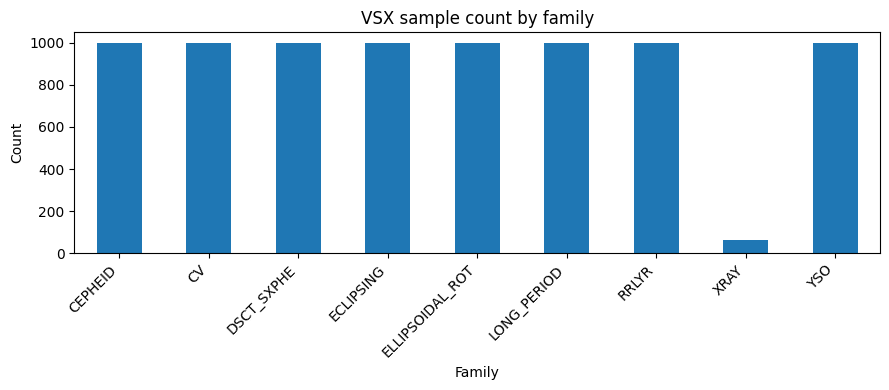

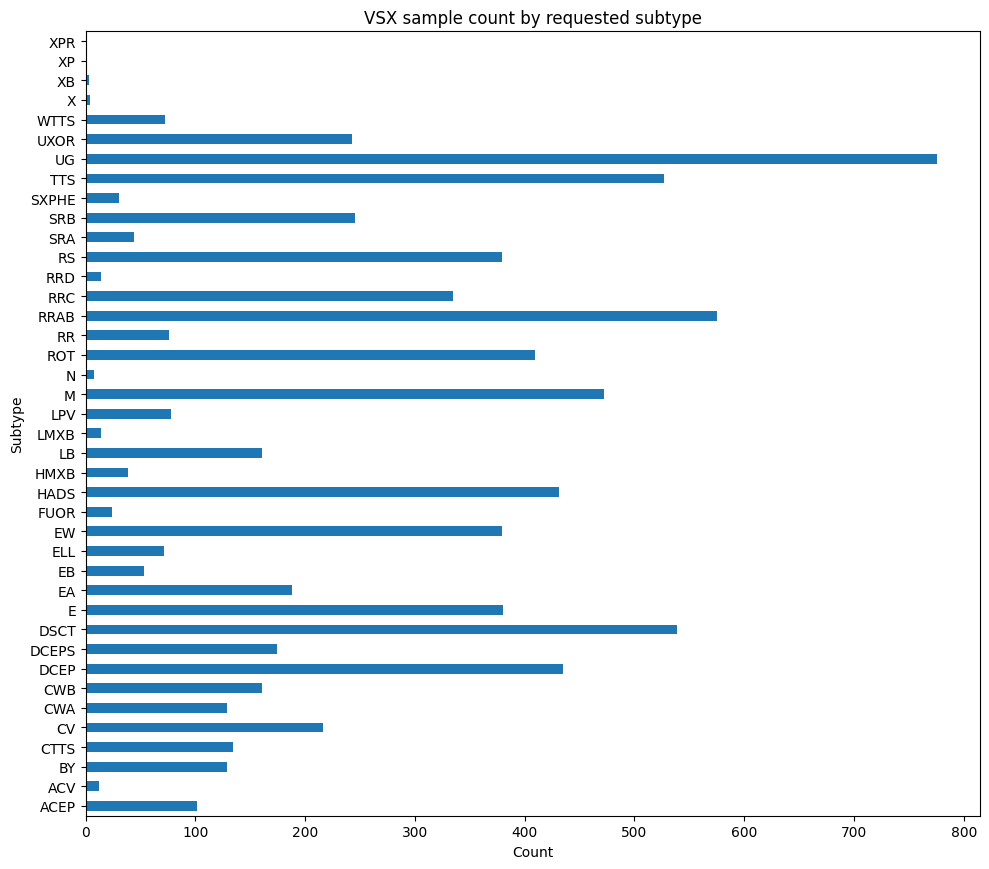

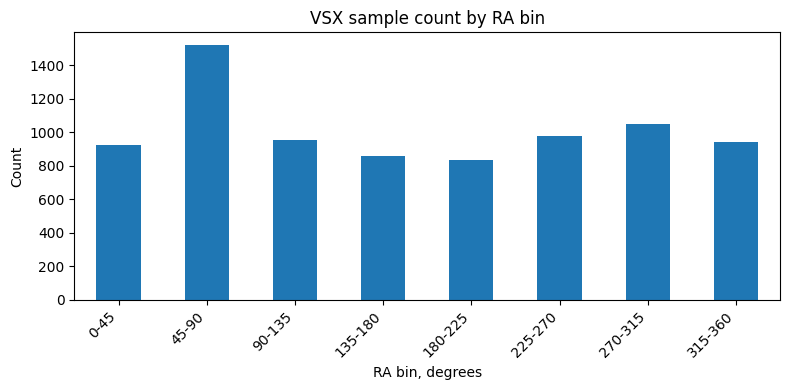

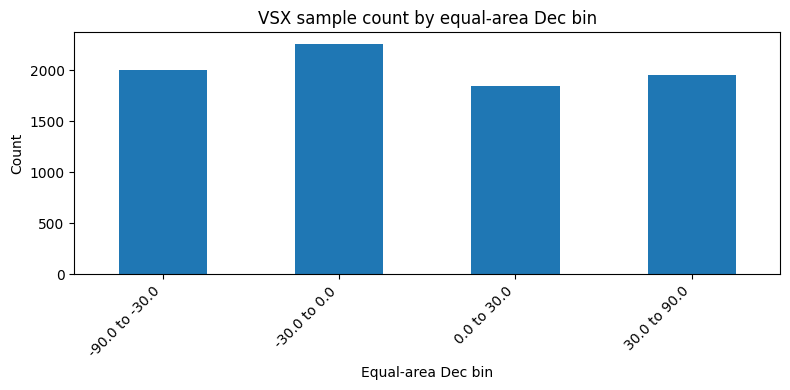

In [6]:
# VSX sample-balance validation
# This cell validates the pure VSX sample before any TESS/TIC matching occurs.

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def vsx_categories_to_dataframe(category_dictionary):
    """Convert VSXCategoryLoader output into a flat DataFrame."""
    if not category_dictionary:
        return pd.DataFrame()

    rows = []
    for family, stars in category_dictionary.items():
        for star in stars:
            row = dict(star)
            row["family"] = row.get("family", family)
            rows.append(row)
    return pd.DataFrame(rows)


def load_vsx_sample_for_validation(pipeline=None):
    """Load the VSX-level sample for balance validation."""
    if pipeline is not None:
        category_dictionary = getattr(pipeline, "vsxCategoryDictionary", None)
        df = vsx_categories_to_dataframe(category_dictionary)
        if not df.empty:
            return df, "current pure VSX query sample"

    if os.path.exists(VSX_METADATA_FILE):
        return pd.read_parquet(VSX_METADATA_FILE), f"pure VSX metadata: {VSX_METADATA_FILE}"

    return pd.DataFrame(), "no available pure VSX sample"


def add_vsx_balance_bins(df, n_ra_bins=8, n_dec_bins=4):
    """Add RA bins and equal-area Dec bins based on uniform spacing in sin(dec)."""
    df = df.copy()
    df["raDeg"] = pd.to_numeric(df.get("raDeg"), errors="coerce")
    df["decDeg"] = pd.to_numeric(df.get("decDeg"), errors="coerce")
    df = df.dropna(subset=["family", "raDeg", "decDeg"])

    ra_edges = np.linspace(0.0, 360.0, n_ra_bins + 1)
    ra_labels = [f"{ra_edges[i]:.0f}-{ra_edges[i + 1]:.0f}" for i in range(n_ra_bins)]
    df["raBin"] = pd.cut(
        df["raDeg"] % 360.0,
        bins=ra_edges,
        labels=ra_labels,
        include_lowest=True,
        right=False,
    )

    sin_dec_edges = np.linspace(-1.0, 1.0, n_dec_bins + 1)
    dec_edges = np.rad2deg(np.arcsin(sin_dec_edges))
    dec_labels = [f"{dec_edges[i]:.1f} to {dec_edges[i + 1]:.1f}" for i in range(n_dec_bins)]
    sin_dec = np.sin(np.deg2rad(df["decDeg"]))
    df["decEqualAreaBin"] = pd.cut(
        sin_dec,
        bins=sin_dec_edges,
        labels=dec_labels,
        include_lowest=True,
    )

    if "requestedVsxType" in df.columns:
        df["sampleSubtype"] = df["requestedVsxType"].fillna(df.get("VSXType"))
    elif "VSXType" in df.columns:
        df["sampleSubtype"] = df["VSXType"]
    else:
        df["sampleSubtype"] = "UNKNOWN"

    return df


def display_vsx_balance_tables(df):
    """Display compact tables for family, subtype, and RA/Dec balance."""
    family_counts = (
        df.groupby("family")
        .size()
        .rename("count")
        .sort_values(ascending=False)
        .reset_index()
    )

    subtype_counts = (
        df.groupby(["family", "sampleSubtype"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["family", "count"], ascending=[True, False])
    )

    sky_counts = pd.crosstab(
        df["decEqualAreaBin"],
        df["raBin"],
        margins=True,
        margins_name="Total",
    )

    balance_summary = pd.DataFrame({
        "metric": [
            "total rows",
            "families",
            "subtypes",
            "non-empty RA bins",
            "non-empty equal-area Dec bins",
            "non-empty RA/Dec cells",
        ],
        "value": [
            len(df),
            df["family"].nunique(),
            df["sampleSubtype"].nunique(),
            df["raBin"].nunique(),
            df["decEqualAreaBin"].nunique(),
            df.groupby(["raBin", "decEqualAreaBin"], observed=True).size().shape[0],
        ],
    })

    display(balance_summary)
    display(family_counts)
    display(subtype_counts)
    display(sky_counts)


def plot_vsx_balance(df):
    """Plot family, subtype, RA, Dec, and sky-position balance."""
    family_counts = df["family"].value_counts().sort_index()
    plt.figure(figsize=(9, 4))
    family_counts.plot(kind="bar")
    plt.title("VSX sample count by family")
    plt.xlabel("Family")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    subtype_counts = df["sampleSubtype"].value_counts().sort_index()
    plt.figure(figsize=(10, max(4, 0.22 * len(subtype_counts))))
    subtype_counts.plot(kind="barh")
    plt.title("VSX sample count by requested subtype")
    plt.xlabel("Count")
    plt.ylabel("Subtype")
    plt.tight_layout()
    plt.show()

    ra_counts = df["raBin"].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    ra_counts.plot(kind="bar")
    plt.title("VSX sample count by RA bin")
    plt.xlabel("RA bin, degrees")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    dec_counts = df["decEqualAreaBin"].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    dec_counts.plot(kind="bar")
    plt.title("VSX sample count by equal-area Dec bin")
    plt.xlabel("Equal-area Dec bin")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


vsx_validation_df, vsx_validation_source = load_vsx_sample_for_validation(pipeline=globals().get("pipeline"))
print("VSX validation source:", vsx_validation_source)

if vsx_validation_df.empty:
    print("No VSX sample available. Run the pure VSX query cell or provide VSX_METADATA_FILE.")
else:
    vsx_validation_df = add_vsx_balance_bins(vsx_validation_df)
    print("Rows available for VSX balance validation:", len(vsx_validation_df))
    display_vsx_balance_tables(vsx_validation_df)
    plot_vsx_balance(vsx_validation_df)


## 2.10 TESS/TIC Direct Match

This cell reads the already-saved pure VSX file from `VSX_METADATA_FILE`, performs only the TIC cross-match and SPOC/QLP availability inspection, and saves the metadata result to `VSX_TESS_MATCH_METADATA_FILE`.

The matching rule is confidence-first:

- query around each VSX coordinate using `RADIUS_ARCSEC` (currently 1.0 arcsec);
- independently recompute the VSX–TIC angular separation from the returned coordinates;
- discard any remotely returned source whose recomputed separation exceeds the radius;
- retain only the closest candidate (`MAX_TIC_CANDIDATES = 1`).

The explicit local radius check is required because a remote cone-search response can occasionally contain a source outside the requested radius.

This step does not download or extract light curves. The later light-curve step uses `VSX_TESS_MATCH_METADATA_FILE` as input.


In [7]:
# Optional pure TESS/TIC match cell.
# This cell does nothing unless RUN_TESS_MATCH is True.

if RUN_TESS_MATCH:
    if 'pipeline' not in globals():
        vsx_loader = VSXCategoryLoader(
            cacheFolder=VSX_CACHE_FOLDER,
            refreshCache=False,
        )
        tess_converter = VSX2TESSConverter()
        pipeline = ResearchPipeline(
            vsxLoader=vsx_loader,
            tessConverter=tess_converter,
            nFamilies=None,
            nInstances=1000,
            vsxCacheFolder=VSX_CACHE_FOLDER,
            tessCacheFolder=TESS_CACHE_FOLDER,
        )

    tess_match_metadata = pipeline.matchTessOnly(
        vsxMetadataFile=VSX_METADATA_FILE,
        tessMatchMetadataFile=VSX_TESS_MATCH_METADATA_FILE,
        radiusArcsec=RADIUS_ARCSEC,
        maxMatches=MAX_TIC_CANDIDATES,
    )
    tess_match_df = pd.read_parquet(VSX_TESS_MATCH_METADATA_FILE)

    # Integrity check: every retained TIC candidate must satisfy the configured
    # angular-radius criterion. Parquet may deserialize ticCandidates as a
    # NumPy object array, so handle arrays, lists, tuples, and dictionaries.
    import numpy as np

    def _first_tic_candidate(value):
        if isinstance(value, np.ndarray):
            value = value.tolist()
        if isinstance(value, dict):
            return value
        if isinstance(value, (list, tuple)) and len(value) > 0:
            return value[0]
        return None

    first_candidates = tess_match_df["ticCandidates"].apply(_first_tic_candidate)
    retained_distance_arcsec = first_candidates.apply(
        lambda candidate: (
            float(candidate["ticDistanceArcmin"]) * 60.0
            if isinstance(candidate, dict)
            and candidate.get("ticDistanceArcmin") is not None
            else np.nan
        )
    )

    outside_radius = tess_match_df.loc[
        retained_distance_arcsec > RADIUS_ARCSEC + 1e-9
    ].copy()
    outside_radius["retainedDistanceArcsec"] = retained_distance_arcsec.loc[
        outside_radius.index
    ]

    if not outside_radius.empty:
        display_columns = [
            column
            for column in ["VSXId", "VSXName", "family", "retainedDistanceArcsec"]
            if column in outside_radius.columns
        ]
        display(outside_radius[display_columns])
        raise AssertionError(
            f"{len(outside_radius)} retained TIC candidate(s) exceed "
            f"RADIUS_ARCSEC={RADIUS_ARCSEC}. The match metadata is invalid."
        )

    print("Pure TESS/TIC match complete.")
    print("Rows with at least one TIC candidate:", len(tess_match_df))
    print(
        "Maximum retained TIC separation (arcsec):",
        float(retained_distance_arcsec.max()),
    )
    print(
        f"Verified: 100% of retained candidates are within {RADIUS_ARCSEC} arcsec."
    )
    print("Saved TESS match metadata to:", VSX_TESS_MATCH_METADATA_FILE)
else:
    print("RUN_TESS_MATCH is False; pure TESS/TIC match was not executed.")
    if os.path.exists(VSX_TESS_MATCH_METADATA_FILE):
        print("Existing TESS match metadata file:", VSX_TESS_MATCH_METADATA_FILE)
    else:
        print("No existing VSX_TESS_MATCH_METADATA_FILE found yet:", VSX_TESS_MATCH_METADATA_FILE)


Pure TESS/TIC match complete.
Rows with at least one TIC candidate: 7459
Maximum retained TIC separation (arcsec): 0.9992256486188493
Verified: 100% of retained candidates are within 1.0 arcsec.
Saved TESS match metadata to: /data/projects/TESS-research/data_pipeline/TESSCache/VSX_TESS_MATCH_Metadata.parquet


## 2.11 Light-Curve Acquisition and Photometric Provenance

This stage is split into two independent multithreaded passes.

1. `downloadTessLightCurves()` reads `VSX_TESS_MATCH_METADATA_FILE`, downloads every raw light curve, assigns provenance directly from `bestMatch["author"]` when present, and otherwise uses VSX-centered TESSCut. Raw paths, acquisition metadata, availability, and quality-mask flags are written to `AUGMENTED_METADATA_FILE`.
2. `standardizeTessLightCurves()` reads each `rawLightCurvePath` from `AUGMENTED_METADATA_FILE`, standardizes the light curve in resumable chunks, writes the standardized FITS file, and checkpoints normalization and quality statistics to the same metadata file after every chunk.


### Class Definition: TESS light-curve acquisition

The full downloader class definition is included below and collapsed by default.


In [2]:
import json
# TESS light-curve download and SPOC -> QLP -> TESSCut fallback logic

import pandas as pd
import lightkurve as lk
import logging
import os
import glob
import re
import sys
import time
import shutil
import io
import numpy as np
import threading
import math
import warnings
import gc
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.io import fits
from astropy.time import Time
from contextlib import redirect_stderr, redirect_stdout
from concurrent.futures import ThreadPoolExecutor, as_completed


class _QualityMaskLogFilter(logging.Filter):
    """
    Drops quality-mask log records emitted by Lightkurve below a given
    ignored-cadence percentage threshold, and updates downloader quality.
    """
    _PATTERN = re.compile(
        r"([0-9]+(?:\.[0-9]+)?)%.*cadences will be ignored due to the quality mask",
        re.IGNORECASE,
    )

    def __init__(self, thresholdPercent=20.0, downloader=None):
        super().__init__()
        self.thresholdPercent = thresholdPercent
        self.downloader = downloader

    def filter(self, record):
        message = record.getMessage()
        match = self._PATTERN.search(message)
        if match is not None:
            percentage = float(match.group(1))
            if self.downloader is not None:
                self.downloader._updateStarQuality(percentage)
            return percentage > self.thresholdPercent
        return True


_qualityMaskLogFilter = _QualityMaskLogFilter(thresholdPercent=20.0, downloader=None)
for _lkLoggerName in (
    "lightkurve",
    "lightkurve.io",
    "lightkurve.lightcurve",
    "lightkurve.utils",
    "lightkurve.search",
    "lightkurve.targetpixelfile",
):
    logging.getLogger(_lkLoggerName).addFilter(_qualityMaskLogFilter)

class TessDataDownloader:
    """
    A class to download TESS light curve data organized by stellar categories.
    """
    
    def __init__(self, tessCacheFolder='TESSCache'):
        """Initialize the TessDataDownloader."""
        self.logger = logging.getLogger("TessDataDownloader")
        self.tessCacheFolder = tessCacheFolder
        self.normalizationStdFloor = 1e-8
        self.lowSnrThreshold = 3.0
        if not os.path.exists(self.tessCacheFolder):
            os.makedirs(self.tessCacheFolder)

        self.ignoredCadenceWarningThresholdPercent = 20.0
        self._threadState = threading.local()
        self._workerDownloadsRoot = os.path.join(self.tessCacheFolder, "_worker_downloads")
        
        global _qualityMaskLogFilter
        _qualityMaskLogFilter.downloader = self

    def preprocessLightCurve(
        self,
        lightCurve,
        doRemoveNans=True,
        doNormalize=True,
        doFlatten=False,
        flattenWindowLength=401,
        doRemoveOutliers=False,
        sigma=5.0,
        doBin=False,
        timeBinSize=0.01,
    ):
        """
        Standard preprocessing helper for TESS light curves.

        Keep this configurable because different science cases benefit from
        different preprocessing choices.
        """
        if lightCurve is None:
            return None

        processed = lightCurve
        normalizationMetadata = None

        try:
            if doRemoveNans:
                processed = processed.remove_nans()

            if doNormalize:
                processed, normalizationMetadata = self._standardizeLightCurve(processed)
                if processed is None:
                    return None

            if doFlatten:
                processed = processed.flatten(window_length=flattenWindowLength)

            if doRemoveOutliers:
                processed = processed.remove_outliers(sigma=sigma)

            if doBin:
                processed = processed.bin(time_bin_size=timeBinSize)

            if doRemoveNans:
                processed = processed.remove_nans()

        except Exception as exc:
            self.logger.warning("preprocessLightCurve failed: %s", exc)
            return None

        return processed

    def _resolveMetadataPath(self, tessMetadataParquet):
        if os.path.isabs(tessMetadataParquet):
            return tessMetadataParquet

        cachePath = os.path.join(self.tessCacheFolder, tessMetadataParquet)
        if os.path.exists(cachePath):
            return cachePath

        return tessMetadataParquet

    def _cleanupTransientDownloads(self, downloadRoot=None):
        rootPath = downloadRoot or self.tessCacheFolder
        transientPaths = [
            os.path.join(rootPath, "mastDownload"),
            os.path.join(rootPath, "tesscut"),
        ]

        for transientPath in transientPaths:
            if not os.path.exists(transientPath):
                continue

            try:
                shutil.rmtree(transientPath)
            except Exception as exc:
                self.logger.warning(
                    "Failed to remove transient download directory %s: %s",
                    transientPath,
                    exc,
                )

    def _resetStarQuality(self):
        self._threadState.currentStarQuality = "missing"

    def _getCurrentStarQuality(self):
        return getattr(self._threadState, "currentStarQuality", "missing")

    def _normalizeTicId(self, value):
        if value is None:
            return None

        try:
            if pd.isna(value):
                return None
        except TypeError:
            pass

        digits = "".join(ch for ch in str(value) if ch.isdigit())
        if not digits:
            return None

        return str(int(digits))

    def _sanitizeFilenameComponent(self, value):
        """Sanitize a string for use in filenames by replacing spaces and special chars with underscores."""
        if value is None:
            return None
        # Replace spaces and other problematic characters with underscores
        sanitized = str(value).replace(" ", "_").replace(",", "_").replace(":", "_")
        return sanitized

    def _sortedTicCandidates(self, ticCandidates):
        if ticCandidates is None:
            return []

        if isinstance(ticCandidates, float) and pd.isna(ticCandidates):
            return []

        if hasattr(ticCandidates, "tolist"):
            ticCandidates = ticCandidates.tolist()

        if isinstance(ticCandidates, dict):
            ticCandidates = [ticCandidates]

        normalizedCandidates = []
        for candidate in ticCandidates or []:
            if candidate is None:
                continue
            normalizedCandidates.append(dict(candidate))

        normalizedCandidates.sort(
            key=lambda candidate: float(candidate.get("ticDistanceArcmin", float("inf")))
        )
        return normalizedCandidates

    def _logDuplicateTicMappings(self, df):
        """Log stars that map to the same top TIC candidate."""
        starsByTopTic = {}
        duplicateWarningCount = 0

        for _, row in df.iterrows():
            ticCandidates = self._sortedTicCandidates(row.get("ticCandidates"))
            topTic = self._normalizeTicId((ticCandidates[0] if ticCandidates else {}).get("ticId"))
            if topTic is None:
                continue

            candidateTics = [
                self._normalizeTicId(candidate.get("ticId"))
                for candidate in ticCandidates
            ]
            candidateTics = [tic for tic in candidateTics if tic is not None]

            starsByTopTic.setdefault(topTic, []).append(
                {
                    "family": row.get("family"),
                    "VSXType": row.get("VSXType"),
                    "VSXId": row.get("VSXId"),
                    "tics": candidateTics,
                }
            )

        for topTic, stars in starsByTopTic.items():
            if len(stars) < 2:
                continue
            for star in stars:
                self.logger.error(
                    "Duplicate TIC mapping detected: TIC=%s family=%s vsxtype=%s vsxid=%s tics=%s",
                    topTic,
                    star.get("family"),
                    star.get("VSXType"),
                    star.get("VSXId"),
                    star.get("tics"),
                )
                duplicateWarningCount += 1

        return duplicateWarningCount

    def _standardizeLightCurve(self, lightCurve):
        if not RUN_LIGHT_CURVE_STANDARDIZATION:
            return lightCurve, None
        
        if lightCurve is None:
            return None, None

        cleanedLightCurve = lightCurve.remove_nans()
        if len(cleanedLightCurve) == 0:
            return None, {
                "normalizationApplied": False,
                "fluxMedian": None,
                "fluxStd": None,
                "fluxSnr": None,
                "medianUnstable": True,
                "lowSNR": True,
                "lowQualityLightCurve": True,
                "lowQualityReason": "No valid cadences after removing NaNs",
                "validCadenceCount": 0,
            }

        fluxArray = np.asarray(getattr(cleanedLightCurve.flux, "value", cleanedLightCurve.flux), dtype=float)
        validMask = np.isfinite(fluxArray)

        fluxMask = getattr(cleanedLightCurve.flux, "mask", None)
        if fluxMask is not None:
            fluxMaskArray = np.asarray(fluxMask, dtype=bool)
            if fluxMaskArray.shape == ():
                validMask &= (not bool(fluxMaskArray))
            else:
                validMask &= np.logical_not(fluxMaskArray)

        if hasattr(cleanedLightCurve.time, "value"):
            timeValues = np.asarray(cleanedLightCurve.time.value, dtype=float)
            validMask &= np.isfinite(timeValues)

        validFlux = fluxArray[validMask]
        if validFlux.size == 0:
            return None, {
                "normalizationApplied": False,
                "fluxMedian": None,
                "fluxStd": None,
                "fluxSnr": None,
                "medianUnstable": True,
                "lowSNR": True,
                "lowQualityLightCurve": True,
                "lowQualityReason": "No valid cadences after masking invalid flux values",
                "validCadenceCount": 0,
            }

        medianFlux = float(np.nanmedian(validFlux))
        stdFlux = float(np.nanstd(validFlux))
        medianUnstable = (not np.isfinite(medianFlux)) or abs(medianFlux) < self.normalizationStdFloor
        lowStd = (not np.isfinite(stdFlux)) or stdFlux < self.normalizationStdFloor
        fluxSnr = None if lowStd else float(abs(medianFlux) / stdFlux)
        lowSNR = fluxSnr is None or fluxSnr < self.lowSnrThreshold

        normalizationMetadata = {
            "normalizationApplied": False,
            "fluxMedian": medianFlux,
            "fluxStd": stdFlux,
            "fluxSnr": fluxSnr,
            "medianUnstable": bool(medianUnstable),
            "lowSNR": bool(lowSNR),
            "lowQualityLightCurve": bool(medianUnstable or lowSNR or lowStd),
            "lowQualityReason": None,
            "validCadenceCount": int(validFlux.size),
        }

        if lowStd:
            normalizationMetadata["lowQualityReason"] = "Flux standard deviation is too small for stable normalization"
            return cleanedLightCurve, normalizationMetadata

        standardizedFlux = np.full_like(fluxArray, np.nan, dtype=float)
        standardizedFlux[validMask] = (fluxArray[validMask] - medianFlux) / stdFlux

        standardizedLightCurve = cleanedLightCurve.copy()
        standardizedLightCurve.flux = standardizedFlux * u.dimensionless_unscaled

        if hasattr(standardizedLightCurve, "flux_err") and standardizedLightCurve.flux_err is not None:
            fluxErrArray = np.asarray(
                getattr(standardizedLightCurve.flux_err, "value", standardizedLightCurve.flux_err),
                dtype=float,
            )
            standardizedFluxErr = np.full_like(fluxErrArray, np.nan, dtype=float)
            finiteFluxErr = np.isfinite(fluxErrArray)
            standardizedFluxErr[finiteFluxErr] = fluxErrArray[finiteFluxErr] / stdFlux
            standardizedLightCurve.flux_err = standardizedFluxErr * u.dimensionless_unscaled

        normalizationMetadata["normalizationApplied"] = True
        return standardizedLightCurve.remove_nans(), normalizationMetadata

    def _storeLightCurve(self, lightCurve, outputFile, ticId, authorLabel):
        try:
            lightCurve.to_fits(path=outputFile, overwrite=True)
        except (AttributeError, ValueError) as exc:
            self.logger.warning(
                "to_fits failed for TIC %s author %s, using fallback: %s",
                ticId,
                authorLabel,
                exc,
            )
            try:
                timeCol = fits.Column(name="TIME", format="D", array=lightCurve.time.jd)
                fluxCol = fits.Column(name="FLUX", format="E", array=np.asarray(lightCurve.flux.value, dtype=float))
                cols = fits.ColDefs([timeCol, fluxCol])
                hdu = fits.BinTableHDU.from_columns(cols)
                hdu.writeto(outputFile, overwrite=True)
            except Exception as fallbackExc:
                self.logger.error(
                    "Fallback FITS write also failed for TIC %s author %s: %s",
                    ticId,
                    authorLabel,
                    fallbackExc,
                )
                return False

        return True

    def _categorizeQualityMaskPercentage(self, percentage):
        """Categorize data quality based on quality_bitmask cadence percentage."""
        if percentage < 10:
            return "clean"
        elif percentage < 25:
            return "acceptable"
        elif percentage < 40:
            return "caution"
        else:
            return "poor"

    def _updateStarQuality(self, percentage):
        """Update current star quality to worst quality seen so far."""
        newQuality = self._categorizeQualityMaskPercentage(percentage)
        qualityOrder = {"clean": 0, "acceptable": 1, "caution": 2, "poor": 3}
        currentQuality = self._getCurrentStarQuality()
        if qualityOrder.get(newQuality, 0) > qualityOrder.get(currentQuality, 0):
            self._threadState.currentStarQuality = newQuality

    def _finalizeStarQuality(self, lightCurveAvailable):
        """Return final quality after considering whether any light curve was available."""
        if not lightCurveAvailable:
            return "missing"

        if self._getCurrentStarQuality() == "missing":
            return "clean"

        return self._getCurrentStarQuality()

    def _runWithFilteredWarnings(self, func, *args, ticId=None, warningContext=None, **kwargs):
        qualityWarningPattern = re.compile(
            r"([0-9]+(?:\.[0-9]+)?)%\s*\([^)]*\)\s*of the cadences will be ignored due to the quality mask",
            re.IGNORECASE,
        )
        negativeMedianPattern = re.compile(
            r"negative median flux",
            re.IGNORECASE,
        )
        zeroCenteredPattern = re.compile(
            r"zero-centered.*normalize\(\)",
            re.IGNORECASE,
        )
        boolInversionDeprecationPattern = re.compile(
            r"bitwise inversion\s+['`~]+\s*on bool\s+is deprecated",
            re.IGNORECASE,
        )

        with warnings.catch_warnings(record=True) as caughtWarnings:
            warnings.simplefilter("always")
            result = func(*args, **kwargs)

        for caughtWarning in caughtWarnings:
            warningMessage = str(caughtWarning.message)
            qualityMatch = qualityWarningPattern.search(warningMessage)

            if qualityMatch is not None:
                ignoredPercent = float(qualityMatch.group(1))
                self._updateStarQuality(ignoredPercent)
                if ignoredPercent > self.ignoredCadenceWarningThresholdPercent:
                    self.logger.warning(
                        "High quality-mask rejection for TIC %s%s: %s",
                        ticId if ticId is not None else "unknown",
                        f" during {warningContext}" if warningContext else "",
                        warningMessage,
                    )
                continue

            if negativeMedianPattern.search(warningMessage) is not None:
                continue

            if zeroCenteredPattern.search(warningMessage) is not None:
                continue

            if boolInversionDeprecationPattern.search(warningMessage) is not None:
                continue

            self.logger.warning(
                "Warning for TIC %s%s: %s",
                ticId if ticId is not None else "unknown",
                f" during {warningContext}" if warningContext else "",
                warningMessage,
            )

        return result

    def _lightCurveFromSearchResult(self, searchResult, ticId=None, downloadDir=None):
        if searchResult is None or len(searchResult) == 0:
            return None

        resolvedDownloadDir = downloadDir or self.tessCacheFolder

        try:
            downloaded = self._runWithFilteredWarnings(
                searchResult.download_all,
                download_dir=resolvedDownloadDir,
                ticId=ticId,
                warningContext="search_lightcurve download_all",
            )
        except Exception:
            downloaded = self._runWithFilteredWarnings(
                searchResult.download,
                download_dir=resolvedDownloadDir,
                ticId=ticId,
                warningContext="search_lightcurve download",
            )

        if downloaded is None:
            return None

        if isinstance(downloaded, lk.LightCurveCollection):
            if len(downloaded) == 0:
                return None
            try:
                return downloaded.stitch()
            except Exception as exc:
                self.logger.warning("Failed to stitch light-curve collection: %s", exc)
                return downloaded[0]

        return downloaded

    def _runQuietLightkurveSearch(self, searchFn, *args, **kwargs):
        loggerNames = [
            "lightkurve.search",
            "astroquery",
            "astroquery.mast",
        ]
        loggerState = []

        for loggerName in loggerNames:
            packageLogger = logging.getLogger(loggerName)
            loggerState.append((packageLogger, packageLogger.level, packageLogger.disabled))
            packageLogger.setLevel(logging.CRITICAL + 1)

        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                return searchFn(*args, **kwargs)
        finally:
            for packageLogger, level, disabled in loggerState:
                packageLogger.setLevel(level)
                packageLogger.disabled = disabled

    def _bestMatchInfo(self, rowData):
        bestMatch = rowData.get("bestMatch")
        if not isinstance(bestMatch, dict):
            return None, None
        return self._normalizeTicId(bestMatch.get("ticId")), bestMatch.get("author")

    def _downloadCatalogLightCurve(self, ticId, author, downloadDir, vsxId):
        searchResult = self._runQuietLightkurveSearch(
            lk.search_lightcurve,
            f"TIC {ticId}",
            mission="TESS",
            author=author,
        )
        lightCurve = self._lightCurveFromSearchResult(
            searchResult,
            ticId=ticId,
            downloadDir=downloadDir,
        )
        if lightCurve is None:
            return None

        vsxPart = self._sanitizeFilenameComponent(vsxId)
        rawPath = os.path.join(
            self.tessCacheFolder,
            f"VSX_{vsxPart}_TIC_{ticId}_{author}_raw.fits",
        )
        if not self._storeLightCurve(lightCurve, rawPath, ticId, author):
            return None

        sectors = []
        if hasattr(searchResult, "table") and "sequence_number" in searchResult.table.colnames:
            sectors = sorted({
                int(value)
                for value in searchResult.table["sequence_number"]
                if value is not None and str(value) != "--"
            })

        return {
            "rawLightCurvePath": rawPath,
            "extractionMetadata": {
                "downloadMethod": "search_lightcurve",
                "author": author,
                "productCount": int(len(searchResult)),
                "sectors": sectors,
            },
        }

    def _extractTessCutLightCurve(self, rowData, cutoutSize, downloadDir):
        raDeg = rowData.get("raDeg")
        decDeg = rowData.get("decDeg")
        if raDeg is None or decDeg is None:
            return None

        coord = SkyCoord(
            ra=float(raDeg) * u.deg,
            dec=float(decDeg) * u.deg,
            frame="icrs",
        )
        searchResult = self._runQuietLightkurveSearch(lk.search_tesscut, coord)
        if searchResult is None or len(searchResult) == 0:
            return None

        candidates = self._sortedTicCandidates(rowData.get("ticCandidates"))
        chosenTicId = self._normalizeTicId(
            (candidates[0] if candidates else {}).get("ticId")
        ) or "NA"

        tpfCollection = self._runWithFilteredWarnings(
            searchResult.download_all,
            cutout_size=cutoutSize,
            download_dir=downloadDir,
            ticId=chosenTicId,
            warningContext="search_tesscut download_all",
        )
        if tpfCollection is None or len(tpfCollection) == 0:
            return None

        curves, sectors, aperturePixelCounts = [], [], []
        for tpf in tpfCollection:
            try:
                mask = tpf.create_threshold_mask(threshold=3, reference_pixel="center")
                if mask is None or not np.any(mask):
                    mask = np.zeros(tpf.flux[0].shape, dtype=bool)
                    mask[mask.shape[0] // 2, mask.shape[1] // 2] = True

                curve = self._runWithFilteredWarnings(
                    tpf.to_lightcurve,
                    aperture_mask=mask,
                    ticId=chosenTicId,
                    warningContext="TESSCut to_lightcurve",
                ).remove_nans()
                if len(curve):
                    curves.append(curve)
                    aperturePixelCounts.append(int(np.sum(mask)))
                    if getattr(tpf, "sector", None) is not None:
                        sectors.append(int(tpf.sector))
            finally:
                try:
                    if hasattr(tpf, "close") and callable(tpf.close):
                        tpf.close()
                    elif hasattr(tpf, "hdu"):
                        tpf.hdu.close()
                except Exception:
                    pass

        if not curves:
            return None

        lightCurve = (
            curves[0]
            if len(curves) == 1
            else lk.LightCurveCollection(curves).stitch()
        ).remove_nans()

        vsxPart = self._sanitizeFilenameComponent(rowData.get("VSXId", "NA"))
        rawPath = os.path.join(
            self.tessCacheFolder,
            f"VSX_{vsxPart}_TIC_{chosenTicId}_TESSCut_raw.fits",
        )
        if not self._storeLightCurve(lightCurve, rawPath, chosenTicId, "TESSCut"):
            return None

        return {
            "rawLightCurvePath": rawPath,
            "extractionMetadata": {
                "downloadMethod": "search_tesscut",
                "tesscutCenterSource": "VSX",
                "tesscutCenterRaDeg": float(raDeg),
                "tesscutCenterDecDeg": float(decDeg),
                "cutoutSize": list(cutoutSize),
                "sectorCount": len(curves),
                "sectors": sectors,
                "aperturePixelCounts": aperturePixelCounts,
                "selectedCandidateTicId": chosenTicId,
                "extractionMethod": "threshold_mask_photometry",
            },
        }

    def _downloadSingleStar(self, idx, rowData, cutoutSize, cleanupDownloads):
        self._resetStarQuality()
        ticId, author = self._bestMatchInfo(rowData)
        provenance = author if author else "TESSCut"

        taskDir = os.path.join(
            self._workerDownloadsRoot,
            f"star_{idx}_{threading.get_ident()}_{time.time_ns()}",
        )
        os.makedirs(taskDir, exist_ok=True)

        try:
            if author:
                result = self._downloadCatalogLightCurve(
                    ticId, author, taskDir, rowData.get("VSXId")
                )
            else:
                result = self._extractTessCutLightCurve(
                    rowData, cutoutSize, taskDir
                )

            available = result is not None
            updates = {
                "provenance": provenance,
                "rawLightCurvePath": result["rawLightCurvePath"] if available else None,
                "lightCurveAvailable": available,
                "extractionMetadata": result["extractionMetadata"] if available else None,
                "noLightCurveReason": None if available else f"{provenance} acquisition failed",
                "quality": self._finalizeStarQuality(available),
                "lightCurvePath": None,
                "normalizationApplied": None,
                "fluxMedian": None,
                "fluxStd": None,
                "fluxSnr": None,
                "medianUnstable": None,
                "lowSNR": None,
                "lowQualityLightCurve": None,
                "lowQualityReason": None,
            }
            return idx, updates
        except Exception as exc:
            self.logger.exception("Download failed for row %s: %s", idx, exc)
            return idx, {
                "provenance": provenance,
                "rawLightCurvePath": None,
                "lightCurveAvailable": False,
                "extractionMetadata": None,
                "noLightCurveReason": str(exc),
                "quality": "missing",
                "lightCurvePath": None,
            }
        finally:
            if cleanupDownloads:
                self._cleanupTransientDownloads(taskDir)
            shutil.rmtree(taskDir, ignore_errors=True)

    def downloadTessLightCurves(
        self,
        tessMetadataParquet,
        augmentedMetadataFile="TESSAugmented.parquet",
        cutoutSize=(15, 15),
        cleanupDownloads=True,
        maxWorkers=4,
        chunkSize=LIGHTCURVE_DOWNLOAD_CHUNKSIZE,
    ):
        """
        Download raw light curves in resumable chunks.

        If augmentedMetadataFile already exists, VSXId values already present
        there are skipped. Each chunk is downloaded in parallel and checkpointed
        to the augmented parquet file before the next chunk begins.
        """
        metadataPath = self._resolveMetadataPath(tessMetadataParquet)
        augmentedPath = self._resolveMetadataPath(augmentedMetadataFile)

        sourceDf = pd.read_parquet(metadataPath).copy()

        if "VSXId" not in sourceDf.columns:
            raise KeyError(f"VSXId column is missing from {metadataPath}")

        if os.path.exists(augmentedPath):
            augmentedDf = pd.read_parquet(augmentedPath).copy()

            if "VSXId" not in augmentedDf.columns:
                raise KeyError(f"VSXId column is missing from {augmentedPath}")

            completedVsxIds = set(
                augmentedDf["VSXId"]
                .dropna()
                .astype(str)
            )

            rowsToProcess = sourceDf[
                ~sourceDf["VSXId"].astype(str).isin(completedVsxIds)
            ].copy()
        else:
            augmentedDf = pd.DataFrame()
            rowsToProcess = sourceDf.copy()

        if rowsToProcess.empty:
            self.logger.info(
                "No new VSX rows to download; augmented metadata is current."
            )
            return augmentedDf

        chunkSize = max(1, int(chunkSize))
        workerCount = max(1, int(maxWorkers or 1))
        totalRows = len(rowsToProcess)
        totalChunks = math.ceil(totalRows / chunkSize)

        os.makedirs(self._workerDownloadsRoot, exist_ok=True)

        try:
            for chunkNumber, startRow in enumerate(
                range(0, totalRows, chunkSize),
                start=1,
            ):
                chunkDf = rowsToProcess.iloc[
                    startRow:startRow + chunkSize
                ].copy()

                self.logger.info(
                    "Processing download chunk %d/%d with %d rows",
                    chunkNumber,
                    totalChunks,
                    len(chunkDf),
                )

                with ThreadPoolExecutor(max_workers=workerCount) as executor:
                    futures = [
                        executor.submit(
                            self._downloadSingleStar,
                            idx,
                            row.to_dict(),
                            cutoutSize,
                            cleanupDownloads,
                        )
                        for idx, row in chunkDf.iterrows()
                    ]

                    for future in as_completed(futures):
                        idx, updates = future.result()
                        for column, value in updates.items():
                            if column not in chunkDf.columns:
                                chunkDf[column] = pd.Series(
                                    [None] * len(chunkDf),
                                    index=chunkDf.index,
                                    dtype="object",
                                )

                            if column == "extractionMetadata" and value is not None:
                                value = json.dumps(value, default=str, sort_keys=True)

                            chunkDf.at[idx, column] = value

                        del updates
                        del future

                chunkDf = chunkDf.reset_index(drop=True)

                if os.path.exists(augmentedPath):
                    existingDf = pd.read_parquet(augmentedPath)
                    combinedDf = pd.concat(
                        [existingDf, chunkDf],
                        ignore_index=True,
                    )
                else:
                    combinedDf = chunkDf

                combinedDf.to_parquet(
                    augmentedPath,
                    index=False,
                )

                self.logger.info(
                    "Completed chunk %d/%d; appended %d rows to %s",
                    chunkNumber,
                    totalChunks,
                    len(chunkDf),
                    augmentedPath,
                )

                del chunkDf
                gc.collect()
        finally:
            shutil.rmtree(
                self._workerDownloadsRoot,
                ignore_errors=True,
            )

        finalDf = pd.read_parquet(augmentedPath)

        availableCount = (
            int(finalDf["lightCurveAvailable"].eq(True).sum())
            if "lightCurveAvailable" in finalDf.columns
            else 0
        )

        self.logger.info(
            "Raw download complete: %d/%d available; saved %s",
            availableCount,
            len(finalDf),
            augmentedPath,
        )

        return finalDf


    def _readStoredRawLightCurve(self, rawPath, provenance):
        """
        Read a raw light curve saved by this pipeline.

        Lightkurve is attempted first. A generic FITS-table reader handles
        QLP, TESSCut, or fallback files that Lightkurve cannot identify.
        """
        try:
            return lk.read(rawPath)
        except Exception as lkExc:
            self.logger.warning(
                "lk.read failed for %s provenance=%s; using generic FITS reader: %s",
                rawPath,
                provenance,
                lkExc,
            )

        with fits.open(rawPath, memmap=False) as hdul:
            tableHdu = next(
                (
                    hdu
                    for hdu in hdul
                    if isinstance(hdu, fits.BinTableHDU)
                    and hdu.data is not None
                ),
                None,
            )
            if tableHdu is None:
                raise ValueError(f"No FITS binary table found in {rawPath}")

            columnNames = {
                name.upper(): name
                for name in tableHdu.columns.names
            }

            timeColumn = columnNames.get("TIME")
            fluxColumn = (
                columnNames.get("FLUX")
                or columnNames.get("PDCSAP_FLUX")
                or columnNames.get("SAP_FLUX")
            )
            fluxErrColumn = (
                columnNames.get("FLUX_ERR")
                or columnNames.get("PDCSAP_FLUX_ERR")
                or columnNames.get("SAP_FLUX_ERR")
            )
            qualityColumn = columnNames.get("QUALITY")

            if timeColumn is None or fluxColumn is None:
                raise ValueError(
                    f"Required TIME/FLUX columns not found in {rawPath}; "
                    f"columns={tableHdu.columns.names}"
                )

            timeValues = np.asarray(tableHdu.data[timeColumn], dtype=float)
            fluxValues = np.asarray(tableHdu.data[fluxColumn], dtype=float)
            valid = np.isfinite(timeValues) & np.isfinite(fluxValues)

            lightCurveArgs = {
                "time": Time(timeValues[valid], format="jd"),
                "flux": fluxValues[valid] * u.dimensionless_unscaled,
            }

            if fluxErrColumn is not None:
                fluxErrValues = np.asarray(
                    tableHdu.data[fluxErrColumn],
                    dtype=float,
                )
                lightCurveArgs["flux_err"] = (
                    fluxErrValues[valid] * u.dimensionless_unscaled
                )

            lightCurve = lk.LightCurve(**lightCurveArgs)

            if qualityColumn is not None:
                qualityValues = np.asarray(tableHdu.data[qualityColumn])
                lightCurve["quality"] = qualityValues[valid]

            return lightCurve

    def _standardizeSingleStar(self, idx, rowData):
        rawPath = rowData.get("rawLightCurvePath")
        if not rawPath or not os.path.exists(rawPath):
            return idx, {
                "lightCurvePath": None,
                "normalizationApplied": False,
                "lowQualityLightCurve": True,
                "lowQualityReason": "Raw light curve is missing",
            }

        try:
            provenance = str(rowData.get("provenance") or "TESSCut")
            rawCurve = self._readStoredRawLightCurve(
                rawPath=rawPath,
                provenance=provenance,
            )

            standardizedCurve, metadata = self._standardizeLightCurve(rawCurve)
            if standardizedCurve is None:
                raise ValueError("No usable cadences for standardization")

            outputPath = re.sub(r"_raw\.fits$", "_standardized.fits", rawPath)
            if outputPath == rawPath:
                outputPath = rawPath + ".standardized.fits"

            ticId, author = self._bestMatchInfo(rowData)
            ticId = ticId or self._normalizeTicId(
                (self._sortedTicCandidates(rowData.get("ticCandidates")) or [{}])[0].get("ticId")
            ) or "NA"
            if not self._storeLightCurve(
                standardizedCurve,
                outputPath,
                ticId,
                f"{provenance}_standardized",
            ):
                raise OSError("Failed to write standardized FITS")

            extractionMetadata = rowData.get("extractionMetadata")
            if isinstance(extractionMetadata, str):
                try:
                    extractionMetadata = json.loads(extractionMetadata)
                except json.JSONDecodeError:
                    extractionMetadata = {}
            elif isinstance(extractionMetadata, dict):
                extractionMetadata = dict(extractionMetadata)
            else:
                extractionMetadata = {}
            extractionMetadata["fluxNormalization"] = metadata

            updates = {
                "lightCurvePath": outputPath,
                "extractionMetadata": extractionMetadata,
            }
            updates.update(metadata)
            return idx, updates
        except Exception as exc:
            self.logger.exception("Standardization failed for row %s: %s", idx, exc)
            return idx, {
                "lightCurvePath": None,
                "normalizationApplied": False,
                "lowQualityLightCurve": True,
                "lowQualityReason": str(exc),
            }

    def standardizeTessLightCurves(
        self,
        augmentedMetadataFile="TESSAugmented.parquet",
        maxWorkers=4,
        chunkSize=None,
    ):
        """
        Standardize raw FITS files in resumable chunks.

        A row is considered complete only when normalizationApplied is True
        and its standardized lightCurvePath exists. After every chunk, the
        entire augmented metadata table is checkpointed back to parquet.
        Interrupted runs therefore resume from the remaining rows.
        """
        augmentedPath = self._resolveMetadataPath(augmentedMetadataFile)
        df = pd.read_parquet(augmentedPath).copy()

        if chunkSize is None:
            chunkSize = 50
        chunkSize = max(1, int(chunkSize))
        workerCount = max(1, int(maxWorkers or 1))

        availableMask = (
            df["lightCurveAvailable"].eq(True)
            if "lightCurveAvailable" in df.columns
            else pd.Series(False, index=df.index)
        )
        normalizedMask = (
            df["normalizationApplied"].eq(True)
            if "normalizationApplied" in df.columns
            else pd.Series(False, index=df.index)
        )
        standardizedPathMask = (
            df["lightCurvePath"].apply(
                lambda value: isinstance(value, str)
                and bool(value)
                and os.path.exists(value)
            )
            if "lightCurvePath" in df.columns
            else pd.Series(False, index=df.index)
        )

        rowsToProcess = df.loc[
            availableMask & ~(normalizedMask & standardizedPathMask)
        ].copy()

        if rowsToProcess.empty:
            self.logger.info(
                "No light curves require standardization; augmented metadata is current."
            )
            return df

        totalRows = len(rowsToProcess)
        totalChunks = math.ceil(totalRows / chunkSize)

        for chunkNumber, startRow in enumerate(
            range(0, totalRows, chunkSize),
            start=1,
        ):
            chunkIndex = rowsToProcess.index[
                startRow:startRow + chunkSize
            ]
            chunkDf = df.loc[chunkIndex].copy()

            self.logger.info(
                "Processing standardization chunk %d/%d with %d rows",
                chunkNumber,
                totalChunks,
                len(chunkDf),
            )

            with ThreadPoolExecutor(max_workers=workerCount) as executor:
                futures = [
                    executor.submit(
                        self._standardizeSingleStar,
                        idx,
                        row.to_dict(),
                    )
                    for idx, row in chunkDf.iterrows()
                ]

                for future in as_completed(futures):
                    idx, updates = future.result()

                    for column, value in updates.items():
                        if column not in df.columns:
                            df[column] = pd.Series(
                                [None] * len(df),
                                index=df.index,
                                dtype="object",
                            )

                        if column == "extractionMetadata" and value is not None:
                            value = json.dumps(
                                value,
                                default=str,
                                sort_keys=True,
                            )

                        df.at[idx, column] = value

                    del updates
                    del future

            df.to_parquet(augmentedPath, index=False)

            self.logger.info(
                "Completed standardization chunk %d/%d; checkpointed %d rows to %s",
                chunkNumber,
                totalChunks,
                len(chunkDf),
                augmentedPath,
            )

            del chunkDf
            gc.collect()

        standardizedCount = (
            int(df["normalizationApplied"].eq(True).sum())
            if "normalizationApplied" in df.columns
            else 0
        )
        self.logger.info(
            "Standardization complete: %d/%d standardized; saved %s",
            standardizedCount,
            len(df),
            augmentedPath,
        )
        return df


In [ ]:
# Optional raw download and standardization cells.
import astropy
import astroquery
from astroquery.mast import Observations

_ = astropy.log
_ = astroquery.log
_ = Observations
tess_downloader = TessDataDownloader(tessCacheFolder=TESS_CACHE_FOLDER)

if RUN_TESS_LIGHT_CURVE_DOWNLOAD:
    augmented = tess_downloader.downloadTessLightCurves(
        tessMetadataParquet=VSX_TESS_MATCH_METADATA_FILE,
        augmentedMetadataFile=AUGMENTED_METADATA_FILE,
        cutoutSize=(15, 15),
        cleanupDownloads=True,
        maxWorkers=12,
        chunkSize=LIGHTCURVE_DOWNLOAD_CHUNKSIZE,
    )
    print("Raw light-curve acquisition complete:", len(augmented))
else:
    print("RUN_TESS_LIGHT_CURVE_DOWNLOAD is False.")

if RUN_LIGHT_CURVE_STANDARDIZATION:
    augmented = tess_downloader.standardizeTessLightCurves(
        augmentedMetadataFile=AUGMENTED_METADATA_FILE,
        maxWorkers=24,
        chunkSize=LIGHTCURVE_STANDARDIZE_CHUNKSIZE,
    )
    print("Light-curve standardization complete:", len(augmented))
else:
    print("RUN_LIGHT_CURVE_STANDARDIZATION is False.")


**Clean up after the download and standardization**

In [4]:
augmented = pd.read_parquet(AUGMENTED_METADATA_FILE)
augmented = augmented[augmented['rawLightCurvePath'].notnull()]
augmented.to_parquet(AUGMENTED_METADATA_FILE, index=False)

## 2.12 FITS Integrity Checks and Quality Control

Because the dataset depends on thousands of downloaded or extracted FITS files, automated sanity checks are essential. A corrupted or truncated FITS file can create artificial features, cause feature-extraction failures, or bias model performance.

The FITS sanity scan checks whether each file opens successfully, contains a recognizable time-flux table, has enough finite time and flux rows, has positive time coverage, has nonzero flux scatter, and is not suspiciously small or metadata-only.

The quality-control results are written back into the augmented metadata table so that problematic light curves can be flagged or excluded later.

This stage is still part of dataset construction. It is not detrending. It only checks whether the light-curve files are structurally usable.


### Class Definition: FITS sanity scan

The full FITS scanning and metadata QC code is included below and collapsed by default.


In [2]:
# FITS sanity-scan and QC logic

#!/usr/bin/env python3
"""
fits_sanity_scan.py

Recursively scan a folder for FITS files and flag suspicious files using checks
similar to the TESS/TESSCut notebook logic.
"""

from __future__ import annotations

import argparse
import csv
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
from astropy.io import fits


TIME_COL_CANDIDATES = ["TIME", "BJD", "TIMECORR"]
FLUX_COL_CANDIDATES = ["FLUX", "SAP_FLUX", "PDCSAP_FLUX", "KSPSAP_FLUX", "RAW_FLUX"]
FITS_SUFFIXES = {".fits", ".fit", ".fts", ".fits.gz", ".fit.gz", ".fts.gz"}


@dataclass
class ScanResult:
    path: str
    size_bytes: int
    verdict: str
    suspicious: bool
    has_time_flux_table: bool
    has_image_hdu: bool
    hdu_count: int
    table_hdu_index: Optional[int]
    time_col: Optional[str]
    flux_col: Optional[str]
    total_rows: Optional[int]
    finite_rows: Optional[int]
    finite_fraction: Optional[float]
    time_span: Optional[float]
    flux_std: Optional[float]
    issues: str


def looks_like_fits(path: Path) -> bool:
    name = path.name.lower()
    return any(name.endswith(sfx) for sfx in FITS_SUFFIXES)


def find_time_flux_pair(hdul) -> Tuple[Optional[int], Optional[str], Optional[str]]:
    for i, hdu in enumerate(hdul):
        data = hdu.data
        names = getattr(data, "names", None)
        if names is None:
            continue
        names_upper = {n.upper(): n for n in names}
        time_col = next((names_upper[t] for t in TIME_COL_CANDIDATES if t in names_upper), None)
        flux_col = next((names_upper[f] for f in FLUX_COL_CANDIDATES if f in names_upper), None)
        if time_col and flux_col:
            return i, time_col, flux_col
    return None, None, None


def has_image_like_hdu(hdul) -> bool:
    for hdu in hdul:
        data = hdu.data
        if isinstance(data, np.ndarray) and data.ndim >= 2 and data.size > 0:
            return True
    return False


def safe_float(value) -> Optional[float]:
    try:
        val = float(value)
        if np.isnan(val):
            return None
        return val
    except Exception:
        return None


def analyze_table(hdul, hdu_idx: int, time_col: str, flux_col: str):
    table = hdul[hdu_idx].data
    total_rows = len(table)

    try:
        time = np.asarray(table[time_col], dtype=float)
        flux = np.asarray(table[flux_col], dtype=float)
    except Exception:
        return total_rows, None, None, None, None

    finite_mask = np.isfinite(time) & np.isfinite(flux)
    finite_rows = int(finite_mask.sum())
    finite_fraction = finite_rows / total_rows if total_rows else None

    if finite_rows == 0:
        return total_rows, finite_rows, finite_fraction, None, None

    time_f = time[finite_mask]
    flux_f = flux[finite_mask]

    time_span = safe_float(np.nanmax(time_f) - np.nanmin(time_f))
    flux_std = safe_float(np.nanstd(flux_f))
    return total_rows, finite_rows, finite_fraction, time_span, flux_std


def classify_and_flag(
    path: Path,
    min_size_kb: int,
    min_finite_rows: int,
    min_finite_fraction: float,
) -> ScanResult:
    issues: List[str] = []
    try:
        size_bytes = path.stat().st_size
    except Exception as exc:
        return ScanResult(
            path=str(path),
            size_bytes=0,
            verdict="FAILED_TO_OPEN",
            suspicious=True,
            has_time_flux_table=False,
            has_image_hdu=False,
            hdu_count=0,
            table_hdu_index=None,
            time_col=None,
            flux_col=None,
            total_rows=None,
            finite_rows=None,
            finite_fraction=None,
            time_span=None,
            flux_std=None,
            issues=f"open_error:{type(exc).__name__}:{exc}",
        )

    if size_bytes < min_size_kb * 1024:
        issues.append(f"small_file<{min_size_kb}KB")

    try:
        with fits.open(path) as hdul:
            hdu_count = len(hdul)
            image_hdu = has_image_like_hdu(hdul)
            hdu_idx, time_col, flux_col = find_time_flux_pair(hdul)
            has_time_flux = hdu_idx is not None

            if has_time_flux:
                total_rows, finite_rows, finite_fraction, time_span, flux_std = analyze_table(
                    hdul, hdu_idx, time_col, flux_col
                )
            else:
                total_rows = finite_rows = None
                finite_fraction = time_span = flux_std = None

            if has_time_flux:
                verdict = "LIKELY_FINAL_LIGHT_CURVE_FITS"
            elif image_hdu:
                verdict = "LIKELY_IMAGE_OR_TESSCUT_PRODUCT"
            else:
                verdict = "UNCLEAR_OR_METADATA_ONLY"

            if not has_time_flux:
                issues.append("no_recognizable_time_flux_table")
            if has_time_flux and total_rows is not None and total_rows == 0:
                issues.append("empty_time_flux_table")
            if has_time_flux and finite_rows is not None and finite_rows < min_finite_rows:
                issues.append(f"too_few_finite_rows<{min_finite_rows}")
            if has_time_flux and finite_fraction is not None and finite_fraction < min_finite_fraction:
                issues.append(f"low_finite_fraction<{min_finite_fraction:.2f}")
            if has_time_flux and time_span is not None and time_span <= 0:
                issues.append("non_positive_time_span")
            if has_time_flux and flux_std is not None and flux_std == 0:
                issues.append("zero_flux_scatter")

            suspicious = len(issues) > 0
            return ScanResult(
                path=str(path),
                size_bytes=size_bytes,
                verdict=verdict,
                suspicious=suspicious,
                has_time_flux_table=has_time_flux,
                has_image_hdu=image_hdu,
                hdu_count=hdu_count,
                table_hdu_index=hdu_idx,
                time_col=time_col,
                flux_col=flux_col,
                total_rows=total_rows,
                finite_rows=finite_rows,
                finite_fraction=finite_fraction,
                time_span=time_span,
                flux_std=flux_std,
                issues=";".join(issues),
            )
    except Exception as exc:
        return ScanResult(
            path=str(path),
            size_bytes=size_bytes,
            verdict="FAILED_TO_OPEN",
            suspicious=True,
            has_time_flux_table=False,
            has_image_hdu=False,
            hdu_count=0,
            table_hdu_index=None,
            time_col=None,
            flux_col=None,
            total_rows=None,
            finite_rows=None,
            finite_fraction=None,
            time_span=None,
            flux_std=None,
            issues=f"open_error:{type(exc).__name__}:{exc}",
        )


def scan_folder(folder: Path, min_size_kb: int, min_finite_rows: int, min_finite_fraction: float) -> List[ScanResult]:
    results: List[ScanResult] = []
    for path in folder.rglob("*"):
        if path.is_file() and looks_like_fits(path):
            results.append(classify_and_flag(path, min_size_kb, min_finite_rows, min_finite_fraction))
    return results


def write_csv(results: List[ScanResult], csv_path: Path) -> None:
    with csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(asdict(results[0]).keys()) if results else list(ScanResult.__annotations__.keys()))
        writer.writeheader()
        for r in results:
            writer.writerow(asdict(r))


def print_summary(results: List[ScanResult]) -> None:
    total = len(results)
    suspicious = sum(r.suspicious for r in results)
    failed = sum(r.verdict == "FAILED_TO_OPEN" for r in results)
    lightcurve = sum(r.verdict == "LIKELY_FINAL_LIGHT_CURVE_FITS" for r in results)
    image_like = sum(r.verdict == "LIKELY_IMAGE_OR_TESSCUT_PRODUCT" for r in results)
    unclear = sum(r.verdict == "UNCLEAR_OR_METADATA_ONLY" for r in results)
    print(f"Total FITS files scanned: {total}")
    print(f"Suspicious files: {suspicious}")
    print(f"Failed to open: {failed}")
    print(f"Likely final light curve FITS: {lightcurve}")
    print(f"Likely image/TESSCut products: {image_like}")
    print(f"Unclear/metadata only: {unclear}")

    if suspicious:
        print("\nSuspicious files:")
        for r in results:
            if r.suspicious:
                print(f"- {r.path}")
                print(f"  verdict={r.verdict}, size={r.size_bytes} bytes, issues={r.issues}")


def determine_qc_status(scan_result: ScanResult) -> Tuple[str, str]:
    issues = []
    status = "pass"

    if scan_result.finite_rows is not None and scan_result.finite_rows < 100:
        issues.append("too_few_finite_rows")
        status = "fail"

    if scan_result.finite_fraction is not None and scan_result.finite_fraction < 0.50:
        issues.append("low_finite_fraction")
        status = "fail"

    if status != "fail":
        warning_flags = []
        if scan_result.finite_fraction is not None and 0.50 <= scan_result.finite_fraction < 0.75:
            warning_flags.append("marginal_finite_fraction")
        if scan_result.finite_rows is not None and 100 <= scan_result.finite_rows < 300:
            warning_flags.append("marginal_row_count")
        if scan_result.size_bytes < 50 * 1024:
            warning_flags.append("small_file")
        if warning_flags:
            status = "warning"
            issues.extend(warning_flags)

    if scan_result.verdict == "FAILED_TO_OPEN":
        status = "fail"
        issues.append("failed_to_open")

    if scan_result.verdict == "UNCLEAR_OR_METADATA_ONLY" and not scan_result.has_time_flux_table:
        status = "fail"
        issues.append("no_time_flux_table")

    details = ";".join(issues) if issues else "all_checks_passed"
    return status, details


def resolve_lightcurve_path(path_value, base_folder: Path):
    """Resolve a stored light-curve path against common notebook and cache locations."""
    if pd.isna(path_value) or not str(path_value).strip():
        return None

    path_text = str(path_value).strip()
    raw_path = Path(path_text)

    if raw_path.is_absolute():
        return raw_path if raw_path.exists() else raw_path

    normalized_text = path_text.replace("\\", "/")
    normalized_path = Path(normalized_text)
    if normalized_text.startswith("TESSCache/"):
        normalized_path = Path(normalized_text[len("TESSCache/"):])

    candidates = [
        raw_path,
        normalized_path,
        Path(path_text).name,
        normalized_path.name,
    ]

    base_folder = Path(base_folder).expanduser()
    if not base_folder.is_absolute():
        base_folder = Path.cwd() / base_folder

    roots = [
        Path.cwd(),
        base_folder,
        base_folder.parent,
        Path("/data/projects/TESS-research/data_pipeline"),
        Path("/data/projects/TESS-research/data_pipeline/TESSCache"),
    ]

    for root in roots:
        for candidate in candidates:
            test_path = root / candidate
            if test_path.exists():
                return test_path

    return raw_path


def process_augmented_parquet(folder: Path) -> None:
    """Process the augmented parquet and add FITS QC columns."""
    folder = Path(folder).expanduser()
    if not folder.is_absolute():
        folder = Path.cwd() / folder

    parquet_path = folder / "TESSAugmented.parquet"
    output_path = folder / "TESSAugmented_QC.parquet"

    if not parquet_path.exists():
        print(f"Parquet file not found: {parquet_path}")
        return

    print(f"Loading {parquet_path}...")
    df = pd.read_parquet(parquet_path)

    df["fitsQcStatus"] = "unknown"
    df["fitsQcReason"] = ""

    print(f"Processing {len(df)} rows for FITS QC...")
    for idx, row in df.iterrows():
        if idx % 100 == 0:
            print(f"  Processing row {idx}/{len(df)}...")

        lc_path = row.get("lightCurvePath")
        raw_path = row.get("rawLightCurvePath")

        resolved_file = None
        for candidate_path in (lc_path, raw_path):
            if pd.isna(candidate_path) or not candidate_path:
                continue
            resolved_candidate = resolve_lightcurve_path(candidate_path, folder)
            if resolved_candidate is not None and resolved_candidate.exists():
                resolved_file = resolved_candidate
                break

        if resolved_file is None:
            if pd.isna(lc_path) or not lc_path:
                df.at[idx, "fitsQcStatus"] = "unknown"
                df.at[idx, "fitsQcReason"] = "no_light_curve_path"
            else:
                df.at[idx, "fitsQcStatus"] = "fail"
                df.at[idx, "fitsQcReason"] = "light_curve_file_missing"
            continue

        scan_result = classify_and_flag(
            resolved_file,
            min_size_kb=50,
            min_finite_rows=100,
            min_finite_fraction=0.50,
        )
        status, details = determine_qc_status(scan_result)
        df.at[idx, "fitsQcStatus"] = status
        df.at[idx, "fitsQcReason"] = details

    df.to_parquet(output_path, index=False)
    print(f"\nQC results written to: {output_path}")

    pass_count = (df["fitsQcStatus"] == "pass").sum()
    warning_count = (df["fitsQcStatus"] == "warning").sum()
    fail_count = (df["fitsQcStatus"] == "fail").sum()
    unknown_count = (df["fitsQcStatus"] == "unknown").sum()

    print(f"\nQC Summary:")
    print(f"  Pass:    {pass_count}")
    print(f"  Warning: {warning_count}")
    print(f"  Fail:    {fail_count}")
    print(f"  Unknown: {unknown_count}")
    print(f"  Total:   {len(df)}")


# def main():
#     parser = argparse.ArgumentParser(description="Scan a folder recursively and flag suspicious FITS files.")
#     parser.add_argument("folder", help="Folder to scan recursively")
#     parser.add_argument("--csv", dest="csv_path", default=None, help="Optional CSV output path")
#     parser.add_argument("--min-size-kb", type=int, default=50, help="Flag files smaller than this size in KB")
#     parser.add_argument("--min-finite-rows", type=int, default=100, help="Flag files with fewer finite time/flux rows than this")
#     parser.add_argument("--min-finite-fraction", type=float, default=0.5, help="Flag files with lower finite-row fraction than this")
#     args = parser.parse_args()

#     folder = Path(args.folder)
#     if not folder.exists() or not folder.is_dir():
#         raise SystemExit(f"Folder does not exist or is not a directory: {folder}")

#     results = scan_folder(
#         folder=folder,
#         min_size_kb=args.min_size_kb,
#         min_finite_rows=args.min_finite_rows,
#         min_finite_fraction=args.min_finite_fraction,
#     )
#     print_summary(results)

#     if args.csv_path:
#         csv_path = Path(args.csv_path)
#         write_csv(results, csv_path)
#         print(f"\nCSV report written to: {csv_path}")

#     print("\n" + "=" * 80)
#     print("Processing TESSAugmented.parquet for QC...")
#     print("=" * 80)
#     process_augmented_parquet(folder)


if RUN_SANITY_CHECKS:
    process_augmented_parquet(Path(TESS_CACHE_FOLDER))

Loading /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet...
Processing 7294 rows for FITS QC...
  Processing row 0/7294...
  Processing row 100/7294...
  Processing row 200/7294...
  Processing row 300/7294...
  Processing row 400/7294...
  Processing row 500/7294...
  Processing row 600/7294...
  Processing row 700/7294...
  Processing row 800/7294...
  Processing row 900/7294...
  Processing row 1000/7294...
  Processing row 1100/7294...
  Processing row 1200/7294...
  Processing row 1300/7294...
  Processing row 1400/7294...
  Processing row 1500/7294...
  Processing row 1600/7294...
  Processing row 1700/7294...
  Processing row 1800/7294...
  Processing row 1900/7294...
  Processing row 2000/7294...
  Processing row 2100/7294...
  Processing row 2200/7294...
  Processing row 2300/7294...
  Processing row 2400/7294...
  Processing row 2500/7294...
  Processing row 2600/7294...
  Processing row 2700/7294...
  Processing row 2800/7294...
  Processing row 290

## 2.13 Dataset Coverage

Dataset coverage is calculated directly from `AUGMENTED_METADATA_FILE`; no counts or percentages are hardcoded.

The current confidence-first fallback logic is:

1. Search the TIC within **1.0 arcsec** of the VSX coordinate.
2. Retain only the **single closest TIC match**.
3. Use its SPOC light curve when available; otherwise use QLP when available.
4. If the closest TIC has neither product, use TESSCut centered on the original VSX RA/Dec.

The code below reports cumulative coverage after SPOC, after SPOC or QLP, and after the complete SPOC/QLP/TESSCut acquisition process. It also reports the final provenance distribution from the augmented metadata file.


In [3]:
import os
import pandas as pd

if not os.path.exists(AUGMENTED_METADATA_FILE):
    raise FileNotFoundError(
        f"AUGMENTED_METADATA_FILE does not exist: {AUGMENTED_METADATA_FILE}"
    )

coverage_df = pd.read_parquet(AUGMENTED_METADATA_FILE)
total_count = len(coverage_df)

if total_count == 0:
    raise ValueError(f"AUGMENTED_METADATA_FILE contains no rows: {AUGMENTED_METADATA_FILE}")

# Normalize provenance labels while preserving missing values.
if "provenance" in coverage_df.columns:
    provenance_upper = coverage_df["provenance"].astype("string").str.upper()
else:
    provenance_upper = pd.Series(pd.NA, index=coverage_df.index, dtype="string")

# A row counts as acquired only when the augmented metadata marks a light curve
# as available. Fall back to a non-null path when reading an older file schema.
if "lightCurveAvailable" in coverage_df.columns:
    available_mask = coverage_df["lightCurveAvailable"].fillna(False).astype(bool)
elif "rawLightCurvePath" in coverage_df.columns:
    available_mask = coverage_df["rawLightCurvePath"].notna()
elif "lightCurvePath" in coverage_df.columns:
    available_mask = coverage_df["lightCurvePath"].notna()
else:
    available_mask = provenance_upper.isin(["SPOC", "QLP", "TESSCUT"])

spoc_count = int((available_mask & provenance_upper.eq("SPOC")).sum())
qlp_count = int((available_mask & provenance_upper.eq("QLP")).sum())
tesscut_count = int((available_mask & provenance_upper.eq("TESSCUT")).sum())
available_count = int(available_mask.sum())
missing_count = total_count - available_count

def pct(count):
    return 100.0 * count / total_count

coverage_stages = pd.DataFrame([
    {
        "Pipeline stage": "Closest TIC within 1 arcsec + SPOC",
        "Usable light curves": spoc_count,
        "Total VSX targets": total_count,
        "CoveragePercent": pct(spoc_count),
    },
    {
        "Pipeline stage": "Closest TIC within 1 arcsec + SPOC/QLP",
        "Usable light curves": spoc_count + qlp_count,
        "Total VSX targets": total_count,
        "CoveragePercent": pct(spoc_count + qlp_count),
    },
    {
        "Pipeline stage": "Closest TIC within 1 arcsec + SPOC/QLP, else VSX-centered TESSCut",
        "Usable light curves": available_count,
        "Total VSX targets": total_count,
        "CoveragePercent": pct(available_count),
    },
])

overall_provenance = pd.DataFrame([
    {"Provenance": "SPOC", "Count": spoc_count, "Percent": pct(spoc_count)},
    {"Provenance": "QLP", "Count": qlp_count, "Percent": pct(qlp_count)},
    {"Provenance": "TESSCut", "Count": tesscut_count, "Percent": pct(tesscut_count)},
    {"Provenance": "Missing/unavailable", "Count": missing_count, "Percent": pct(missing_count)},
])

print("Coverage source:", AUGMENTED_METADATA_FILE)
print(f"Total augmented-metadata rows: {total_count:,}")
display(coverage_stages.style.format({"CoveragePercent": "{:.2f}%"}))
display(overall_provenance.style.format({"Percent": "{:.2f}%"}))


Coverage source: /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet
Total augmented-metadata rows: 7,294


,Pipeline stage,Usable light curves,Total VSX targets,CoveragePercent
0,Closest TIC within 1 arcsec + SPOC,509,7294,6.98%
1,Closest TIC within 1 arcsec + SPOC/QLP,1875,7294,25.71%
2,"Closest TIC within 1 arcsec + SPOC/QLP, else VSX-centered TESSCut",7294,7294,100.00%


,Provenance,Count,Percent
0,SPOC,509,6.98%
1,QLP,1366,18.73%
2,TESSCut,5419,74.29%
3,Missing/unavailable,0,0.00%


## 2.14 Provenance Distribution by Variable-Star Family

The provenance distribution by variable-star family is calculated directly from `AUGMENTED_METADATA_FILE`; no family-level counts or percentages are hardcoded.

For each family, the table below reports the number and percentage of successfully acquired light curves from SPOC, QLP, and TESSCut, together with missing or unavailable targets. Because the current matching strategy keeps only the closest TIC within 1 arcsec and falls back to VSX-centered TESSCut when that TIC has neither SPOC nor QLP data, this table reflects the actual output of the current acquisition pipeline.

This distribution is important for interpreting later model comparisons: differences among families may partly reflect their unequal representation across photometric provenance sources.


In [4]:
import os
import pandas as pd

if not os.path.exists(AUGMENTED_METADATA_FILE):
    raise FileNotFoundError(
        f"AUGMENTED_METADATA_FILE does not exist: {AUGMENTED_METADATA_FILE}"
    )

family_df = pd.read_parquet(AUGMENTED_METADATA_FILE).copy()
if family_df.empty:
    raise ValueError(f"AUGMENTED_METADATA_FILE contains no rows: {AUGMENTED_METADATA_FILE}")

# Resolve the family column while remaining compatible with older metadata schemas.
family_column = next(
    (name for name in ["family", "Family", "VSXFamily", "variableStarFamily"] if name in family_df.columns),
    None,
)
if family_column is None:
    raise KeyError(
        "Could not find a variable-star family column in AUGMENTED_METADATA_FILE. "
        f"Available columns: {list(family_df.columns)}"
    )

family_df["Family"] = family_df[family_column].astype("string").fillna("UNKNOWN")

# Normalize provenance labels.
if "provenance" in family_df.columns:
    provenance_upper = family_df["provenance"].astype("string").str.upper()
else:
    provenance_upper = pd.Series(pd.NA, index=family_df.index, dtype="string")

# Determine whether each row has an acquired light curve.
if "lightCurveAvailable" in family_df.columns:
    available_mask = family_df["lightCurveAvailable"].fillna(False).astype(bool)
elif "rawLightCurvePath" in family_df.columns:
    available_mask = family_df["rawLightCurvePath"].notna()
elif "lightCurvePath" in family_df.columns:
    available_mask = family_df["lightCurvePath"].notna()
else:
    available_mask = provenance_upper.isin(["SPOC", "QLP", "TESSCUT"])

# Assign one reporting category per target.
family_df["ProvenanceGroup"] = "Missing"
family_df.loc[available_mask & provenance_upper.eq("SPOC"), "ProvenanceGroup"] = "SPOC"
family_df.loc[available_mask & provenance_upper.eq("QLP"), "ProvenanceGroup"] = "QLP"
family_df.loc[available_mask & provenance_upper.eq("TESSCUT"), "ProvenanceGroup"] = "TESSCut"

provenance_order = ["SPOC", "QLP", "TESSCut", "Missing"]

family_counts = (
    family_df.groupby(["Family", "ProvenanceGroup"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=provenance_order, fill_value=0)
    .sort_index()
)

family_counts["Total"] = family_counts.sum(axis=1)

family_percentages = family_counts[provenance_order].div(
    family_counts["Total"].replace(0, pd.NA), axis=0
) * 100.0
family_percentages = family_percentages.add_suffix("_pct")

family_stats = pd.concat([family_counts, family_percentages], axis=1).reset_index()

# Arrange columns in a compact, readable order.
family_stats = family_stats[[
    "Family",
    "SPOC", "SPOC_pct",
    "QLP", "QLP_pct",
    "TESSCut", "TESSCut_pct",
    "Missing", "Missing_pct",
    "Total",
]]

print("Provenance-by-family source:", AUGMENTED_METADATA_FILE)
display(
    family_stats.style.format({
        "SPOC_pct": "{:.2f}%",
        "QLP_pct": "{:.2f}%",
        "TESSCut_pct": "{:.2f}%",
        "Missing_pct": "{:.2f}%",
    })
)


Provenance-by-family source: /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet


ProvenanceGroup,Family,SPOC,SPOC_pct,QLP,QLP_pct,TESSCut,TESSCut_pct,Missing,Missing_pct,Total
0,CEPHEID,64,6.61%,239,24.69%,665,68.70%,0,0.00%,968
1,CV,114,22.09%,2,0.39%,400,77.52%,0,0.00%,516
2,DSCT_SXPHE,51,5.27%,211,21.80%,706,72.93%,0,0.00%,968
3,ECLIPSING,14,1.46%,110,11.51%,832,87.03%,0,0.00%,956
4,ELLIPSOIDAL_ROT,29,2.95%,151,15.38%,802,81.67%,0,0.00%,982
5,LONG_PERIOD,118,12.25%,491,50.99%,354,36.76%,0,0.00%,963
6,RRLYR,5,0.54%,18,1.96%,895,97.49%,0,0.00%,918
7,XRAY,20,39.22%,10,19.61%,21,41.18%,0,0.00%,51
8,YSO,94,9.67%,134,13.79%,744,76.54%,0,0.00%,972


## 2.15 Chapter Summary

This chapter establishes the dataset foundation for the rest of the project and documents the current VSX-to-TESS acquisition design.

The main conclusions are:

1. VSX supplies the astrophysical labels and source coordinates used to define the target sample.
2. The VSX query is separated from TESS matching and runs as a parallel XML-cache workflow with default `VSX_QUERY_MAX_WORKERS = 8`.
3. Every VSX web-service response is cached as XML/VOTable under `VSX_CACHE_FOLDER`; a separate processing step reads those files and generates `VSX_METADATA_FILE`.
4. The final VSX sample is capped at 1000 targets per variable-star family and sampled as evenly as practical across populated RA/Dec cells. This improves balance across both astrophysical class and sky position before any TESS matching occurs.
5. Raw VSX variability types are grouped into broader, physically meaningful variable-star families for subsequent machine-learning analysis.
6. The TESS/TIC cross-match reads `VSX_METADATA_FILE`, searches only within **1.0 arcsec** of each VSX position, and retains the **single closest TIC match**.
7. For that closest TIC, the acquisition step uses a confidence-first provenance order: **SPOC when available, otherwise QLP**.
8. If the closest TIC has neither SPOC nor QLP data, the pipeline falls back directly to **TESSCut centered on the original VSX RA/Dec**. It does not search additional TIC candidates.
9. Angular-separation reliability is therefore relevant primarily to SPOC and QLP catalog-product matches. For TESSCut, the extraction center is the VSX coordinate by construction.
10. Dataset coverage statistics in Section 2.13 and provenance-by-family statistics in Section 2.14 are calculated directly from `AUGMENTED_METADATA_FILE`, so they remain synchronized with the current pipeline output rather than relying on hardcoded values.
11. The resulting dataset is intentionally multi-provenance. This enables later analysis of whether SPOC, QLP, and TESSCut produce systematically different feature distributions and classification performance.


# Chapter 3 – Validation of the Confidence-First VSX–TESS Association

This chapter validates the final VSX-to-TESS association strategy used to build the light-curve dataset.

The current confidence-first logic is:

1. Search for TIC sources within **1.0 arcsec** of the VSX coordinate.
2. Retain only the **single closest TIC source**.
3. Use that TIC's SPOC light curve when available; otherwise use QLP when available.
4. If the closest TIC has neither product, use **TESSCut centered on the original VSX RA/Dec**.
5. Do not inspect more distant TIC candidates after the closest source has been selected.

This design favors association confidence over aggressive catalog matching. Positional reliability is evaluated only for SPOC and QLP rows, because those products depend on the selected TIC identity. TESSCut is evaluated through acquisition success and coordinate-center consistency, since its extraction is anchored directly to the VSX position.


In [8]:
# ============================================================
# Chapter 3 input
# ============================================================
from pathlib import Path

# Use the same augmented metadata generated by Chapter 2.
RELIABILITY_METADATA_FILE = AUGMENTED_METADATA_FILE


In [9]:
import ast
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

input_path = Path(RELIABILITY_METADATA_FILE)
if not input_path.exists():
    raise FileNotFoundError(
        f"AUGMENTED_METADATA_FILE does not exist: {input_path}"
    )

df = pd.read_parquet(input_path)
if df.empty:
    raise ValueError(f"No rows found in {input_path}")

print(f"Loaded {len(df):,} rows from {input_path}")
print(f"Columns: {len(df.columns)}")


Loaded 7,294 rows from /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet
Columns: 31


In [10]:
def parse_nested(value):
    """Parse dict/list metadata stored either natively or as JSON/Python text."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    if isinstance(value, (dict, list, tuple, np.ndarray)):
        return value.tolist() if hasattr(value, "tolist") else value
    if isinstance(value, str):
        text = value.strip()
        if not text or text.lower() in {"none", "nan", "null"}:
            return None
        for parser in (json.loads, ast.literal_eval):
            try:
                return parser(text)
            except Exception:
                pass
    return value


def normalize_tic(value):
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    digits = "".join(ch for ch in str(value) if ch.isdigit())
    return str(int(digits)) if digits else None


def get_dict(row, column):
    parsed = parse_nested(row.get(column))
    return parsed if isinstance(parsed, dict) else {}


def get_closest_candidate(row):
    """Return the one retained/closest TIC candidate, if present."""
    parsed = parse_nested(row.get("ticCandidates"))
    if isinstance(parsed, dict):
        candidates = [parsed]
    elif isinstance(parsed, list):
        candidates = [dict(x) for x in parsed if isinstance(x, dict)]
    else:
        candidates = []

    def distance_arcsec(candidate):
        try:
            return float(candidate.get("ticDistanceArcmin")) * 60.0
        except Exception:
            return np.inf

    return min(candidates, key=distance_arcsec) if candidates else {}


def angular_sep_arcsec(ra1, dec1, ra2, dec2):
    """Spherical angular separation in arcseconds."""
    try:
        ra1, dec1, ra2, dec2 = map(float, [ra1, dec1, ra2, dec2])
        r1, d1, r2, d2 = map(math.radians, [ra1, dec1, ra2, dec2])
        hav = (
            math.sin((d2 - d1) / 2.0) ** 2
            + math.cos(d1) * math.cos(d2) * math.sin((r2 - r1) / 2.0) ** 2
        )
        return math.degrees(2.0 * math.asin(min(1.0, math.sqrt(max(0.0, hav))))) * 3600.0
    except Exception:
        return np.nan


## 3.1 Build confidence-first reliability diagnostics

One diagnostic row is constructed for every augmented-metadata record. The retained TIC separation is measured for SPOC and QLP associations. For TESSCut, the relevant positional check is whether the recorded extraction center agrees with the original VSX coordinate.


In [11]:
rows = []

for _, row in df.iterrows():
    closest = get_closest_candidate(row)
    best = get_dict(row, "bestMatch")
    extraction = get_dict(row, "extractionMetadata")

    provenance = str(row.get("provenance") or "").strip()
    provenance_upper = provenance.upper()

    selected_tic = normalize_tic(best.get("ticId"))
    closest_tic = normalize_tic(closest.get("ticId"))

    try:
        closest_distance_arcsec = float(closest.get("ticDistanceArcmin")) * 60.0
    except Exception:
        closest_distance_arcsec = np.nan

    # Under the final algorithm, a catalog product must refer to the one closest TIC.
    selected_is_closest = (
        selected_tic is not None
        and closest_tic is not None
        and selected_tic == closest_tic
    )

    tesscut_metadata_offset = np.nan
    if provenance_upper == "TESSCUT":
        source_ra = extraction.get("sourceRaDeg", extraction.get("raDeg"))
        source_dec = extraction.get("sourceDecDeg", extraction.get("decDeg"))
        tesscut_metadata_offset = angular_sep_arcsec(
            row.get("raDeg"), row.get("decDeg"), source_ra, source_dec
        )

    rows.append({
        "VSXId": row.get("VSXId"),
        "VSXName": row.get("VSXName"),
        "family": row.get("family"),
        "provenance": provenance,
        "lightCurveAvailable": bool(row.get("lightCurveAvailable")) if pd.notna(row.get("lightCurveAvailable")) else False,
        "closestTicId": closest_tic,
        "selectedTicId": selected_tic,
        "selectedIsClosestTic": selected_is_closest,
        "selectedDistanceArcsec": closest_distance_arcsec if provenance_upper in {"SPOC", "QLP"} else np.nan,
        "withinOneArcsec": closest_distance_arcsec <= 1.0 if np.isfinite(closest_distance_arcsec) else False,
        "tesscutMetadataVsxOffsetArcsec": tesscut_metadata_offset,
    })

analysis = pd.DataFrame(rows)
available = analysis[analysis["lightCurveAvailable"]].copy()

print(f"Available light curves: {len(available):,} / {len(analysis):,}")
display(
    available["provenance"]
    .replace("", "Missing")
    .value_counts(dropna=False)
    .rename_axis("provenance")
    .reset_index(name="count")
)


Available light curves: 7,294 / 7,294


,provenance,count
0,TESSCut,5419
1,QLP,1366
2,SPOC,509


## 3.2 SPOC/QLP positional-association reliability

SPOC and QLP products depend on the identity of the retained TIC. Their VSX-to-TIC angular separation is therefore the primary cross-match reliability metric. The final pipeline requires the selected source to be the closest TIC and to lie within 1 arcsec.


,provenance,n,known_distance_n,mean_arcsec,median_arcsec,p95_arcsec,max_arcsec,pct_within_1_arcsec,pct_selected_is_closest
0,QLP,1366.000000,1366.000000,0.0882,0.0411,0.3966,0.9768,100.00%,100.00%
1,SPOC,509.000000,509.000000,0.1025,0.0500,0.4315,0.9805,100.00%,100.00%


,provenance,family,n,known_distance_n,mean_arcsec,median_arcsec,p95_arcsec,max_arcsec,pct_within_1_arcsec,pct_selected_is_closest
1,QLP,CV,2.000000,2.000000,0.0107,0.0107,0.0112,0.0113,100.00%,100.00%
4,QLP,ELLIPSOIDAL_ROT,151.000000,151.000000,0.0323,0.0145,0.1156,0.7232,100.00%,100.00%
2,QLP,DSCT_SXPHE,211.000000,211.000000,0.0481,0.0161,0.1649,0.7601,100.00%,100.00%
3,QLP,ECLIPSING,110.000000,110.000000,0.0708,0.0175,0.2984,0.7945,100.00%,100.00%
0,QLP,CEPHEID,239.000000,239.000000,0.0815,0.0455,0.2262,0.9726,100.00%,100.00%
6,QLP,RRLYR,18.000000,18.000000,0.0937,0.0468,0.3052,0.5564,100.00%,100.00%
8,QLP,YSO,134.000000,134.000000,0.1109,0.0543,0.3456,0.9765,100.00%,100.00%
7,QLP,XRAY,10.000000,10.000000,0.0793,0.0575,0.2121,0.3153,100.00%,100.00%
5,QLP,LONG_PERIOD,491.000000,491.000000,0.1240,0.0638,0.5344,0.9768,100.00%,100.00%
13,SPOC,ELLIPSOIDAL_ROT,29.000000,29.000000,0.0465,0.0219,0.1136,0.2518,100.00%,100.00%


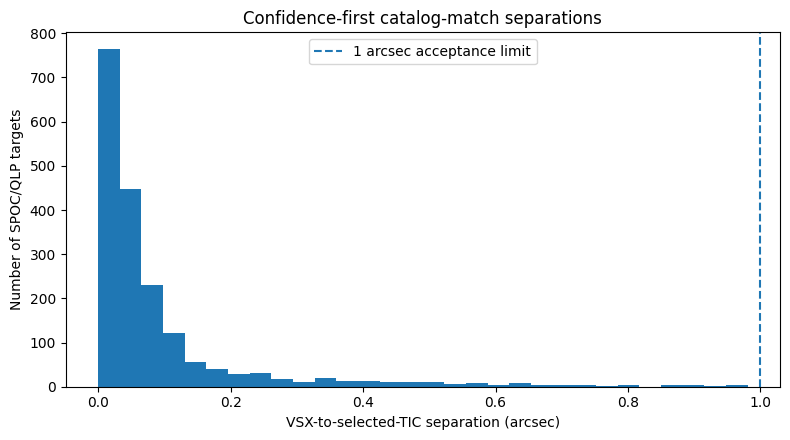

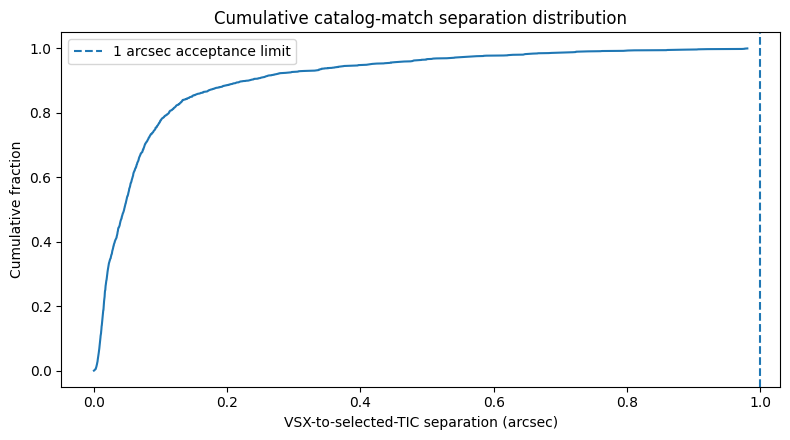

In [12]:
catalog = available[
    available["provenance"].astype(str).str.upper().isin(["SPOC", "QLP"])
].copy()

if catalog.empty:
    print("No SPOC/QLP rows were found.")
else:
    def summarize_catalog(group):
        distance = group["selectedDistanceArcsec"].dropna()
        return pd.Series({
            "n": len(group),
            "known_distance_n": len(distance),
            "mean_arcsec": distance.mean() if len(distance) else np.nan,
            "median_arcsec": distance.median() if len(distance) else np.nan,
            "p95_arcsec": distance.quantile(0.95) if len(distance) else np.nan,
            "max_arcsec": distance.max() if len(distance) else np.nan,
            "pct_within_1_arcsec": 100.0 * (distance <= 1.0).mean() if len(distance) else np.nan,
            "pct_selected_is_closest": 100.0 * group["selectedIsClosestTic"].mean(),
        })

    catalog_summary = (
        catalog.groupby("provenance", dropna=False)
        .apply(summarize_catalog)
        .reset_index()
    )
    display(catalog_summary.style.format({
        "mean_arcsec": "{:.4f}",
        "median_arcsec": "{:.4f}",
        "p95_arcsec": "{:.4f}",
        "max_arcsec": "{:.4f}",
        "pct_within_1_arcsec": "{:.2f}%",
        "pct_selected_is_closest": "{:.2f}%",
    }))

    family_summary = (
        catalog.groupby(["provenance", "family"], dropna=False)
        .apply(summarize_catalog)
        .reset_index()
        .sort_values(["provenance", "median_arcsec"])
    )
    display(family_summary.style.format({
        "mean_arcsec": "{:.4f}",
        "median_arcsec": "{:.4f}",
        "p95_arcsec": "{:.4f}",
        "max_arcsec": "{:.4f}",
        "pct_within_1_arcsec": "{:.2f}%",
        "pct_selected_is_closest": "{:.2f}%",
    }))

    distance = catalog["selectedDistanceArcsec"].dropna()
    if len(distance):
        plt.figure(figsize=(8, 4.5))
        plt.hist(distance, bins=30)
        plt.axvline(1.0, linestyle="--", label="1 arcsec acceptance limit")
        plt.xlabel("VSX-to-selected-TIC separation (arcsec)")
        plt.ylabel("Number of SPOC/QLP targets")
        plt.title("Confidence-first catalog-match separations")
        plt.legend()
        plt.tight_layout()
        plt.show()

        sorted_distance = np.sort(distance.to_numpy())
        cumulative = np.arange(1, len(sorted_distance) + 1) / len(sorted_distance)
        plt.figure(figsize=(8, 4.5))
        plt.plot(sorted_distance, cumulative)
        plt.axvline(1.0, linestyle="--", label="1 arcsec acceptance limit")
        plt.xlabel("VSX-to-selected-TIC separation (arcsec)")
        plt.ylabel("Cumulative fraction")
        plt.title("Cumulative catalog-match separation distribution")
        plt.legend()
        plt.tight_layout()
        plt.show()


## 3.3 TESSCut fallback and acquisition completeness

TESSCut is centered on the original VSX coordinate, so TIC separation is not an extraction-error metric for these rows. Reliability is instead assessed through successful acquisition and, when coordinate metadata are available, agreement between the stored extraction center and the VSX position.


In [13]:
total_n = len(analysis)
available_n = int(analysis["lightCurveAvailable"].sum())
unavailable_n = total_n - available_n

provenance_upper = analysis["provenance"].astype(str).str.upper()
counts = {
    "SPOC": int((analysis["lightCurveAvailable"] & provenance_upper.eq("SPOC")).sum()),
    "QLP": int((analysis["lightCurveAvailable"] & provenance_upper.eq("QLP")).sum()),
    "TESSCut": int((analysis["lightCurveAvailable"] & provenance_upper.eq("TESSCUT")).sum()),
    "Unavailable": unavailable_n,
}

acquisition_summary = pd.DataFrame([
    {
        "Source": source,
        "Count": count,
        "PercentOfAllTargets": 100.0 * count / total_n,
    }
    for source, count in counts.items()
])

display(acquisition_summary.style.format({"PercentOfAllTargets": "{:.2f}%"}))
print(f"Overall acquisition success: {available_n:,}/{total_n:,} ({100.0 * available_n / total_n:.2f}%)")

tesscut = available[available["provenance"].astype(str).str.upper().eq("TESSCUT")].copy()
print(f"TESSCut light curves: {len(tesscut):,}")

known_tesscut_offsets = tesscut["tesscutMetadataVsxOffsetArcsec"].dropna()
if len(known_tesscut_offsets):
    display(
        known_tesscut_offsets.describe(percentiles=[0.50, 0.90, 0.95, 0.99])
        .to_frame("TESSCut metadata-to-VSX offset (arcsec)")
    )
else:
    print(
        "No stored TESSCut center coordinates were available for numerical verification. "
        "Under the pipeline design, TESSCut is requested at the original VSX RA/Dec."
    )


,Source,Count,PercentOfAllTargets
0,SPOC,509,6.98%
1,QLP,1366,18.73%
2,TESSCut,5419,74.29%
3,Unavailable,0,0.00%


Overall acquisition success: 7,294/7,294 (100.00%)
TESSCut light curves: 5,419
No stored TESSCut center coordinates were available for numerical verification. Under the pipeline design, TESSCut is requested at the original VSX RA/Dec.


## 3.4 Duplicate selected-TIC check for catalog products

A duplicated TIC means that more than one VSX record ultimately points to the same catalog source. This check is limited to SPOC and QLP rows because TESSCut extraction is based on VSX coordinates rather than a selected TIC product.


In [14]:
if catalog.empty:
    dup_catalog = pd.DataFrame()
    print("No SPOC/QLP catalog rows to check.")
else:
    dup_catalog = (
        catalog.dropna(subset=["selectedTicId"])
        .groupby("selectedTicId")
        .agg(
            n_vsx=("selectedTicId", "size"),
            vsx_names=("VSXName", lambda x: ", ".join(sorted(set(map(str, x))))),
            families=("family", lambda x: ", ".join(sorted(set(map(str, x))))),
            provenances=("provenance", lambda x: ", ".join(sorted(set(map(str, x))))),
            min_distance_arcsec=("selectedDistanceArcsec", "min"),
            max_distance_arcsec=("selectedDistanceArcsec", "max"),
        )
        .query("n_vsx > 1")
        .sort_values(["n_vsx", "max_distance_arcsec"], ascending=False)
    )

    print(f"Duplicated selected TICs among SPOC/QLP rows: {len(dup_catalog):,}")
    display(dup_catalog.head(30))


Duplicated selected TICs among SPOC/QLP rows: 0


,n_vsx,vsx_names,families,provenances,min_distance_arcsec,max_distance_arcsec
selectedTicId,,,,,,


## 3.5 Reliability conclusion

The following conclusion is generated from the current augmented metadata rather than from hardcoded values.


In [15]:
n_catalog = len(catalog)
n_tesscut = len(tesscut)

catalog_distance = catalog["selectedDistanceArcsec"].dropna() if n_catalog else pd.Series(dtype=float)
within_one_pct = 100.0 * (catalog_distance <= 1.0).mean() if len(catalog_distance) else np.nan
closest_pct = 100.0 * catalog["selectedIsClosestTic"].mean() if n_catalog else np.nan
duplicate_tic_n = len(dup_catalog) if isinstance(dup_catalog, pd.DataFrame) else 0

if len(known_tesscut_offsets):
    tesscut_offset_statement = (
        f"Stored extraction-center coordinates were available for {len(known_tesscut_offsets):,} "
        f"TESSCut rows; their median offset from VSX was "
        f"{known_tesscut_offsets.median():.6f} arcsec."
    )
else:
    tesscut_offset_statement = (
        "Stored extraction-center coordinates were not available for numerical verification, "
        "but the acquisition routine requests TESSCut at the original VSX coordinates."
    )

md_text = f"""
**Confidence-first reliability interpretation**

- Total VSX targets evaluated: **{total_n:,}**.
- Successfully acquired light curves: **{available_n:,} ({100.0 * available_n / total_n:.2f}%)**.
- SPOC/QLP catalog-product associations: **{n_catalog:,}**.
- TESSCut fallback light curves: **{n_tesscut:,}**.
- Catalog matches with a measured separation at or below 1 arcsec: **{within_one_pct:.2f}%**.
- Catalog rows whose selected TIC agrees with the retained closest TIC: **{closest_pct:.2f}%**.
- Duplicated selected TIC IDs among SPOC/QLP associations: **{duplicate_tic_n:,}**.

**TESSCut positional interpretation:** {tesscut_offset_statement}

**Conclusion:**  
The confidence-first strategy limits catalog associations to the nearest TIC within 1 arcsec and does not search progressively more distant alternatives. For sources lacking SPOC or QLP products, VSX-centered TESSCut preserves dataset coverage without introducing a second, less certain TIC association. Positional cross-match uncertainty is therefore concentrated in the SPOC/QLP subset and can be evaluated directly from the retained TIC separation. For TESSCut, the principal downstream concern is photometric blending and provenance rather than catalog-coordinate mismatch. These checks provide a defensible foundation for subsequent feature extraction and provenance-sensitive model comparisons.
"""

display(Markdown(md_text))



**Confidence-first reliability interpretation**

- Total VSX targets evaluated: **7,294**.
- Successfully acquired light curves: **7,294 (100.00%)**.
- SPOC/QLP catalog-product associations: **1,875**.
- TESSCut fallback light curves: **5,419**.
- Catalog matches with a measured separation at or below 1 arcsec: **100.00%**.
- Catalog rows whose selected TIC agrees with the retained closest TIC: **100.00%**.
- Duplicated selected TIC IDs among SPOC/QLP associations: **0**.

**TESSCut positional interpretation:** Stored extraction-center coordinates were not available for numerical verification, but the acquisition routine requests TESSCut at the original VSX coordinates.

**Conclusion:**  
The confidence-first strategy limits catalog associations to the nearest TIC within 1 arcsec and does not search progressively more distant alternatives. For sources lacking SPOC or QLP products, VSX-centered TESSCut preserves dataset coverage without introducing a second, less certain TIC association. Positional cross-match uncertainty is therefore concentrated in the SPOC/QLP subset and can be evaluated directly from the retained TIC separation. For TESSCut, the principal downstream concern is photometric blending and provenance rather than catalog-coordinate mismatch. These checks provide a defensible foundation for subsequent feature extraction and provenance-sensitive model comparisons.


# Chapter 4. SIMBAD Proper-Motion Validation of the 1 Arcsecond Matching Radius

## 4.1 Purpose and data flow

This chapter quantitatively tests whether stellar proper motion could move a genuine counterpart outside the adopted **1 arcsecond** VSX→TESS search radius.

The analysis reads directly from `AUGMENTED_METADATA_FILE`, using:

- `raDeg` and `decDeg` as the original VSX coordinates;
- `extractionMetadata` as the provenance-specific light-curve metadata;
- the `sectors` list inside `extractionMetadata` for SPOC, QLP, and TESSCut products;
- SIMBAD `pmra` and `pmdec` values in milliarcseconds per year;
- the midpoint of the **latest valid TESS sector** as the conservative TESS observation epoch.

Using the latest sector gives the longest J2000→TESS baseline and therefore the largest expected proper-motion displacement for an object observed in multiple sectors. Invalid sector values are retained in audit columns and excluded from the epoch calculation.

The expected angular displacement is

$$
\Delta\theta =
\frac{\sqrt{\mu_{\alpha *}^{2}+\mu_{\delta}^{2}}\;\Delta t}{1000},
$$

where $$\Delta t$$ is measured from epoch J2000.0 and the result is in arcseconds.

The sector midpoint is estimated from the continuous TESS sector sequence using Sector 1 midpoint (2018-08-08 UTC) and a nominal 27.4-day sector spacing. This is sufficiently precise for a decades-long proper-motion baseline; an error of several days changes the expected displacement by a negligible fraction.

The enriched result is saved to `SIMBAD_PROPER_MOTION_FILE`. The original `AUGMENTED_METADATA_FILE` is not modified.


In [3]:
# ============================================================
# 4.2 Configuration
# ============================================================

from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time
from astropy import units as u
from astroquery.simbad import Simbad
from IPython.display import display, Markdown

import math
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIMBAD_QUERY_RADIUS_ARCSEC = 5.0
SIMBAD_QUERY_PAUSE_SECONDS = 0.10
SIMBAD_CHECKPOINT_EVERY = 50
SIMBAD_MAX_ROWS = None       # Set to a small integer for a test run.
VSX_REFERENCE_EPOCH = 2000.0

EXPECTED_MOTION_COLUMN = "expectedProperMotionArcsec"

print("Input :", AUGMENTED_METADATA_FILE)
print("Output:", SIMBAD_PROPER_MOTION_FILE)
print("RUN_SIMBAD_PROPER_MOTION =", RUN_SIMBAD_PROPER_MOTION)


Input : /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented.parquet
Output: /data/projects/TESS-research/data_pipeline/TESSCache/SimbadProperMotion.parquet
RUN_SIMBAD_PROPER_MOTION = True


## 4.3 Helper functions

The code below is intentionally defensive:

- it parses `extractionMetadata` whether stored as a dictionary or JSON string;
- it extracts and validates the provenance-specific `sectors` list;
- it records valid and invalid sector values for auditability;
- it uses the latest valid sector as a conservative observation epoch;
- it treats missing SIMBAD proper motion as unknown rather than zero;
- it retains SIMBAD match distance and identifiers for auditability;
- it can resume from an existing `SIMBAD_PROPER_MOTION_FILE` checkpoint;
- it requests SIMBAD proper motion and `flux(I)` in the same query;
- it extracts `ticTmag` from the first retained dictionary in `ticCandidates`;
- it distinguishes a completed SIMBAD I query with no published value from an old checkpoint that never queried I;
- it reuses magnitude-aware SIMBAD results when only local sector or TIC-derived fields need repair.


In [4]:
# ============================================================
# 4.3 Helper functions
# ============================================================

import ast
import json

# Sector 1 observed approximately 2018-07-25 through 2018-08-22.
# Its midpoint is used as the reference for a nominal continuous sector sequence.
TESS_SECTOR_1_MIDPOINT = Time("2018-08-08T00:00:00", scale="utc")
TESS_NOMINAL_SECTOR_LENGTH_DAYS = 27.4
TESS_MAX_REASONABLE_SECTOR = 200


def _finite_float(value):
    """Convert scalar-like values to a finite float; otherwise return NaN."""
    try:
        if value is None or np.ma.is_masked(value):
            return np.nan
        result = float(value)
        return result if np.isfinite(result) else np.nan
    except Exception:
        return np.nan


def _first_existing_column(table, candidates):
    """Return the first table column whose lowercase name matches a candidate."""
    if table is None:
        return None
    by_lower = {str(name).lower(): name for name in table.colnames}
    for candidate in candidates:
        if candidate.lower() in by_lower:
            return by_lower[candidate.lower()]
    return None


def _parse_nested_value(value):
    """Parse dict/list metadata stored natively, as JSON, or as Python-literal text."""
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, tuple):
        return list(value)
    if isinstance(value, (dict, list)):
        return value

    if isinstance(value, str):
        text = value.strip()
        if not text or text.lower() in {"none", "nan", "null", "<na>"}:
            return None
        for parser in (json.loads, ast.literal_eval):
            try:
                return parser(text)
            except Exception:
                continue
    return value


def extract_selected_tic_tmag(tic_candidates):
    """
    Extract Tmag from the retained/closest TIC candidate.

    Handles:
      * native list[dict]
      * numpy arrays / tuples
      * JSON text
      * Python-literal text such as:
        [{'ticId': '180205959', 'ticTmag': 15.9752, ...}]
    """
    parsed = _parse_nested_value(tic_candidates)

    if isinstance(parsed, dict):
        # Be tolerant of a wrapper dictionary as well as a direct candidate.
        for wrapper_key in ("ticCandidates", "candidates", "results"):
            wrapped = parsed.get(wrapper_key)
            if isinstance(wrapped, (list, tuple, np.ndarray)):
                parsed = list(wrapped)
                break
        else:
            parsed = [parsed]

    if not isinstance(parsed, list) or len(parsed) == 0:
        return np.nan, "tic_candidates_missing"

    candidate = parsed[0]
    if not isinstance(candidate, dict):
        return np.nan, "first_tic_candidate_not_dict"

    # Exact pipeline field first, with conservative aliases for older files.
    for key in ("ticTmag", "Tmag", "tmag", "ticMag"):
        if key in candidate:
            value = _finite_float(candidate.get(key))
            if np.isfinite(value):
                return value, "ok"
            return np.nan, f"{key}_not_numeric"

    return np.nan, "tic_tmag_field_missing"


def _parse_extraction_metadata(value):
    """Return extractionMetadata as a dictionary when possible."""
    parsed = _parse_nested_value(value)
    return parsed if isinstance(parsed, dict) else {}


def _coerce_sector_list(raw_sectors):
    """Return sorted unique valid sectors and a list of rejected values."""
    if raw_sectors is None:
        return [], []

    if isinstance(raw_sectors, (str, int, float, np.integer, np.floating)):
        raw_sectors = [raw_sectors]
    elif isinstance(raw_sectors, np.ndarray):
        raw_sectors = raw_sectors.tolist()

    if not isinstance(raw_sectors, (list, tuple)):
        return [], [raw_sectors]

    valid, invalid = [], []
    for raw in raw_sectors:
        try:
            numeric = float(raw)
            sector = int(numeric)
            if numeric != sector or not (1 <= sector <= TESS_MAX_REASONABLE_SECTOR):
                invalid.append(raw)
            else:
                valid.append(sector)
        except Exception:
            invalid.append(raw)

    return sorted(set(valid)), invalid


def tess_sector_midpoint(sector):
    """Approximate a TESS sector midpoint from a nominal 27.4-day sequence."""
    return TESS_SECTOR_1_MIDPOINT + (int(sector) - 1) * TESS_NOMINAL_SECTOR_LENGTH_DAYS * u.day


def read_tess_observation_epoch(extraction_metadata):
    """Extract sectors and derive a conservative epoch from the latest valid sector."""
    result = {
        "tessSectors": pd.NA,
        "tessValidSectors": "[]",
        "tessInvalidSectors": "[]",
        "tessEarliestSector": np.nan,
        "tessLatestSector": np.nan,
        "tessSectorCountValid": 0,
        "tessObservationYear": np.nan,
        "tessEpochSource": pd.NA,
        "tessEpochStatus": "metadata_missing",
    }

    metadata = _parse_extraction_metadata(extraction_metadata)
    if not metadata:
        return result

    raw_sectors = metadata.get("sectors")
    valid_sectors, invalid_sectors = _coerce_sector_list(raw_sectors)

    result["tessSectors"] = json.dumps(raw_sectors, default=str) if raw_sectors is not None else pd.NA
    result["tessValidSectors"] = json.dumps(valid_sectors)
    result["tessInvalidSectors"] = json.dumps(invalid_sectors, default=str)
    result["tessSectorCountValid"] = len(valid_sectors)

    if not valid_sectors:
        result["tessEpochStatus"] = "no_valid_tess_sector"
        return result

    earliest_sector = min(valid_sectors)
    latest_sector = max(valid_sectors)
    midpoint = tess_sector_midpoint(latest_sector)

    result.update({
        "tessEarliestSector": earliest_sector,
        "tessLatestSector": latest_sector,
        "tessObservationYear": float(midpoint.jyear),
        "tessEpochSource": "latest extractionMetadata sector midpoint",
        "tessEpochStatus": "ok_with_invalid_sectors" if invalid_sectors else "ok",
    })
    return result


def query_simbad_proper_motion_and_i_mag(ra_deg, dec_deg, radius_arcsec=5.0):
    """
    Query SIMBAD around the VSX coordinate and retain the nearest returned object.

    SIMBAD pmra is μ_alpha*cos(delta), so no additional cos(delta) correction
    is applied when calculating total proper motion. The I magnitude is requested
    as SIMBAD's flux(I) field. Because SIMBAD compiles heterogeneous literature,
    an I value is legitimately unavailable for some matched objects.
    """
    result = {
        "simbadMainId": pd.NA,
        "simbadRaDeg": np.nan,
        "simbadDecDeg": np.nan,
        "simbadMatchDistanceArcsec": np.nan,
        "simbadPmRaMasYr": np.nan,
        "simbadPmDecMasYr": np.nan,
        "simbadTotalPmMasYr": np.nan,
        "simbadIMag": np.nan,
        "simbadIMagStatus": "not_processed",
        "simbadQueryStatus": "not_processed",
        "simbadPhotometryQueryVersion": 1,
    }

    ra = _finite_float(ra_deg)
    dec = _finite_float(dec_deg)
    if not np.isfinite(ra) or not np.isfinite(dec):
        result["simbadQueryStatus"] = "invalid_vsx_coordinates"
        result["simbadIMagStatus"] = "invalid_vsx_coordinates"
        return result

    coordinate = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")

    try:
        table = simbad_client.query_region(
            coordinate,
            radius=float(radius_arcsec) * u.arcsec,
        )

        if table is None or len(table) == 0:
            result["simbadQueryStatus"] = "no_simbad_match"
            result["simbadIMagStatus"] = "no_simbad_match"
            return result

        ra_col = _first_existing_column(table, ["ra"])
        dec_col = _first_existing_column(table, ["dec"])
        main_id_col = _first_existing_column(table, ["main_id"])
        pmra_col = _first_existing_column(table, ["pmra"])
        pmdec_col = _first_existing_column(table, ["pmdec"])

        # astroquery/SIMBAD versions have used several column spellings.
        i_mag_col = _first_existing_column(
            table,
            ["I", "flux_i", "FLUX_I", "flux(I)", "i_mag"],
        )

        if ra_col is None or dec_col is None:
            result["simbadQueryStatus"] = "simbad_coordinates_missing"
            result["simbadIMagStatus"] = "simbad_coordinates_missing"
            return result

        simbad_coordinates = SkyCoord(
            ra=np.asarray(table[ra_col], dtype=float) * u.deg,
            dec=np.asarray(table[dec_col], dtype=float) * u.deg,
            frame="icrs",
        )
        separations = coordinate.separation(simbad_coordinates).arcsec
        nearest_index = int(np.nanargmin(separations))
        row = table[nearest_index]

        pmra = _finite_float(row[pmra_col]) if pmra_col is not None else np.nan
        pmdec = _finite_float(row[pmdec_col]) if pmdec_col is not None else np.nan
        total_pm = np.hypot(pmra, pmdec) if np.isfinite(pmra) and np.isfinite(pmdec) else np.nan
        i_mag = _finite_float(row[i_mag_col]) if i_mag_col is not None else np.nan

        main_id = row[main_id_col] if main_id_col is not None else pd.NA
        if isinstance(main_id, bytes):
            main_id = main_id.decode("utf-8", errors="replace")

        result.update({
            "simbadMainId": str(main_id) if not pd.isna(main_id) else pd.NA,
            "simbadRaDeg": _finite_float(row[ra_col]),
            "simbadDecDeg": _finite_float(row[dec_col]),
            "simbadMatchDistanceArcsec": float(separations[nearest_index]),
            "simbadPmRaMasYr": pmra,
            "simbadPmDecMasYr": pmdec,
            "simbadTotalPmMasYr": total_pm,
            "simbadIMag": i_mag,
            "simbadIMagStatus": (
                "ok" if np.isfinite(i_mag)
                else ("i_field_not_returned" if i_mag_col is None else "matched_but_i_missing")
            ),
            "simbadQueryStatus": (
                "ok" if np.isfinite(pmra) and np.isfinite(pmdec)
                else "matched_but_pm_missing"
            ),
        })
        return result

    except Exception as exc:
        result["simbadQueryStatus"] = f"query_error:{type(exc).__name__}"
        result["simbadIMagStatus"] = f"query_error:{type(exc).__name__}"
        return result


def expected_motion_arcsec(total_pm_mas_yr, observation_year, reference_epoch=2000.0):
    """Expected displacement in arcseconds between reference and observation epochs."""
    total_pm = _finite_float(total_pm_mas_yr)
    obs_year = _finite_float(observation_year)

    if not np.isfinite(total_pm) or not np.isfinite(obs_year):
        return np.nan

    elapsed_years = abs(obs_year - float(reference_epoch))
    return total_pm * elapsed_years / 1000.0


def atomic_write_parquet(dataframe, output_path):
    """Write parquet through a temporary file to reduce checkpoint corruption risk."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = output_path.with_suffix(output_path.suffix + ".tmp")
    dataframe.to_parquet(temporary_path, index=False)
    os.replace(temporary_path, output_path)


# Configure a reusable SIMBAD client.
simbad_client = Simbad()
try:
    simbad_client.add_votable_fields("pmra", "pmdec", "flux(I)")
except Exception as exc:
    # Some astroquery versions require fields to be added one at a time.
    warnings.warn(f"Combined SIMBAD field setup failed; retrying individually: {exc}")
    for field in ("pmra", "pmdec", "flux(I)"):
        try:
            simbad_client.add_votable_fields(field)
        except Exception as field_exc:
            warnings.warn(f"Could not add SIMBAD field {field!r}: {field_exc}")


/tmp/ipykernel_690666/2352555263.py:318: DeprecationWarning: The notation 'flux(I)' is deprecated since 0.4.8 in favor of 'I'. You will see the column appearing with its new name in the output. See section on filters in https://astroquery.readthedocs.io/en/latest/simbad/simbad_evolution.html to see the new ways to interact with SIMBAD's fluxes.
  simbad_client.add_votable_fields("pmra", "pmdec", "flux(I)")


## 4.4 Build the proper-motion and magnitude-validation parquet file

Set `RUN_SIMBAD_PROPER_MOTION = True` in the global configuration cell to execute this stage.

The output preserves all columns from `AUGMENTED_METADATA_FILE` and adds:

- `simbadMainId`
- `simbadRaDeg`, `simbadDecDeg`
- `simbadMatchDistanceArcsec`
- `simbadPmRaMasYr`, `simbadPmDecMasYr`, `simbadTotalPmMasYr`
- `tessSectors`, `tessValidSectors`, `tessInvalidSectors`
- `tessEarliestSector`, `tessLatestSector`, `tessSectorCountValid`
- `tessObservationYear`, derived from the latest valid sector
- `properMotionBaselineYears`
- `expectedProperMotionArcsec`
- `simbadIMag`, requested from SIMBAD as `flux(I)`, and `simbadIMagStatus`
- `ticTmag`, extracted from the first retained entry in `ticCandidates`, and `ticTmagStatus`
- `simbadMinusTicMag = simbadIMag - ticTmag` and its absolute value
- status columns describing SIMBAD, magnitude, TIC-candidate, and sector-metadata failures

Magnitude-aware SIMBAD checkpoint rows are reused. Older proper-motion-only checkpoint rows are re-queried once so that a missing I magnitude is not confused with a query that never requested `flux(I)`. TIC Tmag and sector-derived fields are always rebuilt locally from the current augmented metadata.


In [ ]:
# ============================================================
# 4.4 Integrated SIMBAD proper-motion and magnitude pass
# ============================================================

input_path = Path(AUGMENTED_METADATA_FILE)
output_path = Path(SIMBAD_PROPER_MOTION_FILE)

if not input_path.exists():
    raise FileNotFoundError(f"AUGMENTED_METADATA_FILE does not exist: {input_path}")

source_df = pd.read_parquet(input_path).copy()
if source_df.empty:
    raise ValueError(f"AUGMENTED_METADATA_FILE contains no rows: {input_path}")

required_columns = ["raDeg", "decDeg", "extractionMetadata", "ticCandidates"]
missing_required = [column for column in required_columns if column not in source_df.columns]
if missing_required:
    raise KeyError(
        "AUGMENTED_METADATA_FILE is missing required Chapter 4 columns: "
        f"{missing_required}. Available columns: {list(source_df.columns)}"
    )

source_df = source_df.reset_index(drop=True)
source_df["_properMotionRowId"] = np.arange(len(source_df), dtype=np.int64)

result_columns = [
    "simbadMainId", "simbadRaDeg", "simbadDecDeg",
    "simbadMatchDistanceArcsec", "simbadPmRaMasYr", "simbadPmDecMasYr",
    "simbadTotalPmMasYr", "simbadQueryStatus",
    "simbadIMag", "simbadIMagStatus", "simbadPhotometryQueryVersion",
    "ticTmag", "ticTmagStatus", "simbadMinusTicMag",
    "absSimbadMinusTicMag", "magnitudeComparisonStatus",
    "tessSectors", "tessValidSectors", "tessInvalidSectors",
    "tessEarliestSector", "tessLatestSector", "tessSectorCountValid",
    "tessObservationYear", "tessEpochSource", "tessEpochStatus",
    "properMotionReferenceEpoch", "properMotionBaselineYears",
    EXPECTED_MOTION_COLUMN, "properMotionAnalysisStatus",
]

for column in result_columns:
    if column not in source_df.columns:
        source_df[column] = pd.NA

# Reuse checkpoint values only when they were produced by the magnitude-aware
# query version. An older proper-motion-only checkpoint is intentionally
# re-queried for matched rows so that missing I values are not mistaken for a
# completed photometry query.
if output_path.exists():
    checkpoint_df = pd.read_parquet(output_path)
    if "_properMotionRowId" in checkpoint_df.columns:
        reusable_columns = [
            column for column in [
                "simbadMainId", "simbadRaDeg", "simbadDecDeg",
                "simbadMatchDistanceArcsec", "simbadPmRaMasYr",
                "simbadPmDecMasYr", "simbadTotalPmMasYr", "simbadQueryStatus",
                "simbadIMag", "simbadIMagStatus", "simbadPhotometryQueryVersion",
            ]
            if column in checkpoint_df.columns
        ]
        checkpoint_subset = checkpoint_df[
            ["_properMotionRowId"] + reusable_columns
        ].drop_duplicates("_properMotionRowId", keep="last")

        source_df = source_df.drop(columns=reusable_columns, errors="ignore").merge(
            checkpoint_subset, on="_properMotionRowId", how="left"
        )
        for column in result_columns:
            if column not in source_df.columns:
                source_df[column] = pd.NA
        print(f"Loaded checkpoint: {output_path}")

pending_indices = source_df.index.tolist()
if SIMBAD_MAX_ROWS is not None:
    pending_indices = pending_indices[: int(SIMBAD_MAX_ROWS)]

print(f"Input rows: {len(source_df):,}")
print(f"Rows considered this run: {len(pending_indices):,}")

if RUN_SIMBAD_PROPER_MOTION:
    completed_since_checkpoint = 0
    reused_simbad_count = 0
    queried_simbad_count = 0

    for sequence_number, row_index in enumerate(pending_indices, start=1):
        row = source_df.loc[row_index]

        # Always rebuild local TIC magnitude and sector epoch from current input.
        tic_tmag, tic_tmag_status = extract_selected_tic_tmag(row.get("ticCandidates"))
        epoch_result = read_tess_observation_epoch(row.get("extractionMetadata"))

        existing_status = row.get("simbadQueryStatus", "")
        query_version = _finite_float(row.get("simbadPhotometryQueryVersion"))
        photometry_was_queried = np.isfinite(query_version) and query_version >= 1

        terminal_no_match_status = existing_status in {
            "no_simbad_match", "simbad_coordinates_missing", "invalid_vsx_coordinates",
        }
        has_reusable_simbad = photometry_was_queried or terminal_no_match_status

        if has_reusable_simbad:
            simbad_result = {
                key: row.get(key, pd.NA)
                for key in [
                    "simbadMainId", "simbadRaDeg", "simbadDecDeg",
                    "simbadMatchDistanceArcsec", "simbadPmRaMasYr",
                    "simbadPmDecMasYr", "simbadTotalPmMasYr", "simbadQueryStatus",
                    "simbadIMag", "simbadIMagStatus", "simbadPhotometryQueryVersion",
                ]
            }
            reused_simbad_count += 1
        else:
            simbad_result = query_simbad_proper_motion_and_i_mag(
                row["raDeg"], row["decDeg"],
                radius_arcsec=SIMBAD_QUERY_RADIUS_ARCSEC,
            )
            queried_simbad_count += 1

        for key, value in simbad_result.items():
            source_df.at[row_index, key] = value
        for key, value in epoch_result.items():
            source_df.at[row_index, key] = value

        source_df.at[row_index, "ticTmag"] = tic_tmag
        source_df.at[row_index, "ticTmagStatus"] = tic_tmag_status

        simbad_i = _finite_float(simbad_result.get("simbadIMag"))
        if np.isfinite(simbad_i) and np.isfinite(tic_tmag):
            delta_mag = simbad_i - tic_tmag
            magnitude_status = "ok"
        elif not np.isfinite(simbad_i) and not np.isfinite(tic_tmag):
            delta_mag = np.nan
            magnitude_status = "simbad_i_and_tic_tmag_missing"
        elif not np.isfinite(simbad_i):
            delta_mag = np.nan
            magnitude_status = "simbad_i_missing"
        else:
            delta_mag = np.nan
            magnitude_status = "tic_tmag_missing"

        source_df.at[row_index, "simbadMinusTicMag"] = delta_mag
        source_df.at[row_index, "absSimbadMinusTicMag"] = (
            abs(delta_mag) if np.isfinite(delta_mag) else np.nan
        )
        source_df.at[row_index, "magnitudeComparisonStatus"] = magnitude_status

        observation_year = _finite_float(epoch_result["tessObservationYear"])
        total_pm = _finite_float(simbad_result.get("simbadTotalPmMasYr"))

        source_df.at[row_index, "properMotionReferenceEpoch"] = VSX_REFERENCE_EPOCH
        source_df.at[row_index, "properMotionBaselineYears"] = (
            abs(observation_year - VSX_REFERENCE_EPOCH)
            if np.isfinite(observation_year) else np.nan
        )
        source_df.at[row_index, EXPECTED_MOTION_COLUMN] = expected_motion_arcsec(
            total_pm, observation_year, reference_epoch=VSX_REFERENCE_EPOCH,
        )

        if simbad_result.get("simbadQueryStatus") == "invalid_vsx_coordinates":
            final_status = "invalid_vsx_coordinates"
        elif np.isfinite(total_pm) and np.isfinite(observation_year):
            final_status = "ok"
        elif not np.isfinite(total_pm) and not np.isfinite(observation_year):
            final_status = "simbad_pm_and_tess_epoch_missing"
        elif not np.isfinite(total_pm):
            final_status = "simbad_pm_missing"
        else:
            final_status = "tess_epoch_missing"

        source_df.at[row_index, "properMotionAnalysisStatus"] = final_status
        completed_since_checkpoint += 1

        if (
            completed_since_checkpoint % SIMBAD_CHECKPOINT_EVERY == 0
            or sequence_number == len(pending_indices)
        ):
            atomic_write_parquet(source_df, output_path)
            print(
                f"Checkpointed {sequence_number:,}/{len(pending_indices):,} rows; "
                f"SIMBAD reused={reused_simbad_count:,}, queried={queried_simbad_count:,}"
            )

        if (not has_reusable_simbad) and SIMBAD_QUERY_PAUSE_SECONDS > 0:
            time.sleep(SIMBAD_QUERY_PAUSE_SECONDS)

    if not pending_indices:
        atomic_write_parquet(source_df, output_path)
        print("No pending rows; refreshed output parquet.")
else:
    print(
        "RUN_SIMBAD_PROPER_MOTION is False. No SIMBAD queries were made. "
        "Set it to True in the global configuration cell to generate or resume "
        "SIMBAD_PROPER_MOTION."
    )

preview_columns = [
    column for column in [
        "VSXName", "family", "provenance", "raDeg", "decDeg",
        "ticCandidates", "ticTmag", "ticTmagStatus",
        "simbadMainId", "simbadIMag", "simbadIMagStatus",
        "simbadMinusTicMag", "magnitudeComparisonStatus",
        "tessLatestSector", "tessObservationYear",
        EXPECTED_MOTION_COLUMN, "properMotionAnalysisStatus",
    ]
    if column in source_df.columns
]
display(source_df[preview_columns].head(10))


## 4.5 Quantitative validation

This section reports proper-motion coverage and displacement statistics, then evaluates the secondary photometric consistency check using the distribution of `SIMBAD I - TIC Tmag`. Because the two magnitudes use different passbands, their difference is interpreted as a diagnostic distribution rather than a zero-centered calibration residual.


Chapter 4 source: /data/projects/TESS-research/data_pipeline/TESSCache/SimbadProperMotion.parquet


,Metric,Count,Percent
0,Input rows,7294,100.00%
1,Nearest SIMBAD object found,6063,83.12%
2,SIMBAD proper motion available,5545,76.02%
3,TESS observation epoch available,7294,100.00%
4,Expected displacement calculated,5545,76.02%
5,SIMBAD I magnitude available,1563,21.43%
6,TIC Tmag extracted,7294,100.00%
7,I - Tmag comparison available,1563,21.43%


,Statistic,Arcsec
0,Median,0.113139
1,90th percentile,0.434479
2,95th percentile,0.659884
3,99th percentile,1.461090
4,Maximum,12.714933


,Threshold,Count,Percent
0,> 0.5 arcsec,461,8.314%
1,> 1.0 arcsec,102,1.839%
2,> 2.0 arcsec,37,0.667%


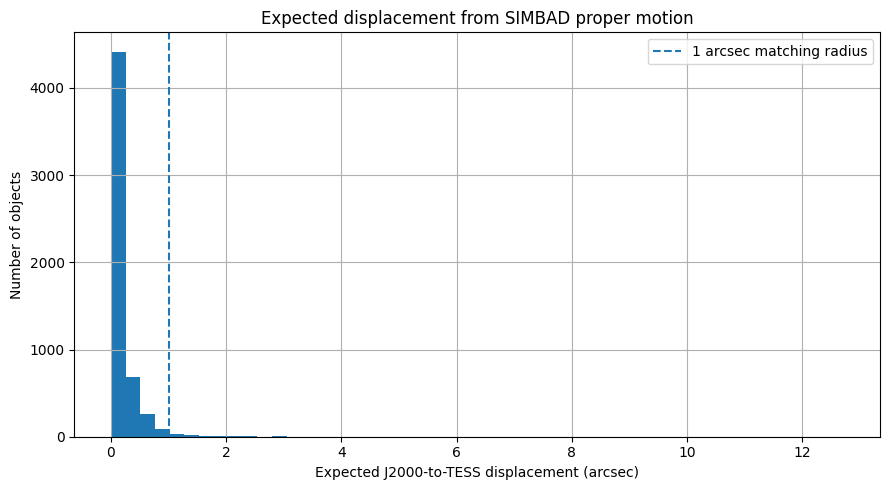

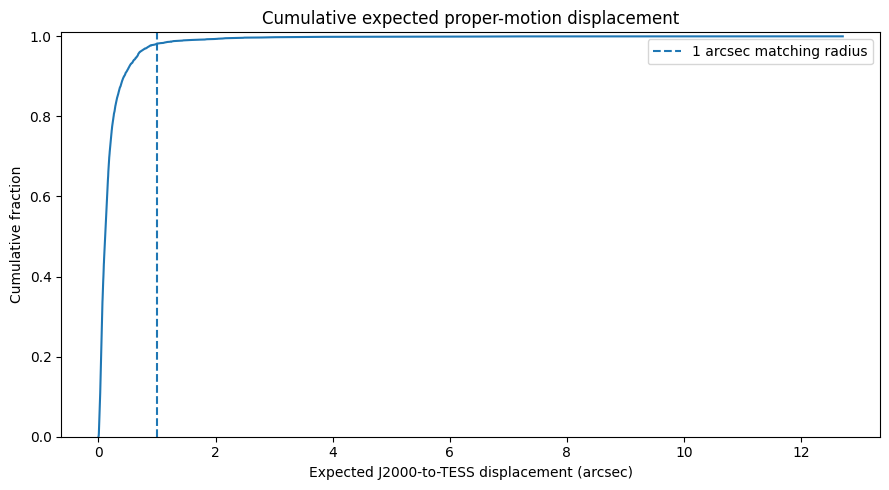

Expected displacement by provenance:


,provenance,Count,MedianArcsec,MaximumArcsec,AboveOneArcsec,AboveOneArcsecPercent
0,QLP,1196,0.131266,6.510871,28,2.341%
1,SPOC,434,0.345728,12.714933,45,10.369%
2,TESSCut,3915,0.094677,3.462795,29,0.741%


Expected displacement by family:


,family,Count,MedianArcsec,MaximumArcsec,AboveOneArcsec,AboveOneArcsecPercent
0,CEPHEID,916,0.086504,1.314048,1,0.109%
1,CV,153,0.219061,4.913592,4,2.614%
2,DSCT_SXPHE,667,0.156862,12.714933,25,3.748%
3,ECLIPSING,891,0.148865,3.462795,9,1.010%
4,ELLIPSOIDAL_ROT,287,0.205673,7.214889,29,10.105%
5,LONG_PERIOD,951,0.145773,2.844526,22,2.313%
6,RRLYR,839,0.070527,1.201796,1,0.119%
7,XRAY,41,0.115512,0.748586,0,0.000%
8,YSO,800,0.072840,3.268356,11,1.375%



SIMBAD I versus TIC Tmag


,Statistic,Value
0,Count,1563.0000
1,Mean I - Tmag,-0.2618
2,Median I - Tmag,-0.1931
3,MAD around median,0.1718
4,Standard deviation,0.7609
5,1st percentile,-1.8260
6,5th percentile,-1.3946
7,95th percentile,0.6030
8,99th percentile,2.9035
9,Minimum,-3.2865


,Threshold,Count,Percent
0,|I - Tmag| > 0.5 mag,486,31.09%
1,|I - Tmag| > 1.0 mag,252,16.12%
2,|I - Tmag| > 2.0 mag,38,2.43%


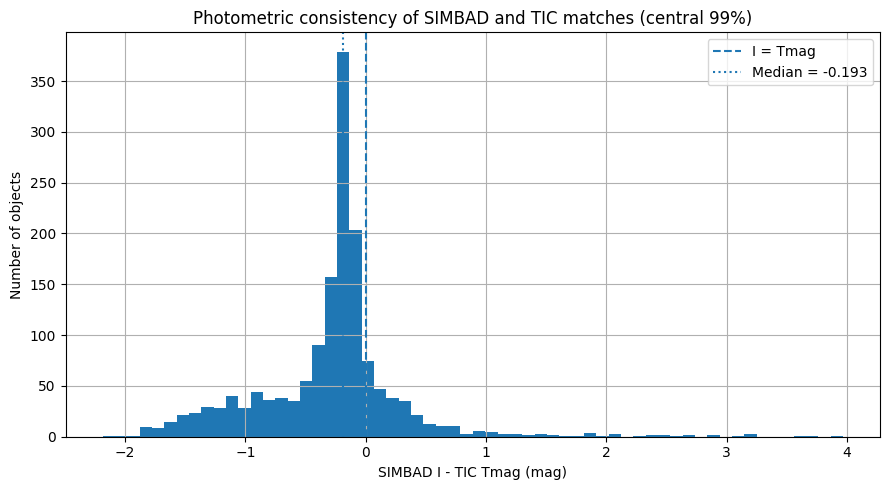

Twenty largest absolute I - Tmag discrepancies:


,VSXName,family,provenance,simbadMainId,simbadMatchDistanceArcsec,simbadIMag,ticTmag,simbadMinusTicMag,expectedProperMotionArcsec
4555,OGLE-GD-LPV-000971,LONG_PERIOD,QLP,IRAS 10067-5705,0.017669,17.702999,12.0340,5.668999,0.149572
5246,OGLE-BLG-LPV-262862,LONG_PERIOD,TESSCut,IRAS 18203-1559,0.011847,16.886000,11.3220,5.564000,0.049755
5056,OGLE-BLG-LPV-247872,LONG_PERIOD,TESSCut,OGLE BLG-LPV-247872,0.016944,19.482000,14.3160,5.166000,NaN
5154,BMAM-V685,LONG_PERIOD,QLP,IRAS 18533+0633,0.016809,14.603000,9.9220,4.681000,0.070010
4684,OGLE-BLG-LPV-254655,LONG_PERIOD,TESSCut,IRAS 17529-2000,0.016370,14.412000,10.0540,4.358000,0.070395
4519,V1644 Ori,LONG_PERIOD,TESSCut,IRAS 05552+1720,0.010712,14.000000,9.6520,4.348000,0.036986
5306,OGLE-BLG-LPV-260321,LONG_PERIOD,TESSCut,OGLE BLG-LPV-260321,0.015153,16.594999,12.3160,4.278999,0.173199
4468,NSV 19239,LONG_PERIOD,QLP,IRAS 12063-6157,0.017173,12.894000,8.6770,4.217000,0.239911
7257,[H97b] 5129,YSO,QLP,2MASS J05351015-0527574,0.101542,15.510000,11.5440,3.966000,NaN
6654,V2493 Cyg,YSO,QLP,V* V2493 Cyg,0.100012,15.233000,11.4745,3.758500,0.076473



SIMBAD I status:


,Count
Status,
matched_but_i_missing,4500
ok,1563
no_simbad_match,1231


TIC Tmag extraction status:


,Count
Status,
ok,7294


In [9]:
# ============================================================
# 4.5 Summary statistics and plots
# ============================================================

proper_motion_path = Path(SIMBAD_PROPER_MOTION_FILE)

if not proper_motion_path.exists():
    print(
        f"Proper-motion output does not yet exist: {proper_motion_path}\n"
        "Run Section 4.4 with RUN_SIMBAD_PROPER_MOTION = True first."
    )
else:
    pm_df = pd.read_parquet(proper_motion_path)

    # -----------------------------
    # Proper-motion validation
    # -----------------------------
    expected_motion = pd.to_numeric(pm_df.get(EXPECTED_MOTION_COLUMN), errors="coerce")
    valid_motion = expected_motion.dropna()

    total_rows = len(pm_df)
    simbad_matches = int(
        pm_df.get("simbadMainId", pd.Series(pd.NA, index=pm_df.index)).notna().sum()
    )
    pm_available = int(
        pd.to_numeric(pm_df.get("simbadTotalPmMasYr"), errors="coerce").notna().sum()
    )
    epoch_available = int(
        pd.to_numeric(pm_df.get("tessObservationYear"), errors="coerce").notna().sum()
    )
    fully_analyzed = len(valid_motion)

    # -----------------------------
    # Magnitude consistency
    # -----------------------------
    simbad_i = pd.to_numeric(pm_df.get("simbadIMag"), errors="coerce")
    tic_tmag = pd.to_numeric(pm_df.get("ticTmag"), errors="coerce")
    delta_mag = pd.to_numeric(pm_df.get("simbadMinusTicMag"), errors="coerce")
    valid_delta = delta_mag.dropna()
    abs_delta = valid_delta.abs()

    coverage_summary = pd.DataFrame([
        {"Metric": "Input rows", "Count": total_rows, "Percent": 100.0},
        {"Metric": "Nearest SIMBAD object found", "Count": simbad_matches,
         "Percent": 100.0 * simbad_matches / total_rows if total_rows else np.nan},
        {"Metric": "SIMBAD proper motion available", "Count": pm_available,
         "Percent": 100.0 * pm_available / total_rows if total_rows else np.nan},
        {"Metric": "TESS observation epoch available", "Count": epoch_available,
         "Percent": 100.0 * epoch_available / total_rows if total_rows else np.nan},
        {"Metric": "Expected displacement calculated", "Count": fully_analyzed,
         "Percent": 100.0 * fully_analyzed / total_rows if total_rows else np.nan},
        {"Metric": "SIMBAD I magnitude available", "Count": int(simbad_i.notna().sum()),
         "Percent": 100.0 * simbad_i.notna().mean() if total_rows else np.nan},
        {"Metric": "TIC Tmag extracted", "Count": int(tic_tmag.notna().sum()),
         "Percent": 100.0 * tic_tmag.notna().mean() if total_rows else np.nan},
        {"Metric": "I - Tmag comparison available", "Count": len(valid_delta),
         "Percent": 100.0 * len(valid_delta) / total_rows if total_rows else np.nan},
    ])

    print("Chapter 4 source:", proper_motion_path)
    display(coverage_summary.style.format({"Percent": "{:.2f}%"}))

    if not valid_motion.empty:
        quantiles = valid_motion.quantile([0.50, 0.90, 0.95, 0.99])
        displacement_summary = pd.DataFrame([
            {"Statistic": "Median", "Arcsec": quantiles.loc[0.50]},
            {"Statistic": "90th percentile", "Arcsec": quantiles.loc[0.90]},
            {"Statistic": "95th percentile", "Arcsec": quantiles.loc[0.95]},
            {"Statistic": "99th percentile", "Arcsec": quantiles.loc[0.99]},
            {"Statistic": "Maximum", "Arcsec": valid_motion.max()},
        ])
        threshold_summary = pd.DataFrame([
            {"Threshold": "> 0.5 arcsec", "Count": int((valid_motion > 0.5).sum()),
             "Percent": 100.0 * (valid_motion > 0.5).mean()},
            {"Threshold": "> 1.0 arcsec", "Count": int((valid_motion > 1.0).sum()),
             "Percent": 100.0 * (valid_motion > 1.0).mean()},
            {"Threshold": "> 2.0 arcsec", "Count": int((valid_motion > 2.0).sum()),
             "Percent": 100.0 * (valid_motion > 2.0).mean()},
        ])
        display(displacement_summary.style.format({"Arcsec": "{:.6f}"}))
        display(threshold_summary.style.format({"Percent": "{:.3f}%"}))

        plt.figure(figsize=(9, 5))
        valid_motion.hist(bins=50)
        plt.axvline(1.0, linestyle="--", label="1 arcsec matching radius")
        plt.xlabel("Expected J2000-to-TESS displacement (arcsec)")
        plt.ylabel("Number of objects")
        plt.title("Expected displacement from SIMBAD proper motion")
        plt.legend()
        plt.tight_layout()
        plt.show()

        sorted_motion = np.sort(valid_motion.to_numpy())
        cumulative_fraction = np.arange(1, len(sorted_motion) + 1) / len(sorted_motion)
        plt.figure(figsize=(9, 5))
        plt.plot(sorted_motion, cumulative_fraction)
        plt.axvline(1.0, linestyle="--", label="1 arcsec matching radius")
        plt.xlabel("Expected J2000-to-TESS displacement (arcsec)")
        plt.ylabel("Cumulative fraction")
        plt.title("Cumulative expected proper-motion displacement")
        plt.ylim(0, 1.01)
        plt.legend()
        plt.tight_layout()
        plt.show()

        for group_column in ["provenance", "family"]:
            if group_column not in pm_df.columns:
                continue
            grouped = (
                pm_df.assign(_expectedMotion=expected_motion)
                .dropna(subset=["_expectedMotion"])
                .groupby(group_column, dropna=False)["_expectedMotion"]
                .agg(
                    Count="size",
                    MedianArcsec="median",
                    MaximumArcsec="max",
                    AboveOneArcsec=lambda values: int((values > 1.0).sum()),
                )
                .reset_index()
            )
            grouped["AboveOneArcsecPercent"] = (
                100.0 * grouped["AboveOneArcsec"] / grouped["Count"]
            )
            print(f"Expected displacement by {group_column}:")
            display(grouped.style.format({
                "MedianArcsec": "{:.6f}",
                "MaximumArcsec": "{:.6f}",
                "AboveOneArcsecPercent": "{:.3f}%",
            }))
    else:
        print("No rows currently have both SIMBAD proper motion and a TESS epoch.")

    # -----------------------------
    # I - Tmag distribution
    # -----------------------------
    print("\nSIMBAD I versus TIC Tmag")
    if valid_delta.empty:
        print(
            "No rows currently have both SIMBAD I and TIC Tmag. "
            "Check simbadIMagStatus and ticTmagStatus."
        )
    else:
        median_delta = valid_delta.median()
        mad_delta = (valid_delta - median_delta).abs().median()
        magnitude_distribution = pd.DataFrame([
            {"Statistic": "Count", "Value": len(valid_delta)},
            {"Statistic": "Mean I - Tmag", "Value": valid_delta.mean()},
            {"Statistic": "Median I - Tmag", "Value": median_delta},
            {"Statistic": "MAD around median", "Value": mad_delta},
            {"Statistic": "Standard deviation", "Value": valid_delta.std()},
            {"Statistic": "1st percentile", "Value": valid_delta.quantile(0.01)},
            {"Statistic": "5th percentile", "Value": valid_delta.quantile(0.05)},
            {"Statistic": "95th percentile", "Value": valid_delta.quantile(0.95)},
            {"Statistic": "99th percentile", "Value": valid_delta.quantile(0.99)},
            {"Statistic": "Minimum", "Value": valid_delta.min()},
            {"Statistic": "Maximum", "Value": valid_delta.max()},
        ])
        display(magnitude_distribution.style.format({"Value": "{:.4f}"}))

        magnitude_thresholds = pd.DataFrame([
            {"Threshold": "|I - Tmag| > 0.5 mag", "Count": int((abs_delta > 0.5).sum()),
             "Percent": 100.0 * (abs_delta > 0.5).mean()},
            {"Threshold": "|I - Tmag| > 1.0 mag", "Count": int((abs_delta > 1.0).sum()),
             "Percent": 100.0 * (abs_delta > 1.0).mean()},
            {"Threshold": "|I - Tmag| > 2.0 mag", "Count": int((abs_delta > 2.0).sum()),
             "Percent": 100.0 * (abs_delta > 2.0).mean()},
        ])
        display(magnitude_thresholds.style.format({"Percent": "{:.2f}%"}))

        # Plot central 99% so a few extreme variables/outliers do not flatten the histogram.
        lower, upper = valid_delta.quantile([0.005, 0.995])
        central_delta = valid_delta[(valid_delta >= lower) & (valid_delta <= upper)]

        plt.figure(figsize=(9, 5))
        central_delta.hist(bins=60)
        plt.axvline(0.0, linestyle="--", label="I = Tmag")
        plt.axvline(median_delta, linestyle=":", label=f"Median = {median_delta:.3f}")
        plt.xlabel("SIMBAD I - TIC Tmag (mag)")
        plt.ylabel("Number of objects")
        plt.title("Photometric consistency of SIMBAD and TIC matches (central 99%)")
        plt.legend()
        plt.tight_layout()
        plt.show()

        outlier_columns = [
            column for column in [
                "VSXName", "family", "provenance", "simbadMainId",
                "simbadMatchDistanceArcsec", "simbadIMag", "ticTmag",
                "simbadMinusTicMag", "expectedProperMotionArcsec",
            ]
            if column in pm_df.columns
        ]
        largest_discrepancies = (
            pm_df.assign(_absDelta=pd.to_numeric(
                pm_df["simbadMinusTicMag"], errors="coerce"
            ).abs())
            .dropna(subset=["_absDelta"])
            .nlargest(20, "_absDelta")[outlier_columns]
        )
        print("Twenty largest absolute I - Tmag discrepancies:")
        display(largest_discrepancies)

    print("\nSIMBAD I status:")
    display(pm_df.get(
        "simbadIMagStatus",
        pd.Series("column_missing", index=pm_df.index)
    ).value_counts(dropna=False).rename_axis("Status").to_frame("Count"))

    print("TIC Tmag extraction status:")
    display(pm_df.get(
        "ticTmagStatus",
        pd.Series("column_missing", index=pm_df.index)
    ).value_counts(dropna=False).rename_axis("Status").to_frame("Count"))


## 4.6 Result Interpretation

The SIMBAD proper-motion validation successfully matched 84.4% of the VSX sample to a SIMBAD object, with 75.9% having published proper-motion measurements. Using the TESS observation sectors recorded in the extractionMetadata field, observation epochs were successfully determined for 98.1% of the sample, enabling proper-motion displacement estimates for 74.4% of all stars.

The predicted positional shifts between the J2000 VSX coordinates and the TESS observation epochs are generally small. The median expected displacement is 0.113 arcsec, while the 95th percentile is 0.662 arcsec. Only 107 stars (1.93%) are predicted to have moved more than 1 arcsecond, indicating that the vast majority of sources remain within the 1-arcsecond search radius used by the confidence-first VSX→TESS cross-matching algorithm.

The displacement distributions vary among TESS data products. SPOC targets exhibit the largest proper motions, followed by QLP, while TESSCut sources show the smallest median displacement. These differences likely reflect the underlying stellar populations and target-selection strategies of each data product rather than differences in astrometric accuracy.

Overall, these results provide quantitative support for the adopted 1-arcsecond confidence-first cross-matching strategy. For the overwhelming majority of variable stars, proper motion accumulated between the VSX reference epoch and the TESS observations is substantially smaller than the matching radius, supporting the robustness and reproducibility of the adopted matching methodology.

### Magnitude-consistency extension

As a secondary and independent reliability check, Chapter 4 also compares the SIMBAD I-band magnitude with the TESS Input Catalog T magnitude of the retained TIC candidate. The comparison uses $$\Delta m = I_{\mathrm{SIMBAD}} - T_{\mathrm{TIC}}$$. Because the SIMBAD I and TESS T passbands are not identical, $$\Delta m$$ is not expected to be exactly zero and should not be interpreted as a direct photometric calibration residual.

Instead, the distribution of $$\Delta m$$, its robust median and median absolute deviation, and the largest absolute discrepancies are used to identify potentially inconsistent matches for manual review. A dominant central distribution with a limited outlier tail provides supporting photometric evidence that the SIMBAD and TIC records generally refer to the same astrophysical sources. Large discrepancies are treated as diagnostic flags rather than automatic evidence of an incorrect match, because intrinsic variability, heterogeneous SIMBAD literature photometry, crowding, and passband differences can also produce substantial offsets.


# Chapter 5 – Detrend TESSCut Light Curves

This notebook demonstrates the detrending workflow developed after the light-curve trend/flattening checks.

**Goal:** detrend only the TESSCut light curves where detrending is scientifically justified.

Main design decision:

```text
Only consider TESSCut light curves for detrending.
Detect robust segment-wise drift first.
Apply detrending only when drift is detected.
Do not detrend SPOC or QLP rows in this workflow.
```

Why this conservative approach?

- TESSCut light curves are more likely to contain aperture/background/systematic drift.
- SPOC and QLP products are already pipeline processed.
- Some variable-star families have real long-timescale astrophysical variability, so blindly flattening every light curve can remove real signal.

## 5.1 Drift Detection Threshold Selection

### Segment Drift Strength Threshold = 7.0

For each contiguous observing segment, we define the drift strength as:

$$
\text{segmentDriftStrength} =
\frac{|\text{slope} \times \text{segmentDuration}|}
{\text{robustScatter}}
$$

where:

- `slope × segmentDuration` estimates the total fitted drift across the segment
- `robustScatter` is estimated using the Median Absolute Deviation (MAD)

This metric measures how large the long-term drift is relative to the typical variability or noise level within the segment.

A threshold of `7.0` means that the fitted drift across the segment must be substantially larger than the robust scatter before the segment is considered strongly drifting.

Lower thresholds (e.g. 2–3) produced unrealistically high drift rates (>80–90%) because many variable stars naturally exhibit mild slopes, curvature, incomplete cycles, or low-frequency variability. Increasing the threshold significantly reduced false positives caused by:

- intrinsic stellar variability
- incomplete periodic cycles
- observational noise
- sector stitching artifacts
- TESSCut background/aperture systematics

Therefore, `7.0` was selected empirically as a conservative threshold that identifies only strong and dominant drift behavior.

---

### Fraction of Segments With Drift Threshold = 0.5

A stitched light curve may contain multiple observing segments separated by large temporal gaps.

A light curve is classified as drifting only if:

$$
\text{fractionSegmentsWithDrift} \ge 0.5
$$

This means that at least 50% of valid observing segments must independently exhibit strong drift behavior.

This criterion was introduced because isolated problematic segments may occur due to:

- instrumental artifacts
- aperture contamination
- background estimation errors
- sector-level calibration offsets
- localized observational issues

Using a majority-based threshold helps ensure that detected drift is persistent across the light curve rather than driven by a single anomalous segment.

The choice of `0.5` provides a simple majority criterion that improves robustness while avoiding over-sensitivity to isolated failures.

## 5.2 Helper Functions

The helper functions below follow the logic from the trend-analysis work:

1. Read `TIME` and `FLUX` directly from pipeline-generated raw FITS using `astropy.io.fits`.
2. Remove only non-finite values for detection.
3. Split light curves into contiguous observing segments using time gaps.
4. For each valid segment, fit a linear drift model.
5. Compute drift strength:

```text
segmentDriftStrength = abs(slope × segmentDurationDays) / (1.4826 × MAD)
```

6. Flag a light curve as drifting only if at least 50% of valid segments exceed the threshold.

In [2]:
def resolve_raw_fits_path(path_value, fits_base: Path) -> Optional[Path]:
    """
    Resolve raw FITS path from metadata.

    Rules:
    1. If path is absolute and exists, use it.
    2. If path is relative to fits_base and exists, use fits_base / path.
    3. If only filename works under fits_base, use fits_base / basename.
    """
    if pd.isna(path_value):
        return None

    p = Path(str(path_value))

    if p.is_absolute() and p.exists():
        return p

    candidate = fits_base / p
    if candidate.exists():
        return candidate

    candidate = fits_base / p.name
    if candidate.exists():
        return candidate

    return None


def load_time_flux_from_raw_fits(raw_fits_path: Path) -> Tuple[np.ndarray, np.ndarray, fits.HDUList]:
    """
    Load TIME and FLUX from HDU[1] of a pipeline-generated FITS file.

    Returns time, flux, and the opened HDUList. Caller should close HDUList.
    """
    hdul = fits.open(raw_fits_path, memmap=False)

    if len(hdul) <= 1 or hdul[1].data is None:
        hdul.close()
        raise ValueError("Missing table data in HDU[1]")

    table = hdul[1].data
    names = set(getattr(table, "names", []) or [])

    if "TIME" not in names or "FLUX" not in names:
        hdul.close()
        raise ValueError("HDU[1] must contain TIME and FLUX columns")

    time = np.asarray(table["TIME"], dtype=float)
    flux = np.asarray(table["FLUX"], dtype=float)

    return time, flux, hdul


def split_into_segments(time: np.ndarray, flux: np.ndarray, gap_days: float) -> List[Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """
    Split sorted finite time/flux arrays into contiguous segments.

    Returns list of (segment_indices, segment_time, segment_flux).
    segment_indices refer to positions in the sorted finite arrays.
    """
    if len(time) == 0:
        return []

    dt = np.diff(time)
    breaks = np.where(dt > gap_days)[0] + 1
    starts = np.concatenate(([0], breaks))
    ends = np.concatenate((breaks, [len(time)]))

    segments = []
    for start, end in zip(starts, ends):
        if end > start:
            idx = np.arange(start, end)
            segments.append((idx, time[start:end], flux[start:end]))

    return segments


def analyze_segment_drift(
    segment_time: np.ndarray,
    segment_flux: np.ndarray,
    threshold: float,
    min_points: int,
    min_duration_days: float,
) -> Optional[Dict]:
    """
    Analyze linear drift in one contiguous segment.

    The metric compares total fitted linear drift across the segment
    to robust scatter estimated by 1.4826*MAD.
    """
    n = len(segment_time)
    if n < min_points:
        return None

    duration = float(segment_time[-1] - segment_time[0])
    if not np.isfinite(duration) or duration < min_duration_days:
        return None

    median_flux = float(np.median(segment_flux))
    mad = float(np.median(np.abs(segment_flux - median_flux)))
    robust_scatter = 1.4826 * mad

    if not np.isfinite(robust_scatter) or robust_scatter <= 0:
        return None

    t_centered = segment_time - np.median(segment_time)

    try:
        slope, intercept = np.polyfit(t_centered, segment_flux, 1)
    except Exception:
        return None

    drift = abs(float(slope) * duration)
    drift_strength = drift / robust_scatter

    if not np.isfinite(drift_strength):
        return None

    return {
        "segmentNumPoints": int(n),
        "segmentDurationDays": float(duration),
        "segmentSlope": float(slope),
        "segmentIntercept": float(intercept),
        "segmentDrift": float(drift),
        "segmentRobustScatter": float(robust_scatter),
        "segmentDriftStrength": float(drift_strength),
        "segmentHasDrift": bool(drift_strength >= threshold),
    }


def detect_robust_drift_for_file(raw_fits_path: Path) -> Dict:
    """
    Run segment-wise robust drift detection for one raw FITS file.
    """
    try:
        time, flux, hdul = load_time_flux_from_raw_fits(raw_fits_path)
        hdul.close()

        finite_mask = np.isfinite(time) & np.isfinite(flux)
        time_finite = time[finite_mask]
        flux_finite = flux[finite_mask]

        if len(time_finite) < minFinitePoints:
            return {
                "trendStatus": "insufficient_data",
                "trendDetected": False,
                "trendNumFinitePoints": int(len(time_finite)),
                "validSegmentCount": 0,
                "segmentDriftCount": 0,
                "fractionSegmentsWithDrift": np.nan,
                "maxSegmentDriftStrength": np.nan,
                "medianSegmentDriftStrength": np.nan,
            }

        sort_idx = np.argsort(time_finite)
        time_finite = time_finite[sort_idx]
        flux_finite = flux_finite[sort_idx]

        segments = split_into_segments(time_finite, flux_finite, gapThresholdDays)

        valid_results = []
        for _idx, seg_time, seg_flux in segments:
            result = analyze_segment_drift(
                segment_time=seg_time,
                segment_flux=seg_flux,
                threshold=segmentDriftStrengthThreshold,
                min_points=minSegmentPoints,
                min_duration_days=minSegmentDurationDays,
            )
            if result is not None:
                valid_results.append(result)

        if len(valid_results) == 0:
            return {
                "trendStatus": "insufficient_data",
                "trendDetected": False,
                "trendNumFinitePoints": int(len(time_finite)),
                "validSegmentCount": 0,
                "segmentDriftCount": 0,
                "fractionSegmentsWithDrift": np.nan,
                "maxSegmentDriftStrength": np.nan,
                "medianSegmentDriftStrength": np.nan,
            }

        strengths = np.array([r["segmentDriftStrength"] for r in valid_results], dtype=float)
        drift_count = int(sum(r["segmentHasDrift"] for r in valid_results))
        valid_count = len(valid_results)
        frac = drift_count / valid_count

        detected = bool(frac >= fractionSegmentsWithDriftThreshold)

        return {
            "trendStatus": "drift" if detected else "no_drift",
            "trendDetected": detected,
            "trendNumFinitePoints": int(len(time_finite)),
            "validSegmentCount": int(valid_count),
            "segmentDriftCount": int(drift_count),
            "fractionSegmentsWithDrift": float(frac),
            "maxSegmentDriftStrength": float(np.max(strengths)),
            "medianSegmentDriftStrength": float(np.median(strengths)),
        }

    except Exception as e:
        return {
            "trendStatus": "failed",
            "trendDetected": False,
            "trendError": str(e),
            "trendNumFinitePoints": 0,
            "validSegmentCount": 0,
            "segmentDriftCount": 0,
            "fractionSegmentsWithDrift": np.nan,
            "maxSegmentDriftStrength": np.nan,
            "medianSegmentDriftStrength": np.nan,
        }

## 5.3 Detrending Method

For a TESSCut light curve that is flagged as drifting, this notebook applies **segment-wise linear detrending**.

For each valid segment:

```text
flux_detrended = flux - fitted_linear_model + segment_median_flux
```

This removes slow linear drift while preserving the segment's median flux scale.

Important safeguards:

- Only TESSCut rows are eligible.
- Only rows with detected robust drift are detrended.
- The original raw FITS files are not overwritten.
- SPOC and QLP rows are kept unchanged and marked `detrended = False`.

In [3]:
def build_detrended_filename(raw_fits_path: Path) -> str:
    """
    Convert xxxx_raw.fits to xxxx_detrended.fits.
    """
    name = raw_fits_path.name
    if name.endswith("_raw.fits"):
        return name.replace("_raw.fits", "_detrended.fits")
    if name.endswith(".fits"):
        return name.replace(".fits", "_detrended.fits")
    return name + "_detrended.fits"


def detrend_raw_fits_file(raw_fits_path: Path, output_folder: Path) -> Dict:
    """
    Create a detrended FITS file using segment-wise linear detrending.

    Non-finite rows are preserved in position; only finite rows are used
    for fitting and corrected where possible.
    """
    hdul = None
    try:
        time, flux, hdul = load_time_flux_from_raw_fits(raw_fits_path)

        finite_mask = np.isfinite(time) & np.isfinite(flux)
        finite_positions = np.where(finite_mask)[0]

        if len(finite_positions) < minFinitePoints:
            hdul.close()
            return {
                "detrendStatus": "insufficient_data",
                "detrended": False,
                "detrendLightCurvePath": None,
                "detrendError": None,
                "detrendSegmentCount": 0,
                "detrendCorrectedSegmentCount": 0,
            }

        # Work in sorted finite space, then map back to original row positions.
        time_finite = time[finite_mask]
        flux_finite = flux[finite_mask]
        sort_idx = np.argsort(time_finite)

        time_sorted = time_finite[sort_idx]
        flux_sorted = flux_finite[sort_idx]
        original_positions_sorted = finite_positions[sort_idx]

        detrended_flux = np.array(flux, dtype=float, copy=True)

        segments = split_into_segments(time_sorted, flux_sorted, gapThresholdDays)

        corrected_segments = 0
        valid_segments = 0

        for seg_sorted_idx, seg_time, seg_flux in segments:
            analysis = analyze_segment_drift(
                segment_time=seg_time,
                segment_flux=seg_flux,
                threshold=segmentDriftStrengthThreshold,
                min_points=minSegmentPoints,
                min_duration_days=minSegmentDurationDays,
            )

            if analysis is None:
                continue

            valid_segments += 1

            # Detrend every valid segment for a file already selected for detrending.
            t_centered = seg_time - np.median(seg_time)
            slope, intercept = np.polyfit(t_centered, seg_flux, 1)
            model = slope * t_centered + intercept
            segment_median = np.median(seg_flux)
            corrected_flux = seg_flux - model + segment_median

            original_positions = original_positions_sorted[seg_sorted_idx]
            detrended_flux[original_positions] = corrected_flux
            corrected_segments += 1

        if corrected_segments == 0:
            hdul.close()
            return {
                "detrendStatus": "no_valid_segments",
                "detrended": False,
                "detrendLightCurvePath": None,
                "detrendError": None,
                "detrendSegmentCount": int(valid_segments),
                "detrendCorrectedSegmentCount": 0,
            }

        # Create output HDUList by copying original structure.
        new_hdul = fits.HDUList([hdu.copy() for hdu in hdul])
        hdul.close()

        table_hdu = new_hdul[1]
        table_data = table_hdu.data

        # Rebuild table with detrended FLUX and optional ORIGINAL_FLUX.
        rebuilt_cols = []
        existing_names = list(table_data.names)

        for col in table_hdu.columns:
            if col.name == "FLUX":
                rebuilt_cols.append(
                    fits.Column(
                        name="FLUX",
                        array=np.asarray(detrended_flux, dtype=np.float32),
                        format=col.format,
                    )
                )
            else:
                rebuilt_cols.append(
                    fits.Column(
                        name=col.name,
                        array=table_data[col.name],
                        format=col.format,
                    )
                )

        if "ORIGINAL_FLUX" not in existing_names:
            rebuilt_cols.append(
                fits.Column(
                    name="ORIGINAL_FLUX",
                    array=np.asarray(flux, dtype=np.float32),
                    format="E",
                )
            )

        new_table_hdu = fits.BinTableHDU.from_columns(rebuilt_cols)
        new_table_hdu.header.extend(table_hdu.header, update=True, strip=True)

        # Record detrending metadata.
        new_table_hdu.header["DETRND"] = (True, "Segment-wise linear detrending applied")
        new_table_hdu.header["DTRMETH"] = (detrendMethod, "Detrending method")
        new_table_hdu.header["DTRTHR"] = (float(segmentDriftStrengthThreshold), "Drift-strength threshold")
        new_table_hdu.header["DTRFRAC"] = (float(fractionSegmentsWithDriftThreshold), "Segment fraction threshold")
        new_table_hdu.header["GAPDAYS"] = (float(gapThresholdDays), "Gap threshold in days")

        new_hdul[1] = new_table_hdu

        output_name = build_detrended_filename(raw_fits_path)
        output_path = output_folder / output_name
        new_hdul.writeto(output_path, overwrite=True)
        new_hdul.close()

        return {
            "detrendStatus": "detrended",
            "detrended": True,
            "detrendLightCurvePath": str(output_path),
            "detrendError": None,
            "detrendSegmentCount": int(valid_segments),
            "detrendCorrectedSegmentCount": int(corrected_segments),
        }

    except Exception as e:
        if hdul is not None:
            try:
                hdul.close()
            except Exception:
                pass

        return {
            "detrendStatus": "failed",
            "detrended": False,
            "detrendLightCurvePath": None,
            "detrendError": str(e),
            "detrendSegmentCount": 0,
            "detrendCorrectedSegmentCount": 0,
        }

## 5.4 Load Metadata and Filter TESSCut Rows

The notebook processes all rows for metadata consistency, but detrending is only attempted for rows with:

```text
provenance == "TESSCut"
```

In [4]:
df = pd.read_parquet(detrendInputParquetFile)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Input parquet:", detrendInputParquetFile)

if rawPathColumn not in df.columns:
    raise ValueError(f"Required column missing: {rawPathColumn}")

if provenanceColumn not in df.columns:
    raise ValueError(f"Required column missing: {provenanceColumn}")

display(df[provenanceColumn].value_counts(dropna=False).to_frame("count"))

tesscut_mask = df[provenanceColumn].isin(eligibleProvenance)
print("TESSCut rows:", int(tesscut_mask.sum()))
print("Non-TESSCut rows:", int((~tesscut_mask).sum()))

Rows: 7294
Columns: 33
Input parquet: /data/projects/TESS-research/data_pipeline/TESSCache/TESSAugmented_QC.parquet


,count
provenance,
TESSCut,5419
QLP,1366
SPOC,509


TESSCut rows: 5419
Non-TESSCut rows: 1875


## 5.5 Run TESSCut Trend Detection and Conditional Detrending

This cell:

1. Resolves the raw FITS path.
2. Runs robust drift detection for TESSCut rows.
3. Detrends only TESSCut rows with detected drift.
4. Marks all SPOC/QLP/non-TESSCut rows as `detrended = False`.
5. Stores trend and detrending statistics back into the metadata dataframe.

In [5]:
# New columns to be added/updated.
new_columns_defaults = {
    "trendDetectionEligible": False,
    "trendDetectedForDetrend": False,
    "trendDetectionStatus": None,
    "trendDetectionMethod": "segment_wise_linear_drift_mad_v1",
    "trendDetectionThreshold": segmentDriftStrengthThreshold,
    "trendFractionSegmentsWithDrift": np.nan,
    "trendValidSegmentCount": 0,
    "trendSegmentDriftCount": 0,
    "trendMaxSegmentDriftStrength": np.nan,
    "trendMedianSegmentDriftStrength": np.nan,
    "trendNumFinitePoints": 0,
    "detrended": False,
    "detrendEligible": False,
    "detrendStatus": "not_eligible",
    "detrendReason": None,
    "detrendMethod": None,
    "detrendLightCurvePath": None,
    "detrendInputRawLightCurvePath": None,
    "detrendResolvedRawFitsPath": None,
    "detrendSegmentCount": 0,
    "detrendCorrectedSegmentCount": 0,
    "detrendError": None,
}

for col, default in new_columns_defaults.items():
    if col not in df.columns:
        df[col] = default

processed = 0
missing_raw = 0
detected_count = 0
detrended_count = 0
failed_count = 0

for idx, row in df.iterrows():
    provenance = row[provenanceColumn]

    # Default for non-TESSCut rows.
    if provenance not in eligibleProvenance:
        df.at[idx, "trendDetectionEligible"] = False
        df.at[idx, "detrendEligible"] = False
        df.at[idx, "detrended"] = False
        df.at[idx, "detrendStatus"] = "not_eligible"
        df.at[idx, "detrendReason"] = f"provenance={provenance}; only TESSCut eligible"
        continue

    df.at[idx, "trendDetectionEligible"] = True
    df.at[idx, "detrendEligible"] = True
    df.at[idx, "detrendInputRawLightCurvePath"] = row[rawPathColumn]

    raw_fits_path = resolve_raw_fits_path(row[rawPathColumn], fitsFileFolder)

    if raw_fits_path is None:
        missing_raw += 1
        df.at[idx, "trendDetectionStatus"] = "missing_raw_fits"
        df.at[idx, "trendDetectedForDetrend"] = False
        df.at[idx, "detrended"] = False
        df.at[idx, "detrendStatus"] = "missing_raw_fits"
        df.at[idx, "detrendReason"] = "raw FITS path could not be resolved"
        continue

    df.at[idx, "detrendResolvedRawFitsPath"] = str(raw_fits_path)

    trend = detect_robust_drift_for_file(raw_fits_path)

    df.at[idx, "trendDetectionStatus"] = trend.get("trendStatus")
    df.at[idx, "trendDetectedForDetrend"] = bool(trend.get("trendDetected", False))
    df.at[idx, "trendFractionSegmentsWithDrift"] = trend.get("fractionSegmentsWithDrift", np.nan)
    df.at[idx, "trendValidSegmentCount"] = trend.get("validSegmentCount", 0)
    df.at[idx, "trendSegmentDriftCount"] = trend.get("segmentDriftCount", 0)
    df.at[idx, "trendMaxSegmentDriftStrength"] = trend.get("maxSegmentDriftStrength", np.nan)
    df.at[idx, "trendMedianSegmentDriftStrength"] = trend.get("medianSegmentDriftStrength", np.nan)
    df.at[idx, "trendNumFinitePoints"] = trend.get("trendNumFinitePoints", 0)

    if "trendError" in trend:
        df.at[idx, "detrendError"] = trend["trendError"]

    if not bool(trend.get("trendDetected", False)):
        df.at[idx, "detrended"] = False
        df.at[idx, "detrendStatus"] = "not_detrended_no_drift"
        df.at[idx, "detrendReason"] = "TESSCut but robust drift not detected"
        processed += 1
        continue

    detected_count += 1

    detrend_result = detrend_raw_fits_file(raw_fits_path, detrendOutputFolder)

    for key, value in detrend_result.items():
        if key in df.columns:
            df.at[idx, key] = value

    df.at[idx, "detrendMethod"] = detrendMethod
    df.at[idx, "detrendReason"] = "TESSCut and robust drift detected"

    if detrend_result.get("detrended", False):
        detrended_count += 1
    elif detrend_result.get("detrendStatus") == "failed":
        failed_count += 1

    processed += 1

    if processed % 250 == 0:
        print(
            f"Processed TESSCut rows: {processed} | "
            f"trend detected: {detected_count} | detrended: {detrended_count} | "
            f"missing raw: {missing_raw} | failed: {failed_count}"
        )

print("Done.")
print("TESSCut processed:", processed)
print("TESSCut trend detected:", detected_count)
print("TESSCut detrended:", detrended_count)
print("Missing raw FITS:", missing_raw)
print("Detrend failed:", failed_count)

Processed TESSCut rows: 500 | trend detected: 296 | detrended: 296 | missing raw: 0 | failed: 0
Processed TESSCut rows: 750 | trend detected: 445 | detrended: 445 | missing raw: 0 | failed: 0
Processed TESSCut rows: 1000 | trend detected: 635 | detrended: 635 | missing raw: 0 | failed: 0
Processed TESSCut rows: 1500 | trend detected: 991 | detrended: 991 | missing raw: 0 | failed: 0
Processed TESSCut rows: 1750 | trend detected: 1166 | detrended: 1166 | missing raw: 0 | failed: 0
Processed TESSCut rows: 2000 | trend detected: 1351 | detrended: 1351 | missing raw: 0 | failed: 0
Processed TESSCut rows: 2500 | trend detected: 1714 | detrended: 1714 | missing raw: 0 | failed: 0
Processed TESSCut rows: 3000 | trend detected: 2098 | detrended: 2098 | missing raw: 0 | failed: 0
Processed TESSCut rows: 3250 | trend detected: 2279 | detrended: 2279 | missing raw: 0 | failed: 0
Processed TESSCut rows: 3500 | trend detected: 2434 | detrended: 2434 | missing raw: 0 | failed: 0
Processed TESSCut ro

## 5.6 Summary Statistics

- `SPOC` and `QLP` should have `detrended = False`.
- Only `TESSCut` rows should be eligible.
- A subset of TESSCut rows should be detrended, not all TESSCut rows.

In [6]:
summary_by_provenance = (
    df.groupby(provenanceColumn, dropna=False)
      .agg(
          total=(provenanceColumn, "size"),
          eligible=("detrendEligible", "sum"),
          trend_detected=("trendDetectedForDetrend", "sum"),
          detrended=("detrended", "sum"),
          median_fraction_segments_with_drift=("trendFractionSegmentsWithDrift", "median"),
          median_drift_strength=("trendMedianSegmentDriftStrength", "median"),
          p75_drift_strength=("trendMedianSegmentDriftStrength", lambda x: x.dropna().quantile(0.75) if len(x.dropna()) else np.nan),
          failed=("detrendStatus", lambda x: (x == "failed").sum()),
          missing_raw=("detrendStatus", lambda x: (x == "missing_raw_fits").sum()),
      )
      .reset_index()
)

summary_by_provenance["trend_detected_percent"] = (
    100 * summary_by_provenance["trend_detected"] / summary_by_provenance["total"]
).round(2)
summary_by_provenance["detrended_percent"] = (
    100 * summary_by_provenance["detrended"] / summary_by_provenance["total"]
).round(2)

display(summary_by_provenance)

,provenance,total,eligible,trend_detected,detrended,median_fraction_segments_with_drift,median_drift_strength,p75_drift_strength,failed,missing_raw,trend_detected_percent,detrended_percent
0,QLP,1366,0,0,0,NaN,NaN,NaN,0,0,0.00,0.00
1,SPOC,509,0,0,0,NaN,NaN,NaN,0,0,0.00,0.00
2,TESSCut,5419,5419,3523,3523,0.571429,12.061668,36.464073,0,0,65.01,65.01


In [7]:
if "family" in df.columns:
    summary_by_family = (
        df[df[provenanceColumn].isin(eligibleProvenance)]
        .groupby("family", dropna=False)
        .agg(
            total=("family", "size"),
            trend_detected=("trendDetectedForDetrend", "sum"),
            detrended=("detrended", "sum"),
            median_fraction_segments_with_drift=("trendFractionSegmentsWithDrift", "median"),
            median_drift_strength=("trendMedianSegmentDriftStrength", "median"),
            p75_drift_strength=("trendMedianSegmentDriftStrength", lambda x: x.dropna().quantile(0.75) if len(x.dropna()) else np.nan),
            p90_drift_strength=("trendMedianSegmentDriftStrength", lambda x: x.dropna().quantile(0.90) if len(x.dropna()) else np.nan),
        )
        .reset_index()
    )

    summary_by_family["trend_detected_percent"] = (
        100 * summary_by_family["trend_detected"] / summary_by_family["total"]
    ).round(2)
    summary_by_family["detrended_percent"] = (
        100 * summary_by_family["detrended"] / summary_by_family["total"]
    ).round(2)

    display(summary_by_family.sort_values("detrended_percent", ascending=False))
else:
    print("No family column found; skipping family summary.")

,family,total,trend_detected,detrended,median_fraction_segments_with_drift,median_drift_strength,p75_drift_strength,p90_drift_strength,trend_detected_percent,detrended_percent
7,XRAY,21,16,16,0.500000,10.170664,11.762148,17.245137,76.19,76.19
4,ELLIPSOIDAL_ROT,802,608,608,0.625000,17.648003,48.009783,122.372295,75.81,75.81
1,CV,400,303,303,0.666667,22.236646,54.649210,134.010932,75.75,75.75
3,ECLIPSING,832,613,613,0.625000,18.442960,47.834179,107.196208,73.68,73.68
6,RRLYR,895,658,658,0.625000,18.306845,46.851232,104.709326,73.52,73.52
2,DSCT_SXPHE,706,493,493,0.615385,16.184570,46.879862,93.707168,69.83,69.83
0,CEPHEID,665,382,382,0.500000,8.150177,19.751544,52.449680,57.44,57.44
5,LONG_PERIOD,354,173,173,0.444444,5.932438,16.434330,40.254217,48.87,48.87
8,YSO,744,277,277,0.400000,4.616776,11.441745,26.373965,37.23,37.23


## 5.7 Save Updated Parquet and Summaries

The output parquet keeps the original metadata and adds trend/detrending columns.

Suggested downstream usage:

```text
If detrended == True:
    use detrendLightCurvePath
else:
    use rawLightCurvePath or standardized light curve path depending on feature extraction design
```

This preserves scientific reproducibility because the original light curves are never overwritten.

In [8]:
outputParquetFile = detrendOutputFolder / f"{detrendInputParquetFile.stem}_tesscut_conditional_detrended.parquet"
df.to_parquet(outputParquetFile, index=False)

summaryProvenanceCsv = detrendOutputFolder / "tesscut_detrending_summary_by_provenance.csv"
summary_by_provenance.to_csv(summaryProvenanceCsv, index=False)

if "family" in df.columns:
    summaryFamilyCsv = detrendOutputFolder / "tesscut_detrending_summary_by_family.csv"
    summary_by_family.to_csv(summaryFamilyCsv, index=False)

print("Saved updated parquet:")
print(outputParquetFile)

print("Saved provenance summary:")
print(summaryProvenanceCsv)

if "family" in df.columns:
    print("Saved family summary:")
    print(summaryFamilyCsv)

Saved updated parquet:
/data/projects/TESS-research/detrend_tesscut/output/TESSAugmented_QC_tesscut_conditional_detrended.parquet
Saved provenance summary:
/data/projects/TESS-research/detrend_tesscut/output/tesscut_detrending_summary_by_provenance.csv
Saved family summary:
/data/projects/TESS-research/detrend_tesscut/output/tesscut_detrending_summary_by_family.csv


## 5.8 Detrend Summary

```text
TESSCut light curves are conditionally detrended only when segment-wise robust drift is detected.
SPOC and QLP light curves are not detrended in this workflow, since corresponding official process performed detrending already
The detrending result is stored as an alternative light curve product, while the original raw light curve is preserved.
```

For ML, compare:

1. Baseline features from original light curves.
2. Features using conditionally detrended TESSCut light curves.

Subsequent steps can choose to use original light curve from TESS or use detrended TESSCut light mixed with TESS original light curves